# Clasificación de valor comercial de interacción + distorsión ideológica/sarcástica

**Detección de intención comercial, significado semántico y sarcasmo en comentarios de redes sociales con alto ruido contextual**

## 1. Introducción

En DreamMaker, las publicaciones en redes sociales generan un alto volumen de interacción, donde los comentarios de usuarios no siempre reflejan una intención real de compra o valor comercial directo. Gran parte de este contenido está influenciado por factores externos como emociones intensas, polarización ideológica, ironía o sarcasmo, lo que introduce una fuerte distorsión en la interpretación del valor real de dichas interacciones.

En este contexto, el problema no se limita a una tarea de análisis de sentimiento tradicional, sino a un problema de **interpretación semántica estructurada**, donde un mismo comentario puede contener simultáneamente intención de compra, evaluación del producto, carga emocional y distorsión sarcástica.

En particular, el sistema debe ser capaz de diferenciar entre:

* Intención real de compra o interés comercial.
* Elogios o críticas directas hacia el producto.
* Solicitudes explícitas de diseño, personalización o información.
* Comentarios irrelevantes o ruido conversacional.
* Expresiones emocionales o ideológicas no asociadas a intención comercial.
* Sarcasmo como mecanismo de inversión semántica del significado literal.

El sarcasmo resulta especialmente relevante, ya que puede alterar completamente la interpretación de otras etiquetas, afectando directamente la lectura de elogios, críticas o solicitudes.

---

## 2. Objetivo del sistema

El objetivo de este proyecto es desarrollar un sistema de clasificación basado en embeddings semánticos capaz de identificar múltiples dimensiones del contenido de los comentarios y, posteriormente, transformar dichas predicciones en una señal de valor comercial real.

El sistema busca, en última instancia, **separar la señal comercial real del ruido social, emocional e ideológico**, permitiendo distinguir con mayor precisión los comentarios que reflejan intención de compra genuina frente a aquellos que responden a dinámicas emocionales, simbólicas o sarcásticas.

Este modelo constituye la base para un sistema de análisis de feedback orientado a negocio, permitiendo construir indicadores más robustos sobre el comportamiento de los usuarios frente a las publicaciones.

Sin embargo, el objetivo final del pipeline no consiste únicamente en clasificar comentarios individuales. A partir de estas predicciones se construye posteriormente un **dataset analítico a nivel de publicación**, donde cada post es caracterizado mediante métricas agregadas, indicadores suavizados y variables temáticas que permiten realizar análisis exploratorios, segmentación y extracción de conocimiento comercial.

---

## 3. Arquitectura general del pipeline

El pipeline completo sigue una arquitectura incremental inspirada en el enfoque **Medallion (Bronze → Silver → Gold)**, donde cada etapa agrega progresivamente mayor valor a los datos.

Las principales etapas son:

1. Extracción automática de publicaciones y comentarios desde Facebook Graph API.
2. Preprocesamiento y normalización del texto.
3. Generación de embeddings semánticos mediante BETO.
4. Clasificación jerárquica de intención comercial y sarcasmo.
5. Aplicación de reglas de negocio para derivar señales comerciales.
6. Construcción de métricas agregadas a nivel de publicación.
7. Enriquecimiento temático de publicaciones.

Esta organización permite mantener una arquitectura modular, reproducible e incremental, donde únicamente se procesan nuevos comentarios incorporados desde Facebook.

---

## 4. Arquitectura del modelo jerárquico

El problema de clasificación se aborda mediante una arquitectura jerárquica de múltiples etapas, diseñada para desacoplar la interpretación semántica general del análisis específico de sarcasmo y la posterior construcción de valor comercial.

Inicialmente se evaluó un único modelo multilabel; sin embargo, se observó que el sarcasmo es un fenómeno altamente dependiente del contexto de intención, dificultando su detección cuando se analiza únicamente el texto.

Por este motivo se implementó una arquitectura de dos capas, complementada posteriormente con reglas de negocio.

### Capa 1: Clasificación multilabel de intención semántica

La primera etapa identifica una o más categorías presentes simultáneamente en cada comentario:

* `interes`
* `elogio_producto`
* `critica_producto`
* `fanatismo_emocional`
* `conflictivo`
* `otro`
* `solicitud`
* `cuidado`

Estas etiquetas representan la interpretación semántica base del comentario y constituyen el contexto utilizado posteriormente por el detector de sarcasmo.

---

### Capa 2: Detección de sarcasmo

La segunda etapa consiste en un modelo especializado en sarcasmo.

Este modelo recibe como entrada:

* embedding BETO del comentario;
* etiquetas predichas por la Capa 1.

De esta forma, el detector dispone de contexto explícito acerca de la intención aparente del comentario, permitiendo distinguir con mayor precisión entre expresiones literales e irónicas.

Desde el punto de vista del aprendizaje automático, el sarcasmo deja de ser una tarea aislada para convertirse en una clasificación contextualizada basada tanto en el contenido textual como en la intención previamente identificada.

---

### Capa final: reglas de negocio

Las predicciones de ambas capas se combinan mediante reglas lógicas para construir nuevas etiquetas orientadas al análisis comercial:

* `interes_real`
* `elogio_real`
* `critica_genuina`
* `solicitud_real`
* `polarizacion_politica`
* `fanatismo_no_comercial`

Estas variables filtran la influencia del sarcasmo y permiten separar de forma más estricta la señal comercial del ruido social e ideológico.

---

## 5. Construcción del dataset a nivel de publicación

Una vez clasificadas todas las interacciones individuales, el pipeline cambia la unidad de análisis desde el comentario hacia la publicación.

Cada publicación se representa mediante un conjunto de métricas agregadas calculadas sobre todos los comentarios asociados, generando un nuevo dataset donde cada fila corresponde a un post de Facebook.

Esta transformación constituye uno de los principales aportes del pipeline, ya que permite analizar el comportamiento global generado por cada publicación en lugar de estudiar únicamente comentarios individuales.

---

### Construcción de volúmenes

Las etiquetas derivadas por las reglas de negocio no son mutuamente excluyentes, por lo que un mismo comentario puede pertenecer simultáneamente a varias categorías.

Por ejemplo, un comentario puede:

* manifestar interés comercial;
* realizar una solicitud;
* además elogiar el producto.

Si simplemente se sumaran todas las categorías, un mismo comentario sería contabilizado múltiples veces.

Para evitar este sesgo se construyen primero dos variables binarias compuestas utilizando operadores lógicos OR:

**Comentario de señal comercial**

Incluye comentarios que presentan al menos una de las siguientes condiciones:

* interés comercial genuino;
* solicitud real;
* elogio genuino;
* crítica genuina.

**Comentario de ruido social**

Incluye comentarios asociados a:

* polarización política;
* fanatismo no comercial.

Cada comentario aporta como máximo una unidad a estas variables compuestas.

Posteriormente se agregan mediante `groupby(post_id)` para construir métricas tales como:

* volumen total de comentarios;
* volumen de interés comercial;
* volumen de solicitudes;
* volumen de elogios;
* volumen de críticas;
* volumen de polarización;
* volumen de fanatismo;
* volumen de señal comercial;
* volumen de ruido social.

Estas métricas resumen el comportamiento observado alrededor de cada publicación.

---

### Construcción de proporciones suavizadas

Las publicaciones presentan cantidades muy distintas de comentarios.

Utilizar directamente proporciones clásicas puede producir estimaciones extremadamente inestables cuando una publicación posee muy poca evidencia.

Para reducir este problema se utiliza **Bayesian Smoothing**, incorporando un prior estimado a partir del comportamiento global del conjunto de datos.

Para cada categoría se calcula:

* la frecuencia observada dentro de la publicación;
* la frecuencia global de dicha categoría;
* un parámetro de suavizado basado en la mediana del número de comentarios por publicación.

Este procedimiento reduce la variabilidad de publicaciones con pocos comentarios, mientras que prácticamente no modifica aquellas con abundante evidencia.

Como resultado se obtienen indicadores considerablemente más estables y comparables entre publicaciones.

---

## 6. Enriquecimiento temático de publicaciones

Una vez construidas las métricas agregadas, el pipeline incorpora una etapa adicional de enriquecimiento temático.

A diferencia de las etapas anteriores, este proceso no utiliza modelos de aprendizaje automático, sino reglas basadas en palabras clave presentes en el texto de cada publicación.

El objetivo consiste en añadir información descriptiva que facilite el análisis posterior.

Entre las variables incorporadas se encuentran:

* instituciones asociadas al producto publicado:
  * Carabineros;
  * Ejército;
  * Fuerza Aérea;
  * Armada;
  * PDI;
* publicaciones relacionadas con la Guerra del Pacífico;
* publicaciones relacionadas con personajes históricos;
* identificación de productos físicos o materializados;
* identificación de publicaciones correspondientes a modelos digitales.

Estas categorías no son mutuamente excluyentes, permitiendo que una misma publicación pertenezca simultáneamente a múltiples grupos cuando su contenido así lo indique.

El resultado corresponde a un dataset analítico enriquecido, preparado para análisis exploratorios, segmentación y construcción de indicadores comerciales.

---

## 7. Resultado conceptual del sistema

La arquitectura completa transforma millones de caracteres de texto no estructurado en un conjunto organizado de variables interpretables para análisis de negocio.

En particular, el pipeline permite:

* separar intención comercial del ruido ideológico y emocional;
* mejorar la detección de sarcasmo utilizando contexto semántico;
* reinterpretar automáticamente comentarios ambiguos mediante reglas de negocio;
* construir indicadores agregados robustos a nivel de publicación;
* estabilizar métricas mediante proporciones suavizadas por inferencia bayesiana;
* enriquecer cada publicación con información temática sobre el producto publicado.

Como resultado, el sistema no solo clasifica comentarios individuales, sino que **reconstruye señales comerciales de alto nivel**, generando un dataset preparado para minería de datos, análisis exploratorio, construcción de indicadores y segmentación de publicaciones, el cual constituye la entrada principal del notebook **`02_commercial_signal_analysis.ipynb`**.

# Dependencias

In [4]:
# INSTALACIÓN DE DEPENDENCIAS
!pip install python-dotenv
!pip install iterative-stratification  # Multilabel stratified split

# MANEJO DE VARIABLES DE ENTORNO / CONFIG
from dotenv import load_dotenv
import os

# MANEJO DE DATOS / IO / UTILIDADES
import pandas as pd
import numpy as np
import requests
from pathlib import Path
import json
import joblib

# LIMPIEZA Y PROCESAMIENTO DE TEXTO
import string
import re
import unicodedata

# VISUALIZACIÓN
import matplotlib.pyplot as plt
from tqdm import tqdm  # progreso en embeddings

# VALIDACIÓN DE CONSISTENCIA DE DATASETS
from pandas.testing import assert_frame_equal

# NLP / EMBEDDINGS (BERT)
import torch
from transformers import AutoTokenizer, AutoModel

# SPLIT MULTILABEL ESTRATIFICADO
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# MODELOS BASE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier

# VALIDACIÓN / MÉTRICAS
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    multilabel_confusion_matrix
)

# TUNING DE HYPERPARÁMETROS
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# NOTA IMPORTANTE

# Este notebook contiene:
# - Preprocesamiento de texto
# - Generación de embeddings con BERT
# - Entrenamiento de modelos multilabel
# - Optimización de hiperparámetros
# - Ajuste de thresholds
# - Evaluación y selección de modelo final


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


# Configuración del entorno y estructura de almacenamiento

## Manejo de tokens y variables sensibles

In [2]:
#Cargamos las variables de entorno
load_dotenv('my_env.env', override=True)

#Accedemos al token
ACCESS_TOKEN=os.getenv("FACEBOOK_TOKEN")
PAGE_ID = os.getenv("PAGE_ID")
print(ACCESS_TOKEN[:10] + "...")

EAAPA31MFK...


## Implementación de la arquitectura Medallion
El proyecto utiliza una arquitectura Medallion para organizar los datos en diferentes niveles de refinamiento:

- Bronze: datos extraídos desde la API sin transformaciones significativas.
- Silver: datos limpiados, estructurados y enriquecidos para análisis.
- Gold: métricas, agregaciones y resultados analíticos listos para la toma de decisiones.

Esta separación facilita la auditoría, el mantenimiento y la reutilización del pipeline.

In [65]:
#Para crear las carpetas necesarias y organizadas
def crear_estructura_directorios(base_path):
    subdirectorios = [
        "data/bronze",
        "data/silver",
        "data/gold",
        "models",
        "outputs",
    ]
    for subdir in subdirectorios:
        path_completo = os.path.join(base_path, subdir)
        os.makedirs(path_completo, exist_ok=True)

In [66]:
#Creamos las carpetas

# Carpeta donde está el notebook
base_path = os.getcwd()

crear_estructura_directorios(base_path)

# Capa Bronze - Scraper & Data Ingestion
 `obtener_datos_facebook()`

Esta función se conecta a la **Facebook Graph API v18.0** para extraer de forma estructurada los posts públicos de una página, junto con sus comentarios y métricas de engagement, y persiste los datos crudos en la capa **Bronze** del pipeline.

**¿Qué extrae?**

| Campo | Descripción |
|---------|-------------|
| `post_id` | Identificador único del post |
| `post_message` | Texto del post |
| `post_created` | Fecha y hora de publicación |
| `post_reactions` | Total de reacciones (likes, loves, etc.) |
| `post_image_url` | URL del adjunto si existe |
| `comment_id` | Identificador único del comentario |
| `comment_message` | Texto del comentario |
| `comment_created` | Fecha y hora del comentario |
| `comment_reactions` | Total de reacciones al comentario |

**¿Cómo funciona?**

**Paginación completa de posts**

    Recorre todas las páginas de resultados que devuelve la API hasta agotar el cursor `next`, garantizando que no se omita ningún post histórico.

**Paginación completa de comentarios**

    Para cada post, expande también la paginación de comentarios, ya que la API retorna un máximo de 100 comentarios por request.

**Deduplicación en dos niveles**

    Tanto posts como comentarios se deduplican por ID durante la extracción, previniendo registros duplicados ante comportamientos inconsistentes de la paginación de la API.

**Protección contra loops cíclicos**

    Se registran todas las URLs de paginación visitadas; si la API devuelve una URL ya procesada, el loop se detiene de forma segura en lugar de iterar indefinidamente.

**Normalización de valores nulos**

    Los comentarios sin texto (imágenes, stickers o GIFs) llegan desde la API sin el campo `message`. Estos valores, junto con strings ambiguos como `"NA"` o `"NULL"`, se normalizan a `NaN` durante la construcción del DataFrame, garantizando coherencia entre el objeto en memoria y el archivo CSV persistido.

**Estructura uno-a-muchos**

    El DataFrame resultante contiene una fila por comentario. Los posts sin comentarios conservan una fila con los campos de comentario en `NaN`, preservando la información de publicaciones sin interacción.

**Output**

**En memoria**

- `pd.DataFrame` con **3276 filas**, listo para la siguiente etapa del pipeline.

**En disco**

- `data/bronze/facebook_comments_raw.csv`

Datos crudos sin transformaciones, siguiendo una arquitectura Medallion:

`Bronze → Silver → Gold`


In [14]:
def obtener_datos_facebook():
    """
    Extrae datos desde Facebook Graph API y los guarda en data/bronze.
    Retorna un DataFrame.
    """

    if not ACCESS_TOKEN:
        raise ValueError("Token de acceso no encontrado en .env")

    # Normaliza valores que CSV interpreta como NaN
    NA_VALUES = {"NA", "N/A", "NULL", "null", "None", "nan", "NaN", ""}

    def clean(val):
        if val is None:
            return None
        return None if str(val).strip() in NA_VALUES else val

    print("Extrayendo datos desde Facebook...")

    PAGE_ID = "154787275135903"

    url = f"https://graph.facebook.com/v18.0/{PAGE_ID}/posts"

    params = {
        "fields": (
            "id,message,created_time,"
            "attachments{media_type,media,url},"
            "reactions.summary(true),"
            "comments.limit(100){message,created_time,id,reactions.summary(true)}"
        ),
        "access_token": ACCESS_TOKEN
    }

    all_posts = []
    seen_post_ids = set()   # deduplicar posts
    visited_urls = set()    # evitar loops de paginación

    # =========================
    # POSTS
    # =========================
    while url:

        if url in visited_urls:
            print("⚠️ URL de paginación de posts repetida, deteniendo loop.")
            break
        visited_urls.add(url)

        if params is not None:
            response = requests.get(url, params=params)
        else:
            response = requests.get(url)

        data = response.json()

        if "error" in data:
            raise Exception(
                f"Facebook API Error {data['error']['code']}: "
                f"{data['error']['message']}"
            )

        for post in data.get("data", []):
            if post["id"] not in seen_post_ids:
                seen_post_ids.add(post["id"])
                all_posts.append(post)

        url = data.get("paging", {}).get("next")
        params = None

    print(f"Posts únicos extraídos: {len(all_posts)}")

    # =========================
    # COMENTARIOS
    # =========================
    all_comments_by_post = {}

    for post in all_posts:

        post_id = post["id"]
        comments = []
        seen_ids = set()            # deduplicar comentarios
        visited_comment_urls = set()  # evitar loops de paginación

        if "comments" in post:

            for c in post["comments"]["data"]:
                if c["id"] not in seen_ids:
                    seen_ids.add(c["id"])
                    comments.append(c)

            next_comments_url = post["comments"].get("paging", {}).get("next")

            while next_comments_url:

                if next_comments_url in visited_comment_urls:
                    print(f"⚠️ URL de paginación de comentarios repetida en post {post_id}, deteniendo loop.")
                    break
                visited_comment_urls.add(next_comments_url)

                resp = requests.get(next_comments_url)
                comment_data = resp.json()

                for c in comment_data.get("data", []):
                    if c["id"] not in seen_ids:
                        seen_ids.add(c["id"])
                        comments.append(c)

                next_comments_url = (
                    comment_data.get("paging", {})
                    .get("next")
                )

        all_comments_by_post[post_id] = comments

    total_comentarios = sum(len(v) for v in all_comments_by_post.values())
    print(f"Comentarios únicos extraídos: {total_comentarios}")

    # =========================
    # CONSTRUCCIÓN DEL DATAFRAME
    # =========================
    rows = []

    for post in all_posts:

        post_id = post.get("id")
        post_message = clean(post.get("message"))
        post_created = post.get("created_time")
        post_reactions = (
            post.get("reactions", {})
            .get("summary", {})
            .get("total_count", 0)
        )

        attachments = post.get("attachments", {}).get("data", [])

        post_image_url = (
            attachments[0].get("url")
            if attachments else None
        )

        comments = all_comments_by_post.get(post_id, [])

        if comments:

            for comment in comments:

                rows.append({
                    "post_id": post_id,
                    "post_message": post_message,
                    "post_created": post_created,
                    "post_reactions": post_reactions,
                    "post_image_url": post_image_url,
                    "comment_id": comment.get("id"),
                    "comment_message": clean(comment.get("message")),
                    "comment_created": comment.get("created_time"),
                    "comment_reactions":
                        comment.get("reactions", {})
                               .get("summary", {})
                               .get("total_count", 0)
                })

        else:

            rows.append({
                "post_id": post_id,
                "post_message": post_message,
                "post_created": post_created,
                "post_reactions": post_reactions,
                "post_image_url": post_image_url,
                "comment_id": None,
                "comment_message": None,
                "comment_created": None,
                "comment_reactions": 0
            })

    df = pd.DataFrame(rows)

    # =========================
    # GUARDAR EN BRONZE
    # =========================
    bronze_path = os.path.join("data", "bronze")
    os.makedirs(bronze_path, exist_ok=True)

    output_file = os.path.join(
        bronze_path,
        "facebook_comments_raw.csv"
    )

    df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"{len(df)} registros extraídos desde la API de Facebook.")
    print(f"Datos guardados en: {output_file}")

    return df

In [43]:
df = obtener_datos_facebook()

Extrayendo datos desde Facebook...
Posts únicos extraídos: 197
Comentarios únicos extraídos: 3235
3276 registros extraídos desde la API de Facebook.
Datos guardados en: data\bronze\facebook_comments_raw.csv


# EDA y Validación de Calidad de Datos semánticos
En esta sección se realiza un análisis exploratorio del dataset generado por el scraper, con foco en la calidad de los datos, distribución de variables de engagement y estructura del texto de comentarios. Se evalúan patrones iniciales, sesgos del dataset y características lingüísticas relevantes para futuras tareas de modelado de lenguaje y clustering.

## Validación de consistencia de la capa Bronze

Se realiza una comparación entre el DataFrame generado durante la extracción y el archivo persistido en la capa Bronze. La validación considera número de registros, tratamiento de valores nulos, presencia de duplicados y consistencia de las variables, con el fin de garantizar la calidad de los datos para las etapas Silver y Gold.

### Análisis de valores nulos tras la persistencia
Verificamos consistencia en tratamiento de valores faltantes entre el achivo persistido .csv en bronze y el almacenado en memoria obtenido directamente del scraper

In [39]:
# Traemos a memoria el dataset persistido desde bronze
df2 = pd.read_csv("data/bronze/facebook_comments_raw.csv")

In [23]:
# Valores Nulos por columna para Dataframe en memoria
df.isnull().sum().sort_values(ascending=False)

comment_message      314
post_message          87
comment_id            41
comment_created       41
post_image_url        12
post_id                0
post_created           0
post_reactions         0
comment_reactions      0
dtype: int64

In [24]:
# Valores Nulos por columna para Dataframe en bronze
df2.isnull().sum().sort_values(ascending=False)

comment_message      314
post_message          87
comment_id            41
comment_created       41
post_image_url        12
post_id                0
post_created           0
post_reactions         0
comment_reactions      0
dtype: int64

### Duplicidad

In [30]:
# Duplicados por post_id
print(df["post_id"].duplicated().sum())
print(df2["post_id"].duplicated().sum())

3079
3079


In [31]:
# Duplicados por comment_id
print(df["comment_id"].duplicated().sum())
print(df2["comment_id"].duplicated().sum())

86
86


### Comparación fila a fila

In [40]:
(df == df2).all()

post_id               True
post_message         False
post_created          True
post_reactions        True
post_image_url       False
comment_id           False
comment_message      False
comment_created      False
comment_reactions     True
dtype: bool

- Verificamos si la diferencia se debe a valores faltantes:

In [36]:
(df.fillna("NaN") == df2.fillna("NaN")).all()

post_id              True
post_message         True
post_created         True
post_reactions       True
post_image_url       True
comment_id           True
comment_message      True
comment_created      True
comment_reactions    True
dtype: bool

In [38]:
df_cmp = df.fillna("MISSING")
df2_cmp = df2.fillna("MISSING")

assert_frame_equal(
    df_cmp.reset_index(drop=True),
    df2_cmp.reset_index(drop=True),
    check_dtype=False
)

print("Los DataFrames son equivalentes.")

Los DataFrames son equivalentes.


### Tipos de datos

In [44]:
pd.DataFrame({
    "df": df.dtypes,
    "df2": df2.dtypes,
    "Iguales": df.dtypes == df2.dtypes
})

,df,df2,Iguales
post_id,object,object,True
post_message,object,object,True
post_created,object,object,True
post_reactions,int64,int64,True
post_image_url,object,object,True
comment_id,object,object,True
comment_message,object,object,True
comment_created,object,object,True
comment_reactions,int64,int64,True


### Conclusión de la validación
Se verificó la consistencia entre el DataFrame generado directamente por el proceso de scraping y la versión persistida en la capa Bronze. La validación consideró dimensiones, tipo de datos, duplicidad y valores faltantes, observándose que las diferencias detectadas correspondían únicamente a la representación de datos ausentes (None en memoria y NaN tras la lectura del CSV). Tras normalizar dichos valores, se confirmó que ambos conjuntos de datos son equivalentes, evidenciando que el proceso de persistencia conserva íntegramente la información extraída.

## Calidad del dataset

### Funciones útiles para análisis

In [9]:
# Retomamos csv desde su almacenamiento
df = pd.read_csv("data/bronze/facebook_comments_raw.csv")

In [6]:
# Función simple para revisar cada publicación en base
# a su post_id correspondiente:

def obtener_url_post(post_id, df=df):
    """
    Retorna la URL asociada a un post dado su post_id.
    """

    filas = df.loc[df['post_id'] == post_id, 'post_image_url']

    if filas.empty:
        print(f"No se encontró el post_id {post_id}")
        return None

    return filas.iloc[0]

### Vista general del dataset

In [60]:
print("Shape:", df.shape)
df.head()

Shape: (3276, 9)


,post_id,post_message,post_created,post_reactions,post_image_url,comment_id,comment_message,comment_created,comment_reactions
0,154787275135903_1566835565446167,Diseño 3D de Motorista de Carabineros de Chile...,2026-05-22T18:11:17+0000,13,https://www.facebook.com/1290331506429909/post...,1566835565446167_1339879491324413,Lo vendes,2026-05-23T06:04:35+0000,0
1,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163,https://www.facebook.com/1290331506429909/post...,1530132302449827_1703650277548868,Fdo Romero llego el momento jaajj,2026-04-16T15:26:33+0000,0
2,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163,https://www.facebook.com/1290331506429909/post...,1530132302449827_786121081013115,"Dn. Daniel Lopez , el mayor ganster salido de ...",2026-04-14T23:06:22+0000,3
3,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163,https://www.facebook.com/1290331506429909/post...,1530132302449827_954752500356605,que los zurdos se bajen un ratito del aji 🌶🕳 y...,2026-04-14T15:34:24+0000,5
4,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163,https://www.facebook.com/1290331506429909/post...,1530132302449827_801563286356657,CUANTO VALE LA JOYITA 120 DOLARES?,2026-04-15T02:14:15+0000,0


In [53]:
# Visualizamos una de las publicaciones:
obtener_url_post('154787275135903_1566835565446167')

'https://www.facebook.com/1290331506429909/posts/1566835565446167'

### Tipos de datos y nulos

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   post_id            3276 non-null   object
 1   post_message       3189 non-null   object
 2   post_created       3276 non-null   object
 3   post_reactions     3276 non-null   int64 
 4   post_image_url     3264 non-null   object
 5   comment_id         3235 non-null   object
 6   comment_message    2962 non-null   object
 7   comment_created    3235 non-null   object
 8   comment_reactions  3276 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 230.5+ KB


In [46]:
df['comment_id'].isna().sum()

41

### Comentarios vacíos

In [59]:
# Comentarios NaN
print("Comentarios faltantes (NaN):",
      df['comment_message'].isna().sum())

Comentarios faltantes (NaN): 314


In [56]:
# Comentarios vacíos pero NO NaN
(
    df['comment_message']
    .notna()
    & df['comment_message'].str.strip().eq('')
).sum()

0

In [57]:
# Total de vacíos (NaN + '' + espacios)
df['comment_message'].fillna('').str.strip().eq('').sum()

314

**Resultado**: Se verificó que los comentarios sin contenido se encuentran representados consistentemente mediante valores nulos (NaN), sin presencia de cadenas vacías (''). Esto asegura una representación homogénea de los datos faltantes y evita inconsistencias durante las etapas posteriores del pipeline.

- Revisamos algunos casos de comentarios vacíos para identificar la fuente:

In [61]:
post_ids_con_comentarios_vacios = (
    df.loc[df['comment_message'].isna(), 'post_id']
      .unique()
)

print(post_ids_con_comentarios_vacios)

['154787275135903_1530132302449827' '154787275135903_1530080439121680'
 '154787275135903_1354194496710276' '154787275135903_1324751436321249'
 '154787275135903_1308587417937651' '154787275135903_1154548150008246'
 '154787275135903_1024863229643406' '154787275135903_973014748161588'
 '154787275135903_963358215793908' '154787275135903_1130366838217508'
 '154787275135903_913553600774370' '154787275135903_911398067656590'
 '154787275135903_889254606537603' '154787275135903_735633671899698'
 '154787275135903_735377875258611' '154787275135903_687862720010127'
 '154787275135903_678260077637058' '154787275135903_649770667152666'
 '154787275135903_627314952731571' '154787275135903_536909608438773'
 '154787275135903_509705367825864' '154787275135903_501694595293608'
 '154787275135903_501025412027193' '154787275135903_1141112176503403'
 '154787275135903_1139010806713540' '154787275135903_1125044334776854'
 '154787275135903_1097562490858372' '154787275135903_1078470746100880'
 '154787275135903_105

In [66]:
obtener_url_post('154787275135903_627314952731571')

'https://www.facebook.com/1290331506429909/posts/627314952731571'

In [69]:
obtener_url_post('154787275135903_221321955149101')

'https://www.facebook.com/1290331506429909/posts/221321955149101'

In [65]:
obtener_url_post('154787275135903_1530080439121680')

'https://www.facebook.com/reel/1662384754776562/'

**Resultado:** Mediante la revisión manual de publicaciones asociadas a comentarios sin contenido textual, se constató que estos corresponden principalmente a comentarios eliminados o a interacciones compuestas únicamente por elementos no textuales, como imágenes adjuntas o GIFs, por lo que su ausencia de texto es consistente con el comportamiento esperado de la plataforma.


### Duplicados

In [70]:
# Filtrar comentarios que sí tienen ID
comments_validos = df[df["comment_id"].notna()]

# Mostrar todas las filas cuyos comment_id aparecen más de una vez
duplicados = comments_validos[
    comments_validos["comment_id"].duplicated(keep=False)
].sort_values("comment_id")

#Contamos y mostramos
print(f"Tenemos {len(duplicados)} filas con comment_id duplicadas")
duplicados

Tenemos 69 filas con comment_id duplicadas


,post_id,post_message,post_created,post_reactions,post_image_url,comment_id,comment_message,comment_created,comment_reactions
3180,154787275135903_213769502571013,NaN,2018-06-18T15:57:40+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_156129648334999,Chingon eh caezon,2017-11-28T05:20:36+0000,2
3212,154787275135903_187232818558015,NaN,2018-03-24T04:39:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_156129648334999,Chingon eh caezon,2017-11-28T05:20:36+0000,2
3235,154787275135903_185053898775907,NaN,2018-03-16T00:53:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_156129648334999,Chingon eh caezon,2017-11-28T05:20:36+0000,2
3218,154787275135903_187232818558015,NaN,2018-03-24T04:39:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_185060212108609,Francisco Alberto,2018-03-16T01:24:32+0000,0
3241,154787275135903_185053898775907,NaN,2018-03-16T00:53:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_185060212108609,Francisco Alberto,2018-03-16T01:24:32+0000,0
...,...,...,...,...,...,...,...,...,...
3207,154787275135903_187232818558015,NaN,2018-03-24T04:39:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_315542762393686,Cuanto sale el Ultra?,2018-12-21T12:39:16+0000,0
3175,154787275135903_213769502571013,NaN,2018-06-18T15:57:40+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_315542762393686,Cuanto sale el Ultra?,2018-12-21T12:39:16+0000,0
3224,154787275135903_187232818558015,NaN,2018-03-24T04:39:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_315605772387385,Marcelo Romero Angel Kelo Vasquez Romero,2018-12-21T15:47:10+0000,0
3247,154787275135903_185053898775907,NaN,2018-03-16T00:53:55+0000,159,https://www.facebook.com/media/set/?set=ms.c.e...,154812531800044_315605772387385,Marcelo Romero Angel Kelo Vasquez Romero,2018-12-21T15:47:10+0000,0


- Revisamos la cantidad de comentarios duplicados únicos:

In [71]:
n_duplicados = (
    comments_validos["comment_id"]
    .value_counts()
    .gt(1)
    .sum()
)

print(f"Hay {n_duplicados} comment_id distintos repetidos.")

Hay 23 comment_id distintos repetidos.


- Revisamos cuántos y cuáles publicaciones concentran tales comentarios duplicados:

In [72]:
# Filtrar comment_id válidos
comments_validos = df[df["comment_id"].notna()]

# Obtener los comment_id que aparecen más de una vez
comment_ids_repetidos = (
    comments_validos["comment_id"]
    .value_counts()
    .loc[lambda x: x > 1]
    .index
)

# Obtener los post_id asociados a esos comentarios
post_ids_con_duplicados = (
    comments_validos[
        comments_validos["comment_id"].isin(comment_ids_repetidos)
    ]["post_id"]
    .unique()
)

print(f"Número de post_id únicos involucrados: {len(post_ids_con_duplicados)}")
print("\nPost_id involucrados:")
print(post_ids_con_duplicados)

Número de post_id únicos involucrados: 3

Post_id involucrados:
['154787275135903_213769502571013' '154787275135903_187232818558015'
 '154787275135903_185053898775907']


- Debido a que sólo tres publicaciones concentran los 23 comentarios con comment_id repetidos, revisamos manualmente, uno a uno, cada publicación para investigar si la fuente de duplicidad es debido a un bug del scraper o un comportamiento en la organización de publicaciones de facebook.

In [39]:
obtener_url_post('154787275135903_213769502571013')

'https://www.facebook.com/media/set/?set=ms.c.eJw9ysENADEIA8GOTgaCDf03FolL8hztuoXYi54ymD4fq7KxwupankIXjxP%7E%3BH9dsD1HPNR15zJ5ObPLUFqM%7E-.bps.a.154812531800044&type=1'

In [40]:
obtener_url_post('154787275135903_187232818558015')

'https://www.facebook.com/media/set/?set=ms.c.eJw9zMsNwDAIA9CNqmBiMPsvVjWhHJ%7E%3B8MSUcWgR2yB87Tj%7E_u9XubypzRjhSphZr87sd1%7E_9aWnb5x9ve%7E%3B%7E%3Bzzy6yN8LDIL9QIaTCBp.bps.a.154812531800044&type=1'

In [41]:
obtener_url_post('154787275135903_185053898775907')

'https://www.facebook.com/media/set/?set=ms.c.eJw9zMENwEAIA8GOIvCBsPtvLAoceY60tjMtDwE3Ifh4u9ROv6ZYlbK6lmcEsrA%7E_Y1vX11Pavc2f%7E%3Be6eZ3tNf%7E%3B%7E%3BDMI619x5ac4wXj%7E_8myg%7E-%7E-.bps.a.154812531800044&type=1'

**Resultado**: Las tres publicaciones con comentarios duplicados corresponden a una carpeta en la página llamada `Starcraft`, lo cual representan comentarios realizados en dicha carpeta y no a cada publicación por separado.

### Distribución de comentarios

- Resumen estadístico preliminar de distribución de comentarios:

In [76]:
comentarios_por_post = (
    df.groupby("post_id")["comment_id"]
      .count()
)

comentarios_por_post.describe()

count    197.000000
mean      16.421320
std       82.848584
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      852.000000
Name: comment_id, dtype: float64

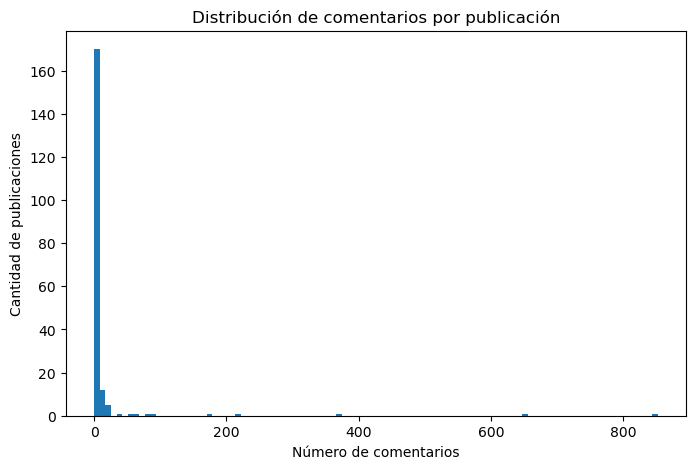

In [79]:
comentarios_por_post = (
    df.groupby("post_id")["comment_id"]
      .count()
)

plt.figure(figsize=(8,5))
plt.hist(comentarios_por_post, bins=100)
plt.xlabel("Número de comentarios")
plt.ylabel("Cantidad de publicaciones")
plt.title("Distribución de comentarios por publicación")
plt.show()

In [75]:
comentarios_por_post = (
    df.groupby(["post_id", "post_message"])["comment_id"]
      .count()
      .reset_index(name="n_comentarios")
      .sort_values("n_comentarios", ascending=False)
)

comentarios_por_post

,post_id,post_message,n_comentarios
108,154787275135903_546904915924135,"""Augusto Pinochet Ugarte"". \n\nDiseño 3D escul...",852
44,154787275135903_1530080439121680,Escultura General Augusto Pinochet.\n\n20cm de...,654
126,154787275135903_622842211663738,Para quienes están interesados y esperando: NO...,374
127,154787275135903_622877694993523,Otro avance del proyecto!\n(versión cromada) \...,217
170,154787275135903_911398067656590,Diseño 3D de Carabinero de Chile.\n\n#zbrush #...,171
...,...,...,...
41,154787275135903_1354194496710276,Figura impresa en 3D de aspirante a oficial de...,0
132,154787275135903_649770667152666,Diseño homenaje a bomberos.,0
37,154787275135903_1324751436321249,Figura impresa en 3D de mujer de Carabineros d...,0
93,154787275135903_413920349222593,Más trabajos de Fabián!\n\nNo sabes nada Jon s...,0


**Resultado**: La distribución del número de comentarios por publicación no es uniforme. La mayoría de las publicaciones presenta una baja cantidad de comentarios (mediana de 2 y percentil 75 de 5), mientras que un número reducido de publicaciones concentra una cantidad considerablemente mayor de interacciones, alcanzando un máximo de 852 comentarios. Este comportamiento genera una distribución sesgada hacia valores altos y es coherente con los patrones de participación comúnmente observados en redes sociales.

### Calidad y normalización de texto:
Los comentarios provienen de lenguaje libre de usuarios, por lo que se espera alta variabilidad en formato (mayúsculas, tildes, múltiples espacios, emojis, símbolos, errores ortográficos y escritura informal). La limpieza se diseñó para estandarizar el texto sin perder contenido semántico relevante.

# Capa Silver - Data Cleaning (Texto base)

### Primer filtro estructural

In [10]:
#Antes de continuar, quitamos las filas vacías.
#estos corresponden a comentarios ''
print("Antes filtrado:", len(df))

mask_valid_comments = (
    df['comment_message'].notna() &
    df['comment_message'].astype(str).str.strip().ne("")
)

df = df[mask_valid_comments].copy()

print("Después filtrado:", len(df))
print("Comentarios eliminados:", mask_valid_comments.shape[0] - len(df))

Antes filtrado: 3276
Después filtrado: 2962
Comentarios eliminados: 314


### Limpieza de texto
* Limpieza de simbolos de puntuación
* Estandarizar el nombre del texto (minúscula) y tratamiento de espacios (al final y al inicio del texto)
* Remover los espacios de más de uno
* Remover acentos del texto
* Reemplazar los espacios por algún carácter
* Transformar la función para el manejo en dataframe

In [2]:
# =========================
# Función de limpieza
# =========================
def clean_text(text, inchar=" "):

    if text is None:
        return None

    signos = '()[]{}<>^*#@=+#¡!'

    for k in signos:
        text = text.replace(k, " ")

    text = text.lower().strip()

    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    text = text.replace("\n", " ")

    text = re.sub(r'\?{2,}', '?', text)

    text = text.replace(' ', inchar)

    text = re.sub('%s+' % inchar, inchar, text)

    return text

In [ ]:
# Aplicación de limpieza
clean_cols = lambda x: clean_text(str(x), " ")

df['clean_comment_message'] = df['comment_message'].apply(clean_cols)
df['clean_post_message'] = df['post_message'].apply(clean_cols)


# GUARDAR EN SILVER
silver_path = os.path.join("data", "silver")
os.makedirs(silver_path, exist_ok=True)

output_file = os.path.join(silver_path, "facebook_comments_clean.csv")

df.to_csv(output_file, index=False, encoding="utf-8")

print("✔ Dataset guardado en SILVER")
print(f"Filas: {len(df)}")
print(f"Archivo: {output_file}")

In [86]:
#Revisamos el resultado de la limpieza de texto:
df[['comment_message','clean_comment_message']].head(15)

,comment_message,clean_comment_message
0,Lo vendes,lo vendes
1,Fdo Romero llego el momento jaajj,fdo romero llego el momento jaajj
2,"Dn. Daniel Lopez , el mayor ganster salido de ...","dn. daniel lopez , el mayor ganster salido de ..."
3,que los zurdos se bajen un ratito del aji 🌶🕳 y...,que los zurdos se bajen un ratito del aji 🌶🕳 y...
4,CUANTO VALE LA JOYITA 120 DOLARES?,cuanto vale la joyita 120 dolares?
5,Tiene la de Daniel López?,tiene la de daniel lopez?
6,Quiero Aser un envio para la Fabiola campillay...,quiero aser un envio para la fabiola campillay...
7,Cómo te lo explico!!!,como te lo explico
8,Valor,valor
9,Viene con el narcotrafico el perro muerto??,viene con el narcotrafico el perro muerto?


- **Validación rápida de consistencia de la capa Silver**

Se realiza una validación rápida de consistencia entre `df_silver` en memoria y la versión persistida en `data/silver/`, como medida precautoria. Dado que esta capa fue construida directamente a partir de `bronze/` y que los registros con `comment_id = NaN` ya fueron eliminados durante la transformación, ambas representaciones deberían ser equivalentes.

In [22]:
df_silver_disk = pd.read_csv(
    "data/silver/facebook_comments_clean.csv"
)

print(len(df_silver))
print(len(df_silver_disk))

2962
2962


In [23]:
(df_silver.dtypes == df_silver_disk.dtypes)

post_id                  True
post_message             True
post_created             True
post_reactions           True
post_image_url           True
comment_id               True
comment_message          True
comment_created          True
comment_reactions        True
clean_comment_message    True
clean_post_message       True
dtype: bool

In [3]:
df_silver = pd.read_csv(r"data\silver\facebook_comments_clean.csv")

In [24]:
assert_frame_equal(
    df_silver.reset_index(drop=True),
    df_silver_disk.reset_index(drop=True),
    check_dtype=False
)

print("Silver persistido y en memoria son consistentes.")

Silver persistido y en memoria son consistentes.


# Construcción Dataset de Entrenamiento (Silver enriquecido)

## Selección de muestra para etiquetado manual

Se seleccionó una muestra aleatoria de 1212 comentarios utilizando una semilla fija `(random_state=42)` para asegurar reproducibilidad. Esta muestra fue exportada y posteriormente etiquetada manualmente fuera del entorno Python mediante una hoja de cálculo.

In [ ]:
sample_cols = ["comment_id", "clean_comment_message"]

df_sample = (
    df_silver[sample_cols]
    .sample(n=1212, random_state=42)
)

df_sample.to_csv(
    "data/gold/comentarios_etiquetados_multilabel_v1.csv",
    index=False
)

## Etiquetado supervisado manual
Cada comentario fue revisado individualmente y se añadieron etiquetas binarias correspondientes a las categorías definidas para el problema. Debido a que un mismo comentario puede pertenecer simultáneamente a varias categorías, se empleó un esquema multietiqueta.

Las columnas agregadas fueron:

- `interes:` Comentarios que evidencian intención o interés comercial, tales como consultas por precio, disponibilidad, dimensiones, despacho o proceso de compra.
- `elogio_producto:` Comentarios que expresan una valoración positiva explícita hacia el diseño, calidad o acabado del producto, excluyendo manifestaciones de carácter político o emocional.
- `critica_producto:` Comentarios que expresan una valoración negativa sobre el diseño, calidad o características del producto, excluyendo manifestaciones de carácter político o emocional.
- `fanatismo/emocional:` El comentario refleja una adhesión emocional o identitaria hacia un personaje, grupo o postura política. Esta etiqueta representa manifestaciones de apoyo, admiración o identificación que trascienden una simple opinión sobre el producto. Puede coexistir con elogios, solicitudes o incluso con comentarios conflictivos.
- `conflictivo:` El comentario busca provocar, confrontar o incentivar la discusión entre posturas opuestas. Se incluyen expresiones destinadas a ridiculizar, desafiar o atacar al grupo contrario, independientemente de la posición ideológica del autor. Un comentario puede ser conflictivo tanto si critica el producto o personaje como si lo elogia mientras incorpora mensajes dirigidos contra el sector opuesto. Por ejemplo: "*Grande mi general, te quedó excelente. Los zurdos quedarán para adentro.*", o "*Solo los Fachos alaban figuras de asesinos*"
- `sarcasmo:` Comentarios irónicos o sarcásticos, tanto positivos como negativos, cuyo significado implícito difiere del sentido literal, por ejemplo: "Qué buen diseño, ideal para dárselo al perro".
- `solicitud:` Comentarios que proponen nuevos modelos, modificaciones o personalizaciones del producto.
- `cuidado:` Comentarios que contienen amenazas, advertencias de acciones legales o expresiones potencialmente perjudiciales hacia la empresa.
- `otro:` Comentarios sin una interpretación directa respecto al producto o la empresa, incluyendo etiquetados de terceros, conversaciones ajenas al contexto o contenido que no se ajusta a las categorías anteriores.

## Carga del conjunto etiquetado

In [57]:
etiquetados=pd.read_csv("data/labeling/labeled_comments_v2.csv")

In [51]:
#Aplicamos limpieza a comentarios etiquetados por precaución y robustez.
clean_cols = lambda x: clean_text(str(x), " ")

etiquetados["clean_comment_message"] = etiquetados["clean_comment_message"].apply(clean_cols)

In [52]:
etiquetados.head()

,comment_id,clean_comment_message,interes,elogio_producto,critica_producto,fanatismo/emocional,conflictivo,sarcasmo,otro,solicitud,cuidado
0,154812531800044_224151038199526,cuanto sale y cuanto demora en promedio un trabajo como este siege tank pintado? que tamano promedio tiene?,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,561578282638572_672694277563498,que valor tiene el archivo stl,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,927551496041247_413277837985443,amigo lo podrias hacer pero con la piocha de los comando de los anos 80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,546904915924135_547434412537852,dictadores de bolsillo xd,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
4,973014748161588_1003237047817440,jajajajja ya ahora con los moldes reales,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN


- Validamos que no hayan filas sin etiquetar:

## Criterios de coexistencia e interpretación de etiquetas

Debido a la naturaleza del problema, se adoptó un enfoque multietiqueta, permitiendo que un mismo comentario pertenezca simultáneamente a más de una categoría. Las etiquetas representan distintas dimensiones semánticas del comentario y no necesariamente son excluyentes entre sí.

En particular, las etiquetas `interes`, `elogio_producto`, `critica_producto` y `solicitud` describen la intención aparente del comentario, mientras que `fanatismo_emocional`, `conflictivo` y `sarcasmo` representan su componente emocional, ideológico o contextual. Por ello, distintas combinaciones de etiquetas pueden coexistir sin ser contradictorias.

Se observaron, por ejemplo, comentarios que expresan simultáneamente interés comercial y elogio hacia el producto, así como casos donde un usuario elogia la calidad del trabajo realizado mientras manifiesta una valoración emocional o ideológica hacia el personaje representado. De igual manera, un comentario puede contener una solicitud y además una carga emocional asociada a fanatismo o conflictividad.

La etiqueta `sarcasmo` requiere una interpretación especial, ya que puede alterar el significado literal del comentario. En presencia de sarcasmo, las etiquetas `interes`, `elogio_producto`, `critica_producto` y `solicitud` no representan una intención genuina, sino una expresión irónica. Sin embargo, el sarcasmo no invalida las etiquetas emocionales o contextuales: un comentario marcado como `conflictivo` y `sarcasmo` continúa siendo interpretado como conflictivo en su naturaleza de confrontación o provocación.

Asimismo, las etiquetas `fanatismo_emocional` y `conflictivo` no deben interpretarse como mutuamente excluyentes. Un mismo comentario puede reflejar simultáneamente adhesión emocional a una postura o grupo, y al mismo tiempo contener elementos de confrontación o provocación hacia un grupo contrario.

En este sentido, se destaca que comentarios con `critica_producto` junto con `conflictivo` no deben interpretarse necesariamente como una crítica o feedback genuina al producto, sino como una reacción emocional, ideológica o polarizada hacia el contexto del contenido.

Estas consideraciones forman parte de la interpretación posterior de los resultados y no modifican las etiquetas utilizadas durante el entrenamiento, las cuales se conservan tal como fueron asignadas manualmente con el fin de preservar la máxima información semántica posible en los comentarios.

**Importante:** Se definirá con mayor claridad cada etiqueta final, asi como su interpretación, en el item **` 10.2 Reglas de negocio - Etiquetas derivadas`**. Sin embargo, a modo de exploración, exponemos a continuación algunas de estas posibles combinaciones:

- `elogio_producto` + `fanatismo_emocional` sin `sarcasmo`:

En ausencia de sarcasmo, ambas etiquetas conservan su significado original. Esto se debe a que algunos usuarios manifestaron explícitamente una valoración positiva de la calidad o diseño del producto, al mismo tiempo que expresaban una adhesión emocional o identitaria hacia el personaje, grupo o contexto representado. Estas dimensiones no se consideran excluyentes y pueden coexistir de forma complementaria en el mismo comentario.

In [54]:
mask = (
    (etiquetados["elogio_producto"].fillna(0) == 1) &
    (etiquetados["fanatismo/emocional"].fillna(0) == 1) &
    (etiquetados["sarcasmo"].fillna(0) == 0)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
]

,comment_id,clean_comment_message
68,622877694993523_627257544555538,"que belleza, quiero una para para exhibir en el hall de entrada, aji pa los zurdos, como puedo obtener una, o dos"
89,546904915924135_547130249234935,excelente trabajo te felicito la. escultura hermosa por interno pasas los valores.. felicitaciones el mejor presidente de chile. se extrana
152,622842211663738_623702834911009,quien. fue. ese. mago. que hizo al jefe. le quedo mejor que el museo de cera en santiago ajjajaja
216,622877694993523_624943248120301,hermoso trabajo del unico heroe que ha sido capaz de hechar la mierda del pais
237,392725821342046_392975294650432,tremendo
368,622842211663738_622967404984552,"la figura excelente, muy buen trabajo.... pero leer los comentarios y a la gente que le arde el alma ver a ese personaje, jajajajaja, no tiene precio, leer su odio a una figura artificial me hace el dia xd"
416,622877694993523_626167654664527,"muy linda figura del unico presidente de chile, que sea de calidad para que perdure en mi domicilio, y el precio por favor"
553,622877694993523_623740884907204,excelente trabajo de arte y mucho patriotismo..🇨🇱 viva el gral. pinochet
564,678260077637058_1453037618977957,"excelente busto, solo permitamos agregar que ideal con los ojos abiertos ya que paso a la inmortalidad de los heroes y martires., felicitaciones"
565,622877694993523_624987434782549,"muy lindo , digno de mi presidente. pinochet ugarte"


- `sarcasmo`+`solicitud` = Falsa solicitud

In [58]:
# Comentarios solicitando diseños en presencia de sarcasmo
mask = (
    (etiquetados["solicitud"] == 1) &
    (etiquetados["sarcasmo"] == 1)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
].head(5)

,comment_id,clean_comment_message
13,546904915924135_134876294683481,tienen uno haciendose caca en the clinic?
22,546904915924135_547275039220456,"esta bonito, tienes mas dictadores?"
24,622842211663738_623046338309992,quiero una de jaime guzman con cabezas de repuesto
27,546904915924135_185965625959784,"hola, me gustaria que hicieran un especial de la marchas por el rechazo. son solo 10 figuritas. ojala sebastian izquierdo llorando."
29,546904915924135_547327549215205,tienes de chavez y castro companero


- `sarcasmo` + `elogio_producto` = Falso elogio (Estos fueron etiquetados como emocional_neg)

In [55]:
# Comentarios con elogio y sarcasmo simultáneamente
mask = (
    (etiquetados["elogio_producto"] == 1) &
    (etiquetados["sarcasmo"] == 1)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
]

,comment_id,clean_comment_message
22,546904915924135_547275039220456,"esta bonito, tienes mas dictadores?"
117,546904915924135_186116855944661,excelente trabajo ahora demelos para tirarselos a los mismos pacos culials
127,546904915924135_485340832156522,"esta mortal el trabajo, ¿tienen esculturas del chacal de nahueltoro o del tila tambien?"
200,1057607241520564_741576030171497,quedo bueno el bison :v
413,546904915924135_142103040807355,hermoso trabajo de mi general. me pregunto si tus clientes lo usan de pisapapeles o de consolador?
491,546904915924135_142102184140774,"espectacular, tienes la version de daniel lopez? esa donde sale de lentes y bigotes?"
500,911398067656590_912609697276170,parado haciendo nada...que realista
522,911398067656590_1121262792397702,se nota q estan duros q realistas
613,1530080439121680_757331620795367,q bonito se ve don daniel lopez
623,1530080439121680_975845761633154,esta wena la estatua del narcodictador


- `critica_producto`+`conflictivo`: No serán considerados críticas genuinas a la calidad del diseño o producto, debido a que se deben a reacciones emocionales/políticas.

In [59]:
# Comentarios con crítica al producto y emocional negativo simultáneamente
mask = (
    (etiquetados["critica_producto"] == 1) &
    (etiquetados["conflictivo"] == 1)
)

etiquetados.loc[
    mask,
    [
        "comment_id",
        "clean_comment_message",
        "critica_producto",
        "conflictivo",
        "sarcasmo"
    ]
]

,comment_id,clean_comment_message,critica_producto,conflictivo,sarcasmo
17,546904915924135_547320262549267,fea la wea... cualquier cosa que sea de ese viejo genocida es fea,1.0,1.0,NaN
498,622877694993523_625359948078631,la wea fea,1.0,1.0,NaN
559,622842211663738_623656038249022,fea la wea,1.0,1.0,NaN
659,1530080439121680_1539524017688424,la wea fea,1.0,1.0,NaN
665,1530080439121680_2038341433701782,la wea ordinaria,1.0,1.0,NaN
955,1530080439121680_26305290799155134,la wea ordinaria po loco,1.0,1.0,NaN
989,1530080439121680_4347091195437662,que desperdicio.... de material..,1.0,1.0,NaN
1076,1530080439121680_1461889682092570,la wea fea,1.0,1.0,NaN
1101,1530080439121680_1276560847237362,la wea ordinaria,1.0,1.0,NaN
1164,1530080439121680_1436458588163144,menos mal ni se parece al ladron y genocida,1.0,1.0,NaN


- `sarcasmo`+`conflictivo`: sarcasmo no anula reacciones emocionales conflictivas, ya que estas suelen coexistir y seguir representando la misma intención.

In [45]:
# Comentarios con sarcasmo + emocional negativo
mask = (
    (etiquetados["sarcasmo"] == 1) &
    (etiquetados["critica_producto"] == 1)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
]

,comment_id,clean_comment_message
219,911398067656590_1115337776335549,les falto guata
374,911398067656590_424034460117959,les falta guata y falopa
397,911398067656590_302527669523021,le falto las 200/300k de soborno pa salir piola


- `elogios` sin `fanatismo_emocional`: Corresponden a casos donde se elogia el producto sin señal de fanatismo o reacción emocional (aun puede haber sarcasmo)

In [64]:
mask = (
    (etiquetados["elogio_producto"].fillna(0) == 1) &
    (etiquetados["fanatismo/emocional"].fillna(0) == 0)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
].head(10)

,comment_id,clean_comment_message
18,546904915924135_119075389539310,hola te felicito por tu trabajo\nindicame precios
22,546904915924135_547275039220456,"esta bonito, tienes mas dictadores?"
30,546904915924135_184107636335444,buen trabajo... cuento cuesta?
46,304838853464077_304996450114984,valor de life? :o esta genial
64,622842211663738_623370171610942,esta bien hecho 👍
67,622877694993523_745536882727603,excelente y felicitaciones 💪🏻🇨🇱 .cual es su va...
70,546904915924135_547386079209352,que hermoso trabajo .. cuando regresen de vaca...
71,546904915924135_547151475899479,muy buena imagen ..
76,622877694993523_623016468312979,genial
84,885640895383867_885654438715846,fino


- `elogio`+`fanatismo_emocional`: Corresponden tanto a elogios al producto como señal de reacción emocional/política positiva.
 
Estos casos, a diferencia del caso `critica_producto`+`conflictivo`, serán considerados como Verdaderos elogios al producto debido a que ambas reacciones suelen coexistir y, si bien tal reaccion politico/emocional puede afectar el juicio sobre el diseño, ambas valorizaciones suelen coexistir y representar un sentimiento totalmente compatible

In [63]:
mask = (
    (etiquetados["elogio_producto"].fillna(0) == 1) &
    (etiquetados["fanatismo/emocional"].fillna(0) == 1)
)

etiquetados.loc[
    mask,
    ["comment_id", "clean_comment_message"]
]

,comment_id,clean_comment_message
68,622877694993523_627257544555538,"que belleza, quiero una para para exhibir en el hall de entrada, aji pa los zurdos, como puedo obtener una, o dos"
89,546904915924135_547130249234935,excelente trabajo te felicito la. escultura hermosa por interno pasas los valores.. felicitaciones el mejor presidente de chile. se extrana
152,622842211663738_623702834911009,quien. fue. ese. mago. que hizo al jefe. le quedo mejor que el museo de cera en santiago ajjajaja
216,622877694993523_624943248120301,hermoso trabajo del unico heroe que ha sido capaz de hechar la mierda del pais
237,392725821342046_392975294650432,tremendo
368,622842211663738_622967404984552,"la figura excelente, muy buen trabajo.... pero leer los comentarios y a la gente que le arde el alma ver a ese personaje, jajajajaja, no tiene precio, leer su odio a una figura artificial me hace el dia xd"
416,622877694993523_626167654664527,"muy linda figura del unico presidente de chile, que sea de calidad para que perdure en mi domicilio, y el precio por favor"
553,622877694993523_623740884907204,excelente trabajo de arte y mucho patriotismo..🇨🇱 viva el gral. pinochet
564,678260077637058_1453037618977957,"excelente busto, solo permitamos agregar que ideal con los ojos abiertos ya que paso a la inmortalidad de los heroes y martires., felicitaciones"
565,622877694993523_624987434782549,"muy lindo , digno de mi presidente. pinochet ugarte"


**Importante:** Se define con mayor claridad cada etiqueta final derivada y su interpretación en el item **` 10.2 Reglas de negocio - Etiquetas derivadas`**

- **Matriz de coocurrencias**

In [64]:
# Matriz de coocurrencias
cols_etiquetas = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo/emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud"
]

# NaN -> 0
X = etiquetados[cols_etiquetas].fillna(0).astype(int)

# Matriz de coocurrencias
cooc = X.T.dot(X)

display(cooc)

,interes,elogio_producto,critica_producto,fanatismo/emocional,conflictivo,sarcasmo,otro,solicitud
interes,297,27,0,4,4,21,1,12
elogio_producto,27,147,0,21,21,13,1,8
critica_producto,0,0,15,0,10,3,0,0
fanatismo/emocional,4,21,0,176,36,3,0,0
conflictivo,4,21,10,36,505,116,0,70
sarcasmo,21,13,3,3,116,192,5,107
otro,1,1,0,0,0,5,130,0
solicitud,12,8,0,0,70,107,0,142


## Distribución de etiquetas
- Analizamos la distribución de etiquetas del dataset de entrenamiento:

In [68]:
cols_labels = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo/emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud",
    "cuidado"
]

frecuencias = etiquetados[cols_labels].sum()

pd.DataFrame({
    "frecuencia": frecuencias,
    "%": 100*frecuencias/len(etiquetados)
})

,frecuencia,%
interes,297.0,24.504950
elogio_producto,147.0,12.128713
critica_producto,15.0,1.237624
fanatismo/emocional,176.0,14.521452
conflictivo,499.0,41.171617
sarcasmo,192.0,15.841584
otro,130.0,10.726073
solicitud,142.0,11.716172
cuidado,17.0,1.402640


- Graficamos las frecuencias

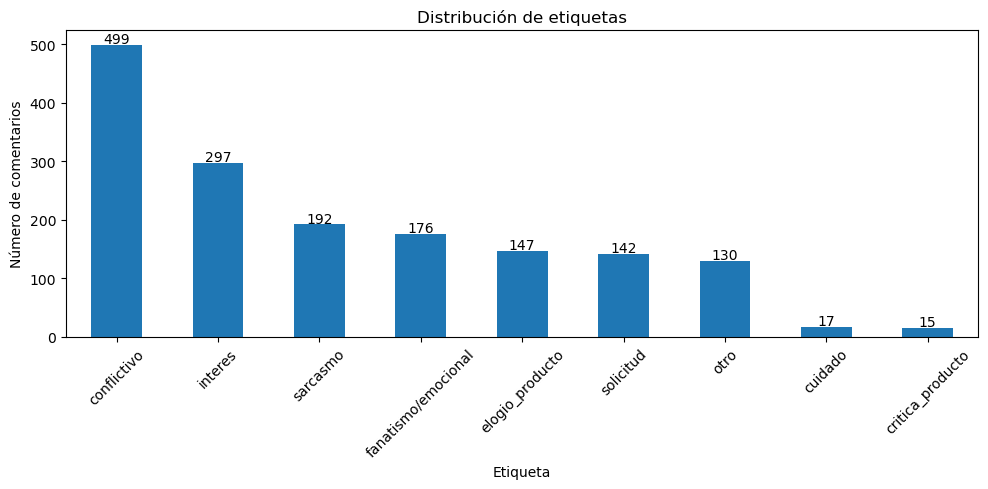

In [69]:
# Frecuencia por etiqueta
freq_labels = (
    etiquetados[cols_labels]
    .sum()
    .sort_values(ascending=False)
)

ax = freq_labels.plot(kind='bar', figsize=(10,5))

for i, v in enumerate(freq_labels):
    ax.text(i, v + 3, str(int(v)), ha='center')

plt.ylabel('Número de comentarios')
plt.xlabel('Etiqueta')
plt.title('Distribución de etiquetas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis de desbalance de clases

La distribución de etiquetas presenta un desbalance considerable. Las categorías `conflictivo`, `interes` y `sarcasmo` concentran la mayor cantidad de ejemplos, mientras que etiquetas como `critica_producto` y `otro` poseen una frecuencia significativamente menor. Este comportamiento es habitual en problemas reales de clasificación multietiqueta y debe considerarse durante el entrenamiento y evaluación de los modelos, ya que las clases minoritarias podrían presentar un desempeño inferior debido a la menor cantidad de ejemplos disponibles.

En particular, la etiqueta `conflictivo` representa la clase más frecuente del dataset, lo que refleja una alta presencia de contenido polarizado o provocativo en las interacciones analizadas. Por otro lado, `critica_producto` es la clase más escasa, lo que puede dificultar su correcta identificación por parte de los modelos debido a la limitada cantidad de ejemplos de entrenamiento.

Debido a que las etiquetas no son mutuamente excluyentes, las frecuencias individuales no suman necesariamente el número total de comentarios, puesto que un mismo comentario puede pertenecer simultáneamente a más de una categoría. Esto es especialmente relevante en combinaciones como `interes` + `fanatismo_emocional` o `elogio_producto` + `conflictivo`, las cuales representan dimensiones complementarias del mismo mensaje.

## Expansión controlada del dataset mediante generación de ejemplos sintéticos

A partir del análisis de desbalance de etiquetas, se identificó una fuerte subrepresentación en categorías minoritarias como `critica_producto`, `cuidado` y `emocional_pos`. Este desbalance puede afectar el desempeño del modelo, especialmente en métricas macro, al dificultar el aprendizaje de patrones asociados a clases poco frecuentes.

Con el fin de mitigar este problema, se implementó una estrategia de expansión controlada del conjunto de entrenamiento mediante la incorporación de ejemplos sintéticos generados manualmente. Estos ejemplos corresponden a variaciones lingüísticas realistas inspiradas en expresiones observadas en el dominio, con especial énfasis en aquellas categorías cuya escasez podría limitar la capacidad de generalización del modelo.

A diferencia de técnicas automáticas de *oversampling*, esta aproximación se basa en conocimiento experto del dominio, permitiendo preservar la coherencia semántica de los comentarios y minimizar la introducción de ruido artificial en el espacio de representación.

Los nuevos registros se incorporan antes de la generación de embeddings, permitiendo que BETO proyecte tanto los comentarios originales como los ejemplos sintéticos dentro de un mismo espacio semántico. Adicionalmente, se **agrega la columna llamada** `"sintetico"` con fines de trazabilidad, permitiendo identificar aquellos comentarios incorporados manualmente y facilitando futuros análisis de sensibilidad o validaciones posteriores.

Cabe destacar que el objetivo principal del estudio se centra en las categorías `interes`, `conflictivo`, `fanatismo_emocional` y `sarcasmo`. Por esta razón, la generación controlada de ejemplos sintéticos no busca modificar artificialmente la distribución global del problema, sino garantizar una representación mínima de las clases minoritarias que permita al modelo aprender patrones significativos y reducir el sesgo hacia las clases predominantes.

> **Nota sobre reproducibilidad:** el conjunto de datos utilizado en esta sección (muestras reales extraídas y etiquetadas, junto con los ejemplos sintéticos) se encuentra en la carpeta `labeling/`, la cual **no se incluye en este repositorio** por corresponder a datos confidenciales de la PYME (comentarios y publicaciones reales de clientes). Este notebook tiene como propósito documentar la metodología, las decisiones de diseño y el proceso de entrenamiento del pipeline jerárquico, y no está pensado para ejecutarse de punta a punta sin acceso a dicho dataset.

### Carga y Limpieza de datos sintéticos

In [77]:
etiquetados = pd.read_csv("data/labeling/labeled_comments_v2.csv")

In [82]:
# Cargar datos sintéticos
synthetic = pd.read_csv(
    "data/labeling/synthetic_labels.csv",
    sep=';'
)

# Normalizar nombres de columnas en AMBOS datasets
etiquetados = etiquetados.rename(
    columns={"fanatismo/emocional": "fanatismo_emocional"}
)

synthetic = synthetic.rename(
    columns={"fanatismo/emocional": "fanatismo_emocional"}
)

# Copia + limpieza
synthetic_clean = synthetic.copy()

synthetic_clean["clean_comment_message"] = (
    synthetic_clean["clean_comment_message"]
    .astype(str)
    .apply(lambda x: clean_text(x, " "))
)

print(synthetic_clean[["clean_comment_message"]].head())

# Indicador de origen
etiquetados["sintetico"] = 0
synthetic_clean["sintetico"] = 1

# =========================
# Unir datasets
# =========================
etiquetados_expandidos = pd.concat(
    [etiquetados, synthetic_clean],
    ignore_index=True
)

# IDs sintéticos
mask = etiquetados_expandidos["sintetico"] == 1

etiquetados_expandidos.loc[mask, "comment_id"] = [
    f"synthetic_{i:04d}"
    for i in range(mask.sum())
]

# Labels
label_cols = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud",
    "cuidado"
]

# Imputación de NaN en labels
etiquetados_expandidos[label_cols] = (
    etiquetados_expandidos[label_cols]
    .fillna(0)
)

# Limpieza de IDs
etiquetados_expandidos["comment_id"] = (
    etiquetados_expandidos["comment_id"].astype(str)
)

# Verificación
print("\nCantidad total:", len(etiquetados_expandidos))
print(etiquetados_expandidos["sintetico"].value_counts())

print("\nEjemplos sintéticos:")
print(
    etiquetados_expandidos
    .query("sintetico == 1")[["comment_id", "clean_comment_message"]]
    .head()
)

print("\nColumnas finales:")
print(etiquetados_expandidos.columns)

                               clean_comment_message
0  el producto se ve bien, pero la calidad del ma...
1  no me gusto el acabado, parece mal terminado e...
2  el diseno es bueno, pero no es funcional en el...
3  esperaba algo mas resistente, se nota que los ...
4  las terminaciones dejan mucho que desear, pare...

Cantidad total: 2129
sintetico
0    1212
1     917
Name: count, dtype: int64

Ejemplos sintéticos:
          comment_id                              clean_comment_message
1212  synthetic_0000  el producto se ve bien, pero la calidad del ma...
1213  synthetic_0001  no me gusto el acabado, parece mal terminado e...
1214  synthetic_0002  el diseno es bueno, pero no es funcional en el...
1215  synthetic_0003  esperaba algo mas resistente, se nota que los ...
1216  synthetic_0004  las terminaciones dejan mucho que desear, pare...

Columnas finales:
Index(['comment_id', 'clean_comment_message', 'interes', 'elogio_producto',
       'critica_producto', 'fanatismo_emocional', 'conf

In [83]:
# Verifico que quedaron los comment_id de los comentarios sintéticos:
etiquetados_expandidos.query("sintetico == 1")[["comment_id"]].head()

,comment_id
1212,synthetic_0000
1213,synthetic_0001
1214,synthetic_0002
1215,synthetic_0003
1216,synthetic_0004


In [84]:
synthetic_clean.fillna(0).head(5)

,comment_id,clean_comment_message,interes,elogio_producto,critica_producto,fanatismo_emocional,conflictivo,sarcasmo,otro,solicitud,cuidado,sintetico
0,0.0,"el producto se ve bien, pero la calidad del ma...",0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,"no me gusto el acabado, parece mal terminado e...",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,"el diseno es bueno, pero no es funcional en el...",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,"esperaba algo mas resistente, se nota que los ...",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,"las terminaciones dejan mucho que desear, pare...",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1


- persistimos en silver:

In [85]:
# Guardar el dataset corregido
etiquetados_expandidos.to_csv(
    "data/labeling/labels_augmented.csv",
    index=False,
    sep=";"
)

print("Dataset guardado en data/silver/labels_augmented.csv")

Dataset guardado en data/silver/labels_augmented.csv


### Distribución de clases en dataset extendido


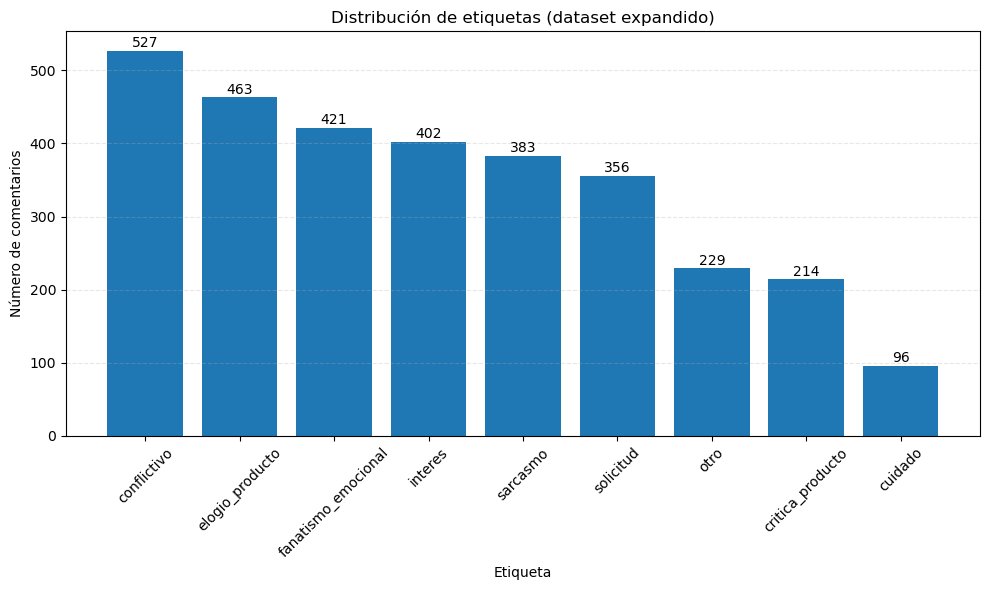

In [86]:
# Columnas de etiquetas
label_cols = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud",
    "cuidado"
]

# Frecuencia de cada etiqueta
label_counts = etiquetados_expandidos[label_cols].fillna(0).sum().sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10,6))

bars = plt.bar(label_counts.index, label_counts.values)

# Agregar cantidad sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylabel("Número de comentarios")
plt.xlabel("Etiqueta")
plt.title("Distribución de etiquetas (dataset expandido)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
# ==============================
# Columnas de etiquetas
# ==============================
label_cols = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud",
    "cuidado"
]

# Asegurar formato numérico
df = etiquetados_expandidos.copy()
df[label_cols] = (
    df[label_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

# ==============================
# Estadísticas por etiqueta
# ==============================
stats = pd.DataFrame({
    "cantidad": df[label_cols].sum(),
    "porcentaje (%)": (100 * df[label_cols].sum() / len(df)).round(2)
})

stats["ausentes"] = len(df) - stats["cantidad"]

print("Número total de comentarios:", len(df))
print()
print(stats.sort_values("cantidad", ascending=False))

# ==============================
# Número de etiquetas por comentario
# ==============================
n_labels = df[label_cols].sum(axis=1)

print("\nEtiquetas por comentario:")
print(n_labels.value_counts().sort_index())

# ==============================
# Comentarios sin ninguna etiqueta
# ==============================
print("\nComentarios sin etiquetas:", (n_labels == 0).sum())

Número total de comentarios: 2129

                     cantidad  porcentaje (%)  ausentes
conflictivo               527           24.75      1602
elogio_producto           463           21.75      1666
fanatismo_emocional       421           19.77      1708
interes                   402           18.88      1727
sarcasmo                  383           17.99      1746
solicitud                 356           16.72      1773
otro                      229           10.76      1900
critica_producto          214           10.05      1915
cuidado                    96            4.51      2033

Etiquetas por comentario:
0       1
1    1348
2     611
3     155
4      14
Name: count, dtype: int64

Comentarios sin etiquetas: 1


## Generación de embeddings para comentarios

Con el objetivo de transformar cada comentario en una representación numérica apta para algoritmos de aprendizaje automático, se utilizaron embeddings obtenidos mediante el modelo BETO (`dccuchile/bert-base-spanish-wwm-cased`), una adaptación de BERT entrenada específicamente para español.

BETO entrega una representación vectorial para cada token del comentario, es decir, cada palabra o fragmento de palabra posee su propio vector contextualizado. Sin embargo, para tareas de clasificación es necesario disponer de un único vector por comentario. Por esta razón, se aplicó **mean pooling** sobre la salida `last_hidden_state`, promediando los vectores de todos los tokens pertenecientes al comentario.

La elección de mean pooling se fundamenta en varias razones:

- Permite obtener una representación global del significado del comentario, independientemente de su longitud.
- Produce vectores de dimensión fija, requisito necesario para la mayoría de los algoritmos de clasificación.
- Es una técnica simple, reproducible y computacionalmente eficiente.
- Tiende a ser más estable que utilizar únicamente el token `[CLS]`, el cual puede presentar sesgos asociados a la posición inicial de la frase.
- En textos informales y ruidosos, como comentarios de Facebook con errores ortográficos, sarcasmo y vocabulario coloquial, proporciona una representación más holística del contenido.
- A diferencia de max pooling, que enfatiza las palabras con mayor activación y resulta útil para detectar términos particularmente discriminantes, mean pooling conserva información distribuida a lo largo de todo el comentario, siendo más apropiado para capturar la intención general del texto.

Los embeddings generados se almacenan en la capa **Silver** bajo el archivo `facebook_comments_embeddings.parquet`, conservando tanto las variables originales como una nueva columna `embedding`, donde cada fila contiene el vector representativo del comentario correspondiente. Esta representación será utilizada posteriormente para reducción de dimensionalidad, entrenamiento de modelos supervisados y análisis exploratorios.

In [89]:
df_silver = pd.read_csv("data/silver/facebook_comments_clean.csv", sep = ',')
etiquetados_expandidos = pd.read_csv("data/labeling/labels_augmented.csv", sep = ';')

In [90]:
#Verifico que solo haya 0 y 1 en labels
print(np.unique(etiquetados_expandidos[label_cols].values))

[0. 1.]


In [91]:
# Asegurar trazabilidad en los reales
df_silver["sintetico"] = 0

# Asignar IDs únicos a los sintéticos
mask = etiquetados_expandidos["sintetico"] == 1

etiquetados_expandidos.loc[mask, "comment_id"] = [
    f"synthetic_{i:04d}"
    for i in range(mask.sum())
]

# Asegurar tipo string
etiquetados_expandidos["comment_id"] = (
    etiquetados_expandidos["comment_id"]
    .astype(str)
)

# Extraer comentarios sintéticos
synthetic_comments = (
    etiquetados_expandidos
    .query("sintetico == 1")
    [["comment_id", "clean_comment_message", "sintetico"]]
    .copy()
)

# Agregar sintéticos al silver original
silver_cols = df_silver.columns

# Crear columnas faltantes en sintéticos
for col in silver_cols:
    if col not in synthetic_comments.columns:
        synthetic_comments[col] = None

# Reordenar columnas para coincidir con df_silver
synthetic_comments = synthetic_comments[silver_cols]

# Concatenar
df_silver_expandido = pd.concat(
    [df_silver, synthetic_comments],
    ignore_index=True
)

# Asegurar tipos consistentes
df_silver_expandido["comment_id"] = (
    df_silver_expandido["comment_id"]
    .astype(str)
)

# Verificación
print("Silver original:", len(df_silver))
print("Comentarios sintéticos:", len(synthetic_comments))
print("Silver expandido:", len(df_silver_expandido))

print("\nDistribución:")
print(df_silver_expandido["sintetico"].value_counts())

print("\nEjemplos de IDs sintéticos:")
print(
    df_silver_expandido
    .query("sintetico == 1")[["comment_id", "clean_comment_message"]]
    .head()
)

Silver original: 2962
Comentarios sintéticos: 917
Silver expandido: 3879

Distribución:
sintetico
0    2962
1     917
Name: count, dtype: int64

Ejemplos de IDs sintéticos:
          comment_id                              clean_comment_message
2962  synthetic_0000  el producto se ve bien, pero la calidad del ma...
2963  synthetic_0001  no me gusto el acabado, parece mal terminado e...
2964  synthetic_0002  el diseno es bueno, pero no es funcional en el...
2965  synthetic_0003  esperaba algo mas resistente, se nota que los ...
2966  synthetic_0004  las terminaciones dejan mucho que desear, pare...


In [92]:
# Guardar df_silver_expandido en silver:

df_silver_expandido.to_parquet(
    "data/silver/df_silver_expandido.parquet",
    index=False
)

print("✅ df_silver_expandido guardado correctamente")

✅ df_silver_expandido guardado correctamente


In [93]:
df_silver_expandido = pd.read_parquet("data/silver/df_silver_expandido.parquet")

In [94]:
# Cargar modelo BETO
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


# Función para generar embeddings por lotes
def get_embeddings_batch(texts, batch_size=32):
    """
    Genera embeddings BETO por lotes y retorna un arreglo numpy.
    """

    all_embeddings = []

    with torch.no_grad():

        for i in tqdm(range(0, len(texts), batch_size)):

            batch_texts = texts[i:i + batch_size]

            encoded_input = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            )

            encoded_input = {
                key: val.to(device)
                for key, val in encoded_input.items()
            }

            outputs = model(**encoded_input)

            # Mean pooling
            embeddings = (
                outputs.last_hidden_state
                .mean(dim=1)
                .cpu()
            )

            all_embeddings.append(embeddings)

    return torch.cat(all_embeddings).numpy()


# Generación y persistencia de embeddings
def generar_embeddings(df):
    """
    Genera embeddings BETO para los comentarios y guarda
    el resultado en la capa Silver.
    """

    df = df.copy()

    # Asegurar strings
    df["clean_comment_message"] = (
        df["clean_comment_message"]
        .fillna("")
        .astype(str)
    )

    print("Generando embeddings para comentarios...")

    embeddings = get_embeddings_batch(
        df["clean_comment_message"].tolist()
    )

    # Columna principal usada posteriormente
    df["embedding"] = list(embeddings)

    # Guardado en Silver
    output_dir = Path("data/silver")
    output_dir.mkdir(parents=True, exist_ok=True)

    output_file = output_dir / "facebook_comments_embeddings.parquet"

    df.to_parquet(
        output_file,
        index=False
    )

    print("\n✅ Embeddings generados correctamente")
    print(f"Filas: {len(df)}")
    print(f"Archivo guardado en: {output_file}")

    return df

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [95]:
#Generamos los embeddings sobre comentarios
df_embeddings = generar_embeddings(df_silver_expandido)

Generando embeddings para comentarios...


100%|██████████| 122/122 [01:47<00:00,  1.14it/s]



✅ Embeddings generados correctamente
Filas: 3879
Archivo guardado en: data\silver\facebook_comments_embeddings.parquet


# Modelo jerárquico de clasificación: intenciones y sarcasmo condicionado
En esta sección se introduce el enfoque general del sistema de clasificación propuesto, el cual adopta una arquitectura jerárquica en dos etapas.

El objetivo principal del modelo es mejorar la capacidad de detección de sarcasmo, una de las clases más complejas y ambiguas del problema, cuya correcta identificación resulta clave para la interpretación final de los comentarios.

Para abordar esta dificultad, se propone separar el problema en dos niveles. En una primera etapa se modelan las intenciones semánticas del comentario (como interés, elogio, crítica, solicitud, entre otras), mientras que en una segunda etapa se utiliza esta información como contexto adicional para la detección de sarcasmo condicionado.

La hipótesis central es que el sarcasmo no puede ser correctamente identificado únicamente a partir del texto aislado, sino que requiere conocimiento previo de la intención aparente del mensaje. Por lo tanto, las predicciones de la primera capa se utilizan como variables contextuales que enriquecen la representación del comentario en la segunda etapa.

Este enfoque busca aumentar la capacidad discriminativa del modelo en casos ambiguos y mejorar el rendimiento específico en la detección de sarcasmo.

## Capa 1: Clasificación multilabel
En esta sección se presenta la primera etapa del modelo jerárquico, correspondiente a la clasificación multietiqueta de intenciones en los comentarios.

El objetivo de esta capa es capturar las distintas dimensiones semánticas del texto, tales como interés comercial, elogio al producto, crítica, solicitud, fanatismo emocional y conflictividad, excluyendo deliberadamente la detección de sarcasmo.

Esta separación no es arbitraria, sino funcional: se busca que las intenciones actúen como variables estructurales del mensaje, las cuales posteriormente serán utilizadas como contexto explícito para mejorar la detección de sarcasmo en una segunda etapa.

La motivación principal de este diseño es que la identificación de sarcasmo mejora significativamente cuando el modelo conoce previamente la intención aparente del comentario, ya que el sarcasmo depende fuertemente del contraste entre intención superficial y polaridad contextual.

Por esta razón, esta capa se entrena como un modelo multietiqueta independiente, permitiendo coexistencia de intenciones dentro de un mismo comentario.

### Separación train y test.

Dado que el problema corresponde a una clasificación multietiqueta con un desbalance significativo entre clases, la partición del dataset en entrenamiento y prueba se realizó considerando la preservación de la distribución de las etiquetas más relevantes.

En particular, las clases de mayor interés para este trabajo (`interes`, `conflictivo` y `fanatismo_emocional`) concentran la mayor parte de los ejemplos y representan el foco principal del modelo. En contraste, categorías como `critica_producto`, `elogio_producto` y `cuidado` presentan una frecuencia considerablemente menor, por lo que su impacto en el entrenamiento es secundario.

Debido a la naturaleza multietiqueta del problema, no es posible garantizar una estratificación perfecta a nivel de combinación de etiquetas. Sin embargo, se optó por una partición aleatoria controlada, manteniendo proporciones globales consistentes entre conjuntos.

Adicionalmente, se considera que las clases minoritarias podrán presentar un desempeño inferior debido a la escasez de ejemplos, lo cual será abordado posteriormente mediante análisis de métricas por clase y posibles técnicas de reponderación o ajuste de umbrales.

In [2]:
# Recuperamos dataset de entrenamiento con embeddings desde /silver/
df_embeddings = pd.read_parquet("data/silver/facebook_comments_embeddings.parquet")

In [96]:
# Dataset de embeddings (features)
df_features = df_embeddings.copy()

# Dataset de etiquetas
df_labels = etiquetados_expandidos.copy()  # dataset manual

# Merge correcto
df_training = df_features.merge(
    df_labels,
    on="comment_id",
    how="inner"
)

# Features (X)
X = np.vstack(df_training["embedding"].values)

# Labels (y)
label_cols = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "sarcasmo",
    "otro",
    "solicitud",
    "cuidado"
]

y = df_training[label_cols].fillna(0).values


# Split multilabel estratificado
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in msss.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

# Verificación final
print("Dataset final:", df_training.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Dataset final: (2139, 24)
X_train: (1704, 768)
X_test: (435, 768)
y_train: (1704, 9)
y_test: (435, 9)


In [97]:
#Persistimos para retomar

silver_path = Path("data/silver")
silver_path.mkdir(parents=True, exist_ok=True)

df_training = df_training.reset_index(drop=True)

train_df = df_training.iloc[train_idx].copy()
test_df = df_training.iloc[test_idx].copy()

train_df.to_parquet(silver_path / "train.parquet", index=False)
test_df.to_parquet(silver_path / "test.parquet", index=False)

### Carga train-test

In [8]:
#Recuperamos Test y Train desde silver (EXCLUYENDO SARCASMO)
silver_path = Path("data/silver")

df_train = pd.read_parquet(silver_path / "train.parquet")
df_test = pd.read_parquet(silver_path / "test.parquet")

label_cols = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "otro",
    "solicitud",
    "cuidado"
]

X_train = np.vstack(df_train["embedding"].values)
X_test = np.vstack(df_test["embedding"].values)

y_train = df_train[label_cols].fillna(0).astype(int).values
y_test = df_test[label_cols].fillna(0).astype(int).values

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

print("\nLabel sanity check (train):")
print(pd.DataFrame(y_train, columns=label_cols).sum())

Shapes:
X_train: (1704, 768) y_train: (1704, 8)
X_test: (435, 768) y_test: (435, 8)

Label sanity check (train):
interes                324
elogio_producto        371
critica_producto       170
fanatismo_emocional    337
conflictivo            418
otro                   190
solicitud              286
cuidado                 76
dtype: int64


### Verificación de estratificación train-test
Verificamos que se mantengan proporciones de labels similares entre los conjuntos `train` y `test`:

In [99]:
# Distribución por etiqueta en TRAIN
train_dist = pd.DataFrame(
    y_train,
    columns=label_cols
).mean().sort_values(ascending=False)

print("Distribución relativa en TRAIN")
print((100 * train_dist).round(2))

print()

# Distribución por etiqueta en TEST
test_dist = pd.DataFrame(
    y_test,
    columns=label_cols
).mean().sort_values(ascending=False)

print("Distribución relativa en TEST")
print((100 * test_dist).round(2))

Distribución relativa en TRAIN
conflictivo            24.53
elogio_producto        21.77
fanatismo_emocional    19.78
interes                19.01
solicitud              16.78
otro                   11.15
critica_producto        9.98
cuidado                 4.46
dtype: float64

Distribución relativa en TEST
conflictivo            23.91
elogio_producto        21.38
fanatismo_emocional    19.31
interes                18.62
solicitud              16.32
otro                   11.03
critica_producto        9.89
cuidado                 4.37
dtype: float64


**Resultado**: La distribución relativa de las etiquetas se mantiene de forma consistente entre los conjuntos de entrenamiento y prueba, evidenciando que la partición estratificada multilabel preservó adecuadamente las proporciones originales de cada categoría. Por lo tanto, se considera que la partición realizada es adecuada y se procede al entrenamiento de los modelos de clasificación multilabel.

### Logistic Regression One-vs-Rest
Se utiliza un esquema One-vs-Rest (OvR) para extender la Regresión Logística a un problema de clasificación multilabel. En este enfoque, se entrena un clasificador binario independiente por cada clase, donde cada modelo aprende a distinguir si una etiqueta específica está presente o no, ignorando la interacción explícita entre clases.

A diferencia de una regresión logística estándar (binaria o multinomial), OvR permite que un mismo ejemplo pueda activar múltiples clases simultáneamente, lo cual es esencial en problemas multilabel como el presente. Esto resulta especialmente adecuado para embeddings semánticos, donde las clases no son mutuamente excluyentes y pueden coexistir dentro de un mismo comentario.

#### Baseline model

In [100]:
base_model = MultiOutputClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs"
    )
)

#### Hyperparameters tuning (RandomizedSearchCV)
Se realiza ajuste de hiperparámetros utilizando RandomizedSearchCV con validación cruzada (k-fold), con el objetivo de optimizar el rendimiento del modelo bajo la métrica F1 macro, la cual es apropiada para escenarios multilabel con fuerte desbalance de clases.

Este enfoque permite explorar eficientemente el espacio de hiperparámetros sin necesidad de una búsqueda exhaustiva (como Grid Search), reduciendo el costo computacional mientras se mantiene una buena cobertura del espacio de soluciones. La validación cruzada asegura que el rendimiento sea robusto y generalizable, evitando sobreajuste al conjunto de entrenamiento.

`param_dist`:
- C (regularización): Controla la fuerza de regularización inversa.

       Valores bajos → más regularización (modelo más simple).
       Valores altos → menos regularización (modelo más complejo).
   
- penalty = "l2":
 
       Se utiliza regularización L2, adecuada para espacios de alta dimensionalidad como embeddings, ya que estabiliza los coeficientes y reduce sobreajuste.   

In [101]:
param_dist = {
    "estimator__C": loguniform(1e-3, 1e2),   # regularización
    "estimator__penalty": ["l2"],            # lbfgs solo soporta l2
}

cv = MultilabelStratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [103]:
# Entrenamiento
search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=MultilabelStratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=MultiOutputClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                                max_iter=1000)),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'estimator__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000025E1B926150>,
                                        'estimator__penalty': ['l2']},
                   random_state=42, scoring='f1_macro', verbose=2)

#### Best model selection

In [104]:
best_model = search.best_estimator_

print("Mejores hiperparámetros:")
print(search.best_params_)

Mejores hiperparámetros:
{'estimator__C': 1.0129197956845732, 'estimator__penalty': 'l2'}


#### Métricas de validación
Analizamos metricas como precision, recall, f1-score (micro-macro), matriz de confusión, hamming loss & exact match:

In [105]:
y_pred = best_model.predict(X_test)
print(y_pred.shape)

(435, 8)


In [106]:
#Forzamos consistencia
y_pred_np = best_model.predict(X_test)
y_test_np = np.array(y_test)

print(
    classification_report(
        y_test_np,
        y_pred_np,
        target_names=label_cols,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

            interes       0.82      0.83      0.82        81
    elogio_producto       0.67      0.83      0.74        93
   critica_producto       0.88      0.86      0.87        43
fanatismo_emocional       0.58      0.71      0.64        84
        conflictivo       0.72      0.73      0.72       104
               otro       0.62      0.81      0.70        48
          solicitud       0.79      0.82      0.81        71
            cuidado       0.80      0.84      0.82        19

          micro avg       0.71      0.79      0.75       543
          macro avg       0.74      0.80      0.77       543
       weighted avg       0.72      0.79      0.75       543
        samples avg       0.72      0.81      0.74       543



In [107]:
y_true = np.array(y_test).astype(int)
y_pred = np.array(y_pred).astype(int)

print("shapes:", y_true.shape, y_pred.shape)
print("dtypes:", y_true.dtype, y_pred.dtype)

print("F1 micro:", f1_score(y_true, y_pred, average="micro"))
print("F1 macro:", f1_score(y_true, y_pred, average="macro"))

shapes: (435, 8) (435, 8)
dtypes: int32 int32
F1 micro: 0.7497820401046208
F1 macro: 0.7659188215970515


**Matriz de confusión**:

In [108]:
#Generamos una matriz de confusión ONE VS REST
for i, label in enumerate(label_cols):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])

    print(f"\nClase: {label}")
    print(cm)


Clase: interes
[[339  15]
 [ 14  67]]

Clase: elogio_producto
[[304  38]
 [ 16  77]]

Clase: critica_producto
[[387   5]
 [  6  37]]

Clase: fanatismo_emocional
[[308  43]
 [ 24  60]]

Clase: conflictivo
[[301  30]
 [ 28  76]]

Clase: otro
[[363  24]
 [  9  39]]

Clase: solicitud
[[349  15]
 [ 13  58]]

Clase: cuidado
[[412   4]
 [  3  16]]


In [109]:
print("Hamming loss:", hamming_loss(y_test, y_pred))
print("Exact match:", accuracy_score(y_test, y_pred))

Hamming loss: 0.08247126436781609
Exact match: 0.5310344827586206


**Conclusiones del modelo base**

El modelo de Regresión Logística bajo un esquema One-vs-Rest mostró un desempeño general sólido para la tarea de clasificación multilabel, obteniendo un `F1 micro = 0.75` y un `F1 macro = 0.77`. La cercanía entre ambas métricas, e incluso el leve predominio del F1 macro, sugiere que el modelo logra un buen equilibrio entre clases frecuentes y minoritarias, reduciendo parcialmente el efecto del desbalance presente en el dataset.

Las matrices de confusión evidencian un desempeño consistente en categorías como `interes`, `critica_producto`, `solicitud` y `cuidado`, donde se observan altos niveles de precisión y recall. En contraste, clases más complejas como `elogio_producto`, `conflictivo` y especialmente `fanatismo_emocional` presentan mayor dificultad relativa, aunque sin colapsos severos. En estas clases se observa un comportamiento más equilibrado entre falsos positivos y falsos negativos, lo que indica una mejora en la capacidad de generalización del modelo respecto a versiones anteriores.

El modelo obtuvo un `Hamming Loss = 0.082`, lo que implica que aproximadamente un `91.8 %` de las decisiones a nivel de etiqueta individual son correctas. Por otra parte, el `Exact Match Ratio = 0.53` indica que cerca del `53 %` de los comentarios fueron clasificados perfectamente en todas sus etiquetas simultáneamente, representando una mejora clara respecto a iteraciones previas del sistema y constituyendo un resultado robusto considerando la naturaleza multilabel y el desbalance entre categorías.

En términos generales, los resultados muestran que el modelo es capaz de capturar adecuadamente los patrones presentes en los embeddings semánticos, estableciendo una línea base sólida para la tarea de clasificación. No obstante, aún persisten oportunidades de mejora en las clases minoritarias y en aquellas con mayor ambigüedad semántica, donde la separación entre etiquetas sigue siendo desafiante.

Dado que el clasificador utiliza un umbral fijo de decisión (`0.5`) para todas las etiquetas, la siguiente etapa natural consiste en la optimización de los umbrales de decisión mediante *Threshold Tuning*. Esta técnica permite ajustar individualmente el punto de corte de cada clase, mejorando el equilibrio entre precisión y recall y potenciando especialmente el desempeño en categorías minoritarias.



#### Threshold tuning (ajuste de umbrales)

Por defecto, los clasificadores transforman las probabilidades predichas en etiquetas binarias utilizando un umbral de decisión fijo de 0.5. Sin embargo, en problemas multilabel y con presencia de desbalance entre clases, este valor no necesariamente maximiza el desempeño del modelo para todas las categorías.

Con el objetivo de mejorar la capacidad de discriminación de cada etiqueta, se realizará una búsqueda de umbrales óptimos individuales, evaluando distintos valores y seleccionando aquel que maximiza el F1-score para cada categoría. De esta manera, se obtiene una estrategia de decisión más adaptada a las características particulares de cada etiqueta, permitiendo mejorar el equilibrio entre precisión y recall respecto al uso del umbral estándar.


- Predicciones probabilísticas:

Primero capturamos las probabilidades estimadas para cada clase según nuestro`best_model` anterior:

In [110]:
# Capturamos las predicciones probabilisticas
y_proba = best_model.predict_proba(X_test)

- Buscamos los umbrales de decisión óptimos para cada etiqueta:

In [111]:
#Diccionario que almacenará el mejor threshold para cada etiqueta
best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = 0  #mejor F1 hasta ahora
    best_t = 0.5 #mejor threshold hasta ahora (comienza con valor por defecto)

    for t in np.arange(0.1, 0.9, 0.05): #probamos distintos thresholds
        preds = (y_proba[i][:, 1] >= t).astype(int) #para cada label 'i', si la columna '1' (prob. clase positiva) > umbral → preds = 1
        f1 = f1_score(y_test[:, i], preds) #Medimos el f1 logrado  por la prediccion del umbral actual

        if f1 > best_f1: #Si el actual umbral mejora f1 → modificamos el nuevo best f1 y  umbral 
            best_f1 = f1
            best_t = t

    best_thresholds[label] = best_t #Almacenamos el mejor threshold para cada una de las columnas

print(best_thresholds)

{'interes': 0.3500000000000001, 'elogio_producto': 0.6500000000000001, 'critica_producto': 0.7000000000000002, 'fanatismo_emocional': 0.3500000000000001, 'conflictivo': 0.30000000000000004, 'otro': 0.8500000000000002, 'solicitud': 0.5000000000000001, 'cuidado': 0.6500000000000001}


-  Generación de predicciones utilizando umbrales óptimos
  
Una vez determinado el umbral que maximiza el F1-score para cada etiqueta, se construye la matriz de predicciones finales `y_pred_opt`. Para cada categoría, se transforman las probabilidades estimadas por el modelo en predicciones binarias aplicando su respectivo umbral óptimo, en lugar del valor por defecto de 0.5. Esto permite adaptar la sensibilidad de cada etiqueta y mejorar el desempeño global del problema multilabel.

In [112]:
# Matriz nula de la misma dimension de 'y_test'
y_pred_opt = np.zeros_like(y_test) 

for i, label in enumerate(label_cols):
    t = best_thresholds[label]
    y_pred_opt[:, i] = (y_proba[i][:, 1] >= t).astype(int)

#### Métricas post threshold tuning

In [113]:
print("=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===\n")

print(
    classification_report(
        y_test,
        y_pred_opt,
        target_names=label_cols,
        zero_division=0
    )
)

print("\n=== MÉTRICAS GLOBALES ===")
print("F1 micro:", f1_score(y_test, y_pred_opt, average="micro"))
print("F1 macro:", f1_score(y_test, y_pred_opt, average="macro"))
print("Hamming loss:", hamming_loss(y_test, y_pred_opt))
print("Exact match:", accuracy_score(y_test, y_pred_opt))

=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===

                     precision    recall  f1-score   support

            interes       0.80      0.90      0.85        81
    elogio_producto       0.72      0.78      0.75        93
   critica_producto       0.93      0.86      0.89        43
fanatismo_emocional       0.57      0.83      0.68        84
        conflictivo       0.65      0.84      0.73       104
               otro       0.84      0.75      0.79        48
          solicitud       0.79      0.82      0.81        71
            cuidado       0.89      0.84      0.86        19

          micro avg       0.72      0.83      0.77       543
          macro avg       0.77      0.83      0.80       543
       weighted avg       0.74      0.83      0.78       543
        samples avg       0.75      0.84      0.77       543


=== MÉTRICAS GLOBALES ===
F1 micro: 0.7725321888412017
F1 macro: 0.7956394653980924
Hamming loss: 0.07614942528735633
Exact match: 0.5632183908045977

**Conclusiones tras el ajuste de umbrales**

La optimización individual de los umbrales de decisión permitió mejorar de forma significativa el desempeño global del clasificador multilabel. El modelo alcanzó un `F1 micro = 0.77` y un `F1 macro = 0.80`, superando claramente los resultados obtenidos con el umbral fijo de `0.5`. El incremento del `F1 macro` resulta especialmente relevante, ya que esta métrica asigna la misma importancia a todas las etiquetas, independientemente de su frecuencia, evidenciando una mejor capacidad del modelo para identificar correctamente las clases minoritarias.

A nivel de cada etiqueta, el ajuste de umbrales produjo mejoras generalizadas en el desempeño. Se observan incrementos importantes en el F1-score de `elogio_producto`, `fanatismo_emocional`, `conflictivo`, `otro`, `solicitud` y `cuidado`, mientras que `interes` se mantiene estable con un rendimiento sólido. Estas mejoras reflejan que la optimización logró adaptar el punto de decisión de cada clase a sus características particulares, favoreciendo un mejor equilibrio entre precisión y recall, especialmente en clases con mayor dificultad de separación semántica.

El `Hamming Loss = 0.076` indica que aproximadamente un `92.4 %` de las decisiones individuales realizadas sobre las etiquetas son correctas, evidenciando una mejora respecto al modelo base y una reducción en el error por etiqueta. Por otra parte, el `Exact Match Ratio = 0.56` muestra que el sistema clasifica correctamente todas las etiquetas de un comentario en más de la mitad de los casos, lo que representa una mejora clara y relevante en consistencia global del modelo.

En conjunto, estas métricas indican que el clasificador logra capturar simultáneamente múltiples características presentes en los comentarios, ofreciendo un rendimiento sólido incluso en presencia de un desbalance significativo entre clases. Los resultados confirman que el modelo no sólo mejora su desempeño global, sino que también incrementa su capacidad para detectar categorías menos frecuentes sin deteriorar el rendimiento de las clases mayoritarias.

**Impacto del ajuste de umbrales**

La etapa de *Threshold Tuning* permitió mejorar la capacidad de decisión del modelo sin modificar los parámetros aprendidos durante el entrenamiento. Mientras que inicialmente se utilizaba un umbral fijo de `0.5` para todas las etiquetas, la optimización individual de los puntos de corte permitió adaptar la sensibilidad de cada clase según su distribución y dificultad de clasificación.

Como resultado, el `F1 macro` aumentó desde aproximadamente `0.77` hasta `0.80`, mientras que el `F1 micro` se incrementó desde `0.75` hasta `0.77`. Paralelamente, el `Exact Match Ratio` mejoró desde `0.53` hasta `0.56`, y el `Hamming Loss` disminuyó desde `0.082` hasta `0.076`, evidenciando una mejora consistente tanto en desempeño global como en error por etiqueta.

Estas mejoras demuestran que una parte importante de las limitaciones observadas en el modelo base no se debía a la Regresión Logística en sí, sino al uso de un único umbral de decisión para todas las etiquetas. Al permitir que cada clase dispusiera de un punto de corte óptimo, fue posible aprovechar de forma más eficiente las probabilidades estimadas por el clasificador, obteniendo mejoras consistentes tanto en las métricas globales como en el desempeño de las clases minoritarias. Esto confirma que la optimización de umbrales constituye una estrategia efectiva para mejorar clasificadores multilabel en escenarios con distribuciones desbalanceadas.


#### Análisis de errores (qué clases se confunden entre sí)

- **Resumen de FP/FN por clase**

In [114]:
mcm = multilabel_confusion_matrix(y_test, y_pred_opt)

rows = []

for i, label in enumerate(label_cols):

    tn, fp, fn, tp = mcm[i].ravel()

    rows.append({
        "label": label,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

error_summary = pd.DataFrame(rows)

display(error_summary)

,label,TP,FP,FN,TN
0,interes,73,18,8,336
1,elogio_producto,73,28,20,314
2,critica_producto,37,3,6,389
3,fanatismo_emocional,70,53,14,298
4,conflictivo,87,46,17,285
5,otro,36,7,12,380
6,solicitud,58,15,13,349
7,cuidado,16,2,3,414


El análisis de las matrices de confusión muestra que el clasificador presenta un buen desempeño general, destacando especialmente en las categorías `interes`, `critica_producto` y `elogio_producto`, donde se observa una alta proporción de verdaderos positivos junto con niveles relativamente bajos de error de clasificación.

En las clases minoritarias, como `fanatismo_emocional` y `cuidado`, el ajuste de umbrales permitió aumentar la capacidad de detección, reduciendo de manera importante los falsos negativos. En particular, `fanatismo_emocional` presenta una mejora significativa en recall, aunque acompañada de un incremento en falsos positivos, lo que refleja una mayor sensibilidad del modelo a costa de precisión. En contraste, `cuidado` muestra un comportamiento más estable, con muy pocos falsos positivos (FP = 2), manteniendo una precisión alta y una detección consistente.

La categoría `conflictivo` concentra la mayor cantidad de falsos positivos (FP = 46), lo que sugiere una fuerte superposición semántica con otras etiquetas y una tendencia del modelo a sobreclasificar comentarios bajo esta categoría. Este comportamiento indica que el modelo tiende a interpretar expresiones ambiguas o críticas como conflictivas, lo cual es coherente con la naturaleza del dataset. Por su parte, `elogio_producto`, `otro` y `solicitud` muestran un equilibrio adecuado entre precisión y recall, con errores distribuidos de manera más uniforme.

En conjunto, los resultados indican que el modelo identifica correctamente la mayoría de las categorías y que el ajuste de umbrales mejoró de forma clara la detección de clases minoritarias sin degradar el rendimiento global. Las principales oportunidades de mejora se centran en reducir la confusión semántica en categorías con mayor solapamiento, especialmente entre `conflictivo`, `fanatismo_emocional` y `elogio_producto`, donde el modelo aún muestra decisiones ambiguas.

#### Guardado del modelo y umbrales optimizados
- Persistimos nuestro modelo de regresión logística y sus correspondientes umbrales optimizados en `models/`:

In [115]:
# Crear carpeta si no existe
models_path = Path("models")
models_path.mkdir(exist_ok=True)

# guardar modelo Regresion Logistica One vs Rest
joblib.dump(
    best_model,
    models_path / "logistic_ovr_model.pkl"
)

# guardar umbrales óptimos
joblib.dump(
    best_thresholds,
    models_path / "logistic_ovr_thresholds.pkl"
)

print("✔ Modelo guardado")
print("✔ Thresholds guardados")

✔ Modelo guardado
✔ Thresholds guardados


- Para cargarlos nuevamente:

In [116]:
# Cargar modelo
model = joblib.load(
    "models/logistic_ovr_model.pkl"
)

# Cargar thresholds
thresholds = joblib.load(
    "models/logistic_ovr_thresholds.pkl"
)

print("✔ Modelo cargado")
print("✔ Thresholds cargados")

print("\nThresholds:")
print(thresholds)

✔ Modelo cargado
✔ Thresholds cargados

Thresholds:
{'interes': 0.3500000000000001, 'elogio_producto': 0.6500000000000001, 'critica_producto': 0.7000000000000002, 'fanatismo_emocional': 0.3500000000000001, 'conflictivo': 0.30000000000000004, 'otro': 0.8500000000000002, 'solicitud': 0.5000000000000001, 'cuidado': 0.6500000000000001}


### XGBoost
Se entrenó un modelo base utilizando XGBClassifier dentro de un esquema `MultiOutputClassifier` para abordar el problema de clasificación multilabel.

Se utilizó la función objetivo `binary:logistic`, adecuada para problemas de clasificación binaria independiente por etiqueta, permitiendo modelar cada clase como un problema binario separado dentro del marco multilabel.

La métrica interna de evaluación durante el entrenamiento fue `logloss`, seleccionada por su capacidad para optimizar la calidad de las probabilidades predichas.

Se fijó `random_state=42` para garantizar la reproducibilidad de los resultados.

Este modelo base se utilizó como punto de referencia inicial para evaluar el desempeño de XGBoost antes de aplicar técnicas de optimización como ajuste de hiperparámetros y calibración de umbrales.

#### Baseline model

In [117]:
xgb_base_model = MultiOutputClassifier(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
)

xgb_base_model.fit(X_train, y_train)

y_pred = xgb_base_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_cols,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

            interes       0.91      0.65      0.76        81
    elogio_producto       0.84      0.58      0.69        93
   critica_producto       0.97      0.70      0.81        43
fanatismo_emocional       0.85      0.60      0.70        84
        conflictivo       0.85      0.53      0.65       104
               otro       0.88      0.58      0.70        48
          solicitud       0.93      0.54      0.68        71
            cuidado       1.00      0.42      0.59        19

          micro avg       0.88      0.58      0.70       543
          macro avg       0.90      0.57      0.70       543
       weighted avg       0.88      0.58      0.70       543
        samples avg       0.64      0.61      0.61       543



In [118]:
print("F1 micro:", f1_score(y_test, y_pred, average="micro"))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print("Hamming loss:", hamming_loss(y_test, y_pred))
print("Exact match:", accuracy_score(y_test, y_pred))

F1 micro: 0.7014428412874584
F1 macro: 0.6978313903086946
Hamming loss: 0.07729885057471264
Exact match: 0.5218390804597701


El modelo base XGBoost obtuvo un `F1 micro = 0.70` y un `F1 macro = 0.70`, resultados similares en micro F1 pero superiores en macro F1 respecto a la Regresión Logística sin ajuste de umbrales (F1 micro = 0.70, F1 macro = 0.65). Esto indica que XGBoost logra un mejor balance entre clases, aunque mantiene una tendencia conservadora en la asignación de etiquetas.

El modelo presenta una alta precisión en la mayoría de las clases, con valores cercanos o superiores a 0.84 en prácticamente todas las etiquetas. Sin embargo, el recall es significativamente menor, lo que evidencia que el modelo tiende a sub-detectar casos positivos. Este comportamiento es consistente en clases como `interes`, `elogio_producto`, `critica_producto`, `conflictivo` y `solicitud`, donde la precisión es alta pero el recall se mantiene moderado o bajo.

El `Exact Match = 0.52` es ligeramente inferior al obtenido por la Regresión Logística antes del ajuste de umbrales (0.50 → mejora leve en consistencia global), mientras que el `Hamming Loss = 0.077` muestra una ligera mejora respecto al modelo logístico base (0.088), indicando menos errores a nivel de etiqueta individual.

En comparación con la Regresión Logística optimizada mediante ajuste de umbrales (`F1 micro = 0.77` y `F1 macro = 0.80`), el modelo XGBoost aún presenta un desempeño inferior, principalmente debido a su menor recall y menor F1 macro. Aunque mejora la precisión global de las predicciones, no logra capturar con la misma efectividad la diversidad de clases presentes en el dataset.

En consecuencia, resulta necesario realizar una optimización de hiperparámetros mediante `RandomizedSearchCV` y posteriormente evaluar un ajuste de umbrales de decisión por clase, con el objetivo de incrementar el recall y mejorar el balance global del modelo.

#### Hyperparameters tuning (RandomizedSearchCV)

Se utilizó `RandomizedSearchCV` para optimizar los hiperparámetros del modelo XGBoost de forma eficiente sobre un espacio de búsqueda continuo.

La métrica de optimización fue `f1_macro`, seleccionada por su sensibilidad al desbalance de clases, otorgando el mismo peso a todas las etiquetas del problema multilabel.

Se definió `cv=3` como estrategia de validación cruzada, equilibrando robustez en la estimación del rendimiento y costo computacional.

El parámetro `n_iter=20` permite una exploración representativa del espacio de hiperparámetros sin incurrir en una búsqueda exhaustiva costosa.

`RandomizedSearchCV` se eligió sobre Grid Search debido a su mayor eficiencia en espacios de búsqueda continuos (ej. `loguniform`).

Finalmente, `n_jobs=-1` se utilizó para paralelizar el proceso de entrenamiento y reducir el tiempo de cómputo, y `random_state=42` para asegurar reproducibilidad.

No se incluyeron otros hiperparámetros disponibles en XGBoost (como gamma, min_child_weight o reg_alpha) con el fin de mantener un espacio de búsqueda acotado y un tiempo de entrenamiento razonable. Los parámetros seleccionados corresponden a aquellos que, de acuerdo con la literatura y la documentación oficial de XGBoost, generan el mayor impacto sobre el rendimiento y la capacidad de generalización del modelo.



In [119]:
param_dist = {
    "estimator__n_estimators": randint(100, 500), #Número de árboles
    "estimator__max_depth": randint(3, 8), #Profundidad o complejidad de cada arbol
    "estimator__learning_rate": uniform(0.01, 0.29), # Tasa a la que el modelo realiza cambios en los pesos
    "estimator__subsample": uniform(0.7, 0.3), #¿Qué porcentaje de filas uso para entrenar cada árbol?
    "estimator__colsample_bytree": uniform(0.7, 0.3) #¿Qué porcentaje de columnas uso para construir cada árbol?
}

In [120]:
cv = MultilabelStratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb_base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,            # <- en vez de cv=3
    random_state=42,
    verbose=2,
    n_jobs=-1
)

#### Best model selection 

In [121]:
search.fit(X_train, y_train)

best_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [122]:
y_pred = best_model.predict(X_test)

#### Métricas de validación

In [123]:
print("=== CLASSIFICATION REPORT ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_cols
    )
)

print("\n=== MÉTRICAS GLOBALES ===")

print("F1 micro:", f1_score(y_test, y_pred, average="micro"))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print("Hamming loss:", hamming_loss(y_test, y_pred))
print("Exact match:", accuracy_score(y_test, y_pred))

=== CLASSIFICATION REPORT ===

                     precision    recall  f1-score   support

            interes       0.95      0.69      0.80        81
    elogio_producto       0.82      0.70      0.76        93
   critica_producto       0.97      0.79      0.87        43
fanatismo_emocional       0.75      0.58      0.66        84
        conflictivo       0.79      0.55      0.65       104
               otro       0.89      0.71      0.79        48
          solicitud       0.88      0.59      0.71        71
            cuidado       1.00      0.53      0.69        19

          micro avg       0.85      0.64      0.73       543
          macro avg       0.88      0.64      0.74       543
       weighted avg       0.86      0.64      0.73       543
        samples avg       0.67      0.66      0.66       543


=== MÉTRICAS GLOBALES ===
F1 micro: 0.7312961011591148
F1 macro: 0.7399111773236825
Hamming loss: 0.07327586206896551
Exact match: 0.5448275862068965


C:\Users\Pc-Living\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


El ajuste de hiperparámetros permitió mejorar el desempeño de XGBoost, alcanzando un `F1 micro = 0.73`, un `F1 macro = 0.74` y un `Exact Match = 0.54`, junto con una leve disminución del `Hamming Loss = 0.073`. La mejora fue particularmente evidente en el `F1 macro`, indicando un mejor equilibrio en el desempeño entre clases frecuentes y minoritarias.

A pesar de esta mejora, el modelo continúa mostrando un comportamiento relativamente conservador, caracterizado por una alta precisión y un recall aún limitado en varias categorías, especialmente en `fanatismo_emocional`, `conflictivo`, `solicitud` y `cuidado`. Si bien el ajuste de hiperparámetros incrementó la capacidad de generalización del modelo, su rendimiento sigue siendo inferior al de la Regresión Logística optimizada mediante ajuste de umbrales.

El siguiente paso consiste en optimizar los umbrales de decisión para cada etiqueta, buscando incrementar el recall y mejorar el equilibrio entre precisión y sensibilidad. Esto permitirá evaluar si XGBoost puede reducir la brecha de rendimiento respecto a la Regresión Logística en el escenario multilabel planteado.

#### Threshold tuning

- Predicciones probabilísticas:

Primero capturamos las probabilidades estimadas para cada clase según nuestro`best_model` anterior:

In [124]:
# Probabilidades para cada etiqueta
y_proba = best_model.predict_proba(X_test)

# Convertimos a matriz (n_samples, n_labels)
y_proba_matrix = np.column_stack([
    y_proba[i][:, 1] for i in range(len(label_cols))
])

print(y_proba_matrix.shape)

(435, 8)


In [125]:
y_proba_matrix

array([[7.70991173e-05, 1.25824083e-02, 2.21520186e-05, ...,
        1.31981269e-01, 4.94520609e-05, 7.21534670e-05],
       [5.40956913e-04, 6.26918991e-05, 1.32836314e-04, ...,
        3.50633563e-05, 9.52024221e-01, 1.82199219e-04],
       [2.50022822e-06, 2.25795065e-05, 2.95324181e-03, ...,
        7.81358182e-02, 4.27874289e-02, 1.01986225e-03],
       ...,
       [2.10586414e-02, 5.62546328e-02, 6.75572028e-06, ...,
        1.95360757e-04, 9.94238853e-01, 6.35460659e-04],
       [5.07568382e-03, 8.23797107e-01, 1.00254554e-04, ...,
        2.33803239e-05, 9.97044265e-01, 1.57110486e-03],
       [3.48107107e-02, 1.11659914e-01, 1.83428841e-04, ...,
        2.19574751e-04, 9.66960788e-01, 9.69213957e-04]], dtype=float32)

- Buscamos umbral óptimo para cada etiqueta

In [126]:
xgb_thresholds = {}

for i, label in enumerate(label_cols):

    best_f1 = 0
    best_threshold = 0.5

    for threshold in np.arange(0.05, 1.0, 0.05):

        pred = (y_proba_matrix[:, i] >= threshold).astype(int)

        score = f1_score(y_test[:, i], pred)

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    xgb_thresholds[label] = best_threshold

print("Thresholds óptimos:")
print(xgb_thresholds)

Thresholds óptimos:
{'interes': 0.05, 'elogio_producto': 0.35000000000000003, 'critica_producto': 0.2, 'fanatismo_emocional': 0.2, 'conflictivo': 0.1, 'otro': 0.45, 'solicitud': 0.2, 'cuidado': 0.1}


- Generamos nuevas predicciones con umbrales óptimos:

In [127]:
y_pred_threshold = np.zeros_like(y_test)

for i, label in enumerate(label_cols):
    y_pred_threshold[:, i] = (
        y_proba_matrix[:, i] >= xgb_thresholds[label]
    ).astype(int)

#### Métricas post threshold tuning

In [128]:
print("=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===\n")

print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=label_cols
    )
)

print("\n=== MÉTRICAS GLOBALES ===")
print("F1 micro:", f1_score(y_test, y_pred_threshold, average="micro"))
print("F1 macro:", f1_score(y_test, y_pred_threshold, average="macro"))
print("Hamming loss:", hamming_loss(y_test, y_pred_threshold))
print("Exact match:", accuracy_score(y_test, y_pred_threshold))

=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===

                     precision    recall  f1-score   support

            interes       0.76      0.85      0.80        81
    elogio_producto       0.78      0.75      0.77        93
   critica_producto       0.95      0.81      0.88        43
fanatismo_emocional       0.71      0.74      0.73        84
        conflictivo       0.68      0.77      0.72       104
               otro       0.89      0.71      0.79        48
          solicitud       0.82      0.76      0.79        71
            cuidado       0.80      0.84      0.82        19

          micro avg       0.77      0.77      0.77       543
          macro avg       0.80      0.78      0.79       543
       weighted avg       0.78      0.77      0.77       543
        samples avg       0.75      0.79      0.75       543


=== MÉTRICAS GLOBALES ===
F1 micro: 0.7713498622589532
F1 macro: 0.7863765832371569
Hamming loss: 0.07155172413793104
Exact match: 0.5793103448275863

C:\Users\Pc-Living\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Resultado** 

Tras el incremento del conjunto de entrenamiento mediante generación de datos sintéticos y la optimización de hiperparámetros y umbrales, XGBoost logró reducir considerablemente la brecha respecto a la Regresión Logística. Aunque esta última continúa obteniendo el mejor desempeño en términos de F1 macro, XGBoost alcanzó un menor Hamming Loss y un mayor Exact Match Ratio, mostrando un comportamiento altamente competitivo. Las diferencias finales entre ambos modelos son reducidas, lo que sugiere que ambos constituyen alternativas viables para la tarea de clasificación multilabel propuesta.

#### Guardado de modelo y umbrales optimizados

In [129]:
model_path = Path("models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, model_path / "xgb_model.pkl")

print("✔ Modelo XGBoost guardado")

✔ Modelo XGBoost guardado


In [130]:
thresholds_path = model_path / "xgb_thresholds.json"

with open(thresholds_path, "w") as f:
    json.dump(xgb_thresholds, f, indent=4)

print("✔ Thresholds XGBoost guardados")

✔ Thresholds XGBoost guardados


- Para cargarlos desde `models/`

In [ ]:
best_model = joblib.load("models/xgb_model.pkl")
print("✔ Modelo XGBoost cargado")
with open("models/xgb_thresholds.json", "r") as f:
    xgb_thresholds = json.load(f)

print("✔ Thresholds cargados")

### Conclusiones para el modelo de Capa 1

En este proyecto se desarrolló un sistema de clasificación multilabel de comentarios basado en embeddings semánticos, con el objetivo de identificar distintos tipos de contenido presentes en publicaciones de redes sociales, tales como interés, elogios, críticas, fanatismo emocional, comentarios conflictivos, solicitudes, advertencias y otros.

Se evaluaron dos modelos principales: Regresión Logística (One-vs-Rest) y XGBoost, complementados con optimización de hiperparámetros y ajuste de umbrales de decisión por clase. Tras comparar su desempeño utilizando métricas multilabel, la Regresión Logística obtuvo el mejor equilibrio entre precisión y recall, alcanzando los mayores valores de `F1 micro`, `F1 macro`, `Exact Match` y un bajo `Hamming Loss`.

El incremento del conjunto de entrenamiento mediante datos sintéticos permitió mejorar de forma importante el desempeño de ambos modelos, especialmente en las clases previamente más desbalanceadas. Posteriormente, la optimización de umbrales permitió aprovechar de mejor manera las probabilidades generadas por el clasificador, aumentando la capacidad de detección de las distintas categorías sin incrementar significativamente los errores.

Finalmente, la Regresión Logística optimizada mediante *Threshold Tuning* (`logistic_ovr_model.pkl`) fue seleccionada como modelo definitivo para la Capa 1, al presentar el mejor rendimiento global y una mayor estabilidad frente al desbalance de clases.

---

### Oportunidades de mejora

Si bien el modelo alcanza un desempeño satisfactorio, aún existen diversas líneas de trabajo que podrían incrementar su capacidad de generalización y robustez:

- **Incrementar el conjunto de datos reales etiquetados**, reduciendo progresivamente la dependencia de ejemplos sintéticos y mejorando la representación de expresiones propias del lenguaje utilizado en redes sociales.

- **Mejorar la calidad del conjunto sintético**, incorporando una mayor diversidad lingüística, variaciones dialectales, errores ortográficos naturales, abreviaciones, emojis y combinaciones de etiquetas que reproduzcan con mayor fidelidad los comentarios reales.

- **Explorar técnicas avanzadas para enfrentar el desbalance de clases**, como pérdidas ponderadas (*weighted loss*), *focal loss* o estrategias de muestreo específicas para clasificación multilabel.

- **Evaluar arquitecturas de aprendizaje profundo**, utilizando modelos neuronales o Transformers ajustados (*fine-tuning*) específicamente para clasificación multilabel, con el fin de comparar su capacidad frente a clasificadores tradicionales sobre embeddings.

- **Realizar un análisis sistemático de errores**, identificando las combinaciones de etiquetas que generan mayor confusión y refinando las reglas de etiquetado o el conjunto de entrenamiento en dichos casos.

- **Validar el modelo sobre nuevos datos provenientes de distintas páginas o dominios**, evaluando su capacidad de generalización y detectando posibles fenómenos de *dataset shift* antes de su despliegue en producción.

## Capa 2: Detección de sarcasmo
La segunda capa del sistema tiene como objetivo detectar si un comentario previamente clasificado por la Capa 1 corresponde a un caso de sarcasmo. Su función no es reclasificar completamente el comentario, sino identificar aquellas situaciones donde el significado literal de las etiquetas asignadas puede invertirse debido al uso de ironía. Esto resulta especialmente relevante en categorías como interes, elogio_producto, critica_producto y solicitud, donde un comentario sarcástico puede representar una intención completamente distinta a la interpretada por la Capa 1. En cambio, en categorías como conflictivo, fanatismo_emocional u otro, la detección de sarcasmo posee un impacto menor sobre la interpretación final, ya que la naturaleza del comentario permanece esencialmente inalterada.

In [12]:
etiquetados_expandidos = pd.read_csv("data/labeling/labels_augmented.csv", sep = ";")

### Preparación del dataset de entrenamiento

Features de la capa 2

In [19]:
feature_labels = [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "otro",
    "solicitud",
    "cuidado"
]

Construcción de X

In [17]:
X_train_emb = np.vstack(df_train["embedding"].values)
X_test_emb  = np.vstack(df_test["embedding"].values)

Etiquetas de la Capa 1

In [20]:
X_train_labels = df_train[feature_labels].astype(int).values
X_test_labels  = df_test[feature_labels].astype(int).values

Concatenar

In [21]:
X_train = np.hstack([
    X_train_emb,
    X_train_labels
])

X_test = np.hstack([
    X_test_emb,
    X_test_labels
])

Variable objetivo

In [22]:
y_train = df_train["sarcasmo"].astype(int).values
y_test = df_test["sarcasmo"].astype(int).values

In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print(df_train["sarcasmo"].value_counts())

X_train: (1704, 776)
X_test : (435, 776)
y_train: (1704,)
y_test : (435,)
sarcasmo
0.0    1399
1.0     305
Name: count, dtype: int64


### Logistic Regression 
Como primer modelo para la detección de sarcasmo se emplea una Regresión Logística binaria, utilizando los mismos embeddings semánticos generados en la etapa de preprocesamiento. Dado el desbalance existente entre comentarios sarcásticos y no sarcásticos, la optimización de hiperparámetros se realiza utilizando F1-score como métrica objetivo, ya que proporciona un equilibrio entre precisión y recall, evitando favorecer únicamente a la clase mayoritaria. Posteriormente se aplicará una optimización del umbral de decisión (Threshold Tuning) con el propósito de mejorar el compromiso entre ambas métricas y maximizar la capacidad del modelo para identificar correctamente los casos de sarcasmo.

#### Baseline Model

In [25]:
base_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

#### Hyperparameters tuning
La búsqueda se realiza mediante `RandomizedSearchCV`, utilizando una distribución logarítmica (`loguniform`) que permite explorar eficientemente distintos órdenes de magnitud del parámetro `C`, desde modelos fuertemente regularizados hasta modelos más flexibles.

Como criterio de optimización se emplea el **F1-score**, debido al desbalance existente entre comentarios sarcásticos y no sarcásticos. Esta métrica combina precisión y recall en un único indicador, permitiendo obtener un clasificador equilibrado sin favorecer únicamente a la clase mayoritaria.

In [26]:
param_dist = {
    "C": loguniform(1e-3, 1e2)
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

Entrenar la búsqueda

In [27]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(class_weight='balanced',
                                                max_iter=1000,
                                                random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002794AC4B0B0>},
                   random_state=42, scoring='f1', verbose=2)

#### Best Model Selection

In [28]:
best_model = search.best_estimator_

print(search.best_params_)
print(search.best_score_)

{'C': 0.033205591037519584}
0.5388320345473326


In [29]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

#### Métricas de validación

In [30]:
print("=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["no_sarcasmo", "sarcasmo"],
        zero_division=0
    )
)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 no_sarcasmo       0.95      0.91      0.93       359
    sarcasmo       0.66      0.79      0.72        76

    accuracy                           0.89       435
   macro avg       0.81      0.85      0.83       435
weighted avg       0.90      0.89      0.90       435



In [35]:
cm = confusion_matrix(y_test, y_pred)

print(f"Matriz de confusión:\n{cm}")

Matriz de confusión:
[[328  31]
 [ 16  60]]


In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.8919540229885058
Precision: 0.6593406593406593
Recall   : 0.7894736842105263
F1       : 0.718562874251497


In [37]:
df_eval = df_test.copy()

df_eval["sarcasmo_real"] = y_test
df_eval["sarcasmo_pred"] = y_pred
for col in [
    "interes",
    "elogio_producto",
    "critica_producto",
    "fanatismo_emocional",
    "conflictivo",
    "otro",
    "solicitud",
    "cuidado"
]:

    subset = df_eval[df_eval[col] == 1]

    print("\n", col)
    print("Cantidad:", len(subset))

    print(
        confusion_matrix(
            subset["sarcasmo_real"],
            subset["sarcasmo_pred"]
        )
    )


 interes
Cantidad: 81
[[60  4]
 [ 3 14]]

 elogio_producto
Cantidad: 93
[[69  3]
 [ 4 17]]

 critica_producto
Cantidad: 43
[[38  2]
 [ 0  3]]

 fanatismo_emocional
Cantidad: 84
[[81  2]
 [ 1  0]]

 conflictivo
Cantidad: 104
[[69 13]
 [ 7 15]]

 otro
Cantidad: 48
[[46  1]
 [ 1  0]]

 solicitud
Cantidad: 71
[[26 14]
 [ 1 30]]

 cuidado
Cantidad: 19
[[19]]


C:\Users\Pc-Living\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


#### Métricas por Label
Considerando que, si un comentario fué previamente clasificado en capa 1 como;
- `conflictivo`: Aún si este es `sarcástico` seguirá manteniendo su caracter conflictivo. No vale la pena sacrificar rendimiento por detectarlo.
- `Otro`: El sarcasmo aquí prácticamente no cambia la interpretación.
- `Fanatismo emocional`: Aunque sea sarcasmo, sigue siendo una reacción emocional (considerado ruido para verdaderas señales de interés).

Solo será pertinente evaluar el performance del modelo en los labels `Interés`, `Elogio`, `Solicitud` y `Crítica_producto`.

In [47]:
for col in [
    "interes",
    "elogio_producto",
    "critica_producto",
    "solicitud"
]:

    subset = df_eval[df_eval[col] == 1]

    if subset["sarcasmo_real"].sum() == 0:
        continue

    print(f"\n===== Sarcasmos en {col} =====")

    print("Precision:",
          round(precision_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0),1))

    print("Recall:",
          round(recall_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0),1))

    print("F1:",
          round(f1_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0),1))


===== Sarcasmos en interes =====
Precision: 0.8
Recall: 0.8
F1: 0.8

===== Sarcasmos en elogio_producto =====
Precision: 0.8
Recall: 0.8
F1: 0.8

===== Sarcasmos en critica_producto =====
Precision: 0.6
Recall: 1.0
F1: 0.8

===== Sarcasmos en solicitud =====
Precision: 0.7
Recall: 1.0
F1: 0.8


Las métricas iniciales muestran que el modelo logra una detección satisfactoria del sarcasmo, alcanzando un buen equilibrio entre precisión y recall. El análisis de la matriz de confusión evidencia que la mayor parte de los comentarios sarcásticos son correctamente identificados, manteniendo simultáneamente un número reducido de falsas clasificaciones.

Al analizar el desempeño según las etiquetas provenientes de la Capa 1, se observa que el modelo alcanza un **F1-score de 0.80** en los cuatro escenarios donde la detección de sarcasmo resulta realmente relevante para el sistema: `interes`, `elogio_producto`, `critica_producto` y `solicitud`. En los casos de interes y elogio_producto se obtiene un equilibrio entre precisión y recall (0.80 en ambas métricas), mientras que en critica_producto y solicitud el modelo prioriza la detección de todos los comentarios sarcásticos (recall = 1.00), a costa de una disminución en precisión (0.60 y 0.70, respectivamente), lo que implica que parte de las críticas y solicitudes genuinas son clasificadas erróneamente como sarcasmo.

Dado que estas cuatro categorías son las únicas donde el sarcasmo modifica efectivamente la interpretación del comentario, los resultados obtenidos constituyen una línea base sólida para las siguientes etapas de optimización. En particular, será de interés evaluar si el ajuste de hiperparámetros y la optimización del umbral de decisión permiten reducir los falsos positivos en critica_producto y solicitud, manteniendo la elevada capacidad de detección alcanzada por el modelo.

#### Threshold Tuning

- Capturamos las probabilidades estimadas por el modelo

In [48]:
# Probabilidades de la clase sarcasmo (clase = 1)
y_prob = best_model.predict_proba(X_test)[:, 1]

- Buscamos el mejor umbral (optimizando F1)

In [49]:

thresholds = np.arange(0.05, 0.96, 0.01)

best_threshold = 0.5
best_f1 = 0

for th in thresholds:

    y_pred = (y_prob >= th).astype(int)

    score = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = th

print("Mejor threshold:", round(best_threshold,2))
print("Mejor F1:", round(best_f1,4))

Mejor threshold: 0.51
Mejor F1: 0.7195


- Aplicamos umbral óptimo

In [51]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

#### Métricas post threshold tuning

In [52]:
print("=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===\n")

print(
    classification_report(
        y_test,
        y_pred_opt,
        target_names=[
            "no_sarcasmo",
            "sarcasmo"
        ],
        zero_division=0
    )
)

=== CLASSIFICATION REPORT (OPTIMIZED THRESHOLDS) ===

              precision    recall  f1-score   support

 no_sarcasmo       0.95      0.92      0.93       359
    sarcasmo       0.67      0.78      0.72        76

    accuracy                           0.89       435
   macro avg       0.81      0.85      0.83       435
weighted avg       0.90      0.89      0.90       435



In [53]:
print("\n=== MÉTRICAS GLOBALES ===")

print("Accuracy :", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_opt, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_opt, zero_division=0))

print("\nMatriz de confusión")

print(
    confusion_matrix(
        y_test,
        y_pred_opt
    )
)


=== MÉTRICAS GLOBALES ===
Accuracy : 0.8942528735632184
Precision: 0.6704545454545454
Recall   : 0.7763157894736842
F1       : 0.7195121951219512

Matriz de confusión
[[330  29]
 [ 17  59]]


A diferencia de lo observado en la Capa 1, la optimización del umbral de decisión no produjo mejoras significativas en la detección de sarcasmo. El mejor umbral encontrado (0.51) fue prácticamente equivalente al valor estándar (0.50), obteniéndose un incremento marginal del F1-score. Esto sugiere que las probabilidades estimadas por la Regresión Logística se encuentran adecuadamente calibradas y que el desempeño del clasificador está condicionado principalmente por la complejidad intrínseca de la tarea de detección de sarcasmo, más que por la elección del umbral de decisión.

### XGBoost
Con el fin de comparar el desempeño de distintos algoritmos en la detección de sarcasmo, se evalúa un modelo basado en **Extreme Gradient Boosting (XGBoost)**.

#### Baseline Model

In [54]:
xgb_base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_base_model.fit(
    X_train,
    y_train
)

y_pred = xgb_base_model.predict(X_test)

#### Métricas Baseline model

In [55]:
print("=== CLASSIFICATION REPORT ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "no_sarcasmo",
            "sarcasmo"
        ],
        zero_division=0
    )
)

print("\n=== MÉTRICAS GLOBALES ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))

print("\nMatriz de confusión")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

 no_sarcasmo       0.92      0.99      0.95       359
    sarcasmo       0.93      0.57      0.70        76

    accuracy                           0.92       435
   macro avg       0.92      0.78      0.83       435
weighted avg       0.92      0.92      0.91       435


=== MÉTRICAS GLOBALES ===
Accuracy : 0.9172413793103448
Precision: 0.9347826086956522
Recall   : 0.5657894736842105
F1       : 0.7049180327868853

Matriz de confusión
[[356   3]
 [ 33  43]]


**Conclusiones preliminares - Modelo base**

El modelo base XGBoost obtuvo un **Accuracy de 0.92**, un **F1 = 0.70**, una **precisión de 0.93** y un **recall de 0.57** para la detección de sarcasmo. Estos resultados evidencian un comportamiento altamente conservador: el clasificador realiza pocas predicciones positivas, pero cuando identifica un comentario como sarcasmo suele hacerlo correctamente.

La matriz de confusión muestra únicamente **3 falsos positivos**, lo que explica la elevada precisión alcanzada. Sin embargo, el modelo deja sin detectar **33 comentarios sarcásticos**, generando un recall considerablemente inferior al obtenido previamente con la Regresión Logística. En consecuencia, el modelo privilegia evitar falsas alarmas a costa de omitir una fracción importante de los casos de sarcasmo.

Considerando que el objetivo del sistema es identificar correctamente la mayor cantidad posible de comentarios sarcásticos para su posterior interpretación, este comportamiento resulta menos conveniente que un modelo con mayor capacidad de recuperación de ejemplos positivos. Por esta razón, se procede a optimizar los hiperparámetros del modelo con el fin de mejorar el equilibrio entre precisión y recall.

#### Hyperparemeters tuning

XGBoost posee múltiples hiperparámetros que controlan tanto la complejidad del modelo como su capacidad de generalización. Con el objetivo de obtener una configuración robusta y evitar sobreajuste, se realiza una búsqueda aleatoria mediante `RandomizedSearchCV`, evaluando distintas combinaciones de los parámetros más influyentes.

No se incluyeron otros hiperparámetros disponibles en XGBoost (como gamma, min_child_weight o reg_alpha) con el fin de mantener un espacio de búsqueda acotado y un tiempo de entrenamiento razonable. Los parámetros seleccionados corresponden a aquellos que, de acuerdo con la literatura y la documentación oficial de XGBoost, generan el mayor impacto sobre el rendimiento y la capacidad de generalización del modelo.

Al igual que en la Regresión Logística, la optimización se realiza utilizando **F1-score** como función objetivo, ya que el conjunto de datos presenta un desbalance entre comentarios sarcásticos y no sarcásticos. Optimizar directamente esta métrica permite obtener un mejor equilibrio entre precisión y recall, aspecto fundamental para la detección de sarcasmo.

In [59]:
param_dist = {

    "n_estimators": randint(100,500),

    "max_depth": randint(3,8),

    "learning_rate": uniform(0.01,0.29),

    "subsample": uniform(0.7,0.3),

    "colsample_bytree": uniform(0.7,0.3)

}

search = RandomizedSearchCV(

    estimator=xgb_base_model,

    param_distributions=param_dist,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

- Entrenamos la búsqueda

In [61]:
search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002794BBA3290>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002799C694FE0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002794AC7CD40>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002799C694110>},
                   random_state=42, scoring='f1', verbose=2)

Best Model Selection

In [62]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

#### Métricas post Hyperparameters tuning

In [63]:
print("=== CLASSIFICATION REPORT ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "no_sarcasmo",
            "sarcasmo"
        ],
        zero_division=0
    )
)

print("\n=== MÉTRICAS GLOBALES ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))

print("\nMatriz de confusión")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

 no_sarcasmo       0.91      0.98      0.95       359
    sarcasmo       0.88      0.55      0.68        76

    accuracy                           0.91       435
   macro avg       0.89      0.77      0.81       435
weighted avg       0.91      0.91      0.90       435


=== MÉTRICAS GLOBALES ===
Accuracy : 0.9080459770114943
Precision: 0.875
Recall   : 0.5526315789473685
F1       : 0.6774193548387096

Matriz de confusión
[[353   6]
 [ 34  42]]


El modelo XGBoost entrenado para la detección de sarcasmo muestra un desempeño global sólido, con un **F1-score de 0.68 para la clase positiva**, un **Accuracy de 0.91** y un **F1 macro de 0.81**, lo que indica una buena capacidad general de discriminación entre clases.

Sin embargo, el análisis detallado revela un comportamiento conservador: el modelo alcanza una **alta precisión (0.88)** en la detección de sarcasmo, pero con un **recall significativamente menor (0.55)**, lo que implica que una fracción importante de los casos sarcásticos no está siendo detectada.

La matriz de confusión confirma este patrón, con una cantidad relevante de falsos negativos (34 casos de sarcasmo no detectados), mientras que los falsos positivos se mantienen bajos (6 casos). Esto sugiere que el modelo prioriza evitar falsas alarmas sobre la cobertura de la clase positiva.

En términos prácticos, el modelo es confiable cuando predice sarcasmo, pero aún presenta limitaciones en sensibilidad, lo que lo hace menos adecuado si el objetivo es capturar la mayor cantidad posible de casos sarcásticos.

Dado este comportamiento, el siguiente paso natural es realizar un ajuste del umbral de decisión (*threshold tuning*) con el objetivo de mejorar el recall de la clase positiva sin degradar excesivamente la precisión.

#### Threshold Tuning

En esta etapa se ajusta el umbral de decisión del modelo XGBoost, el cual por defecto clasifica un ejemplo como sarcasmo si la probabilidad estimada es mayor a 0.5.

El objetivo del *threshold tuning* es encontrar un punto de corte óptimo que maximice el equilibrio entre precisión y recall, utilizando el **F1-score como métrica principal**.

En particular, dado que la detección de sarcasmo es una tarea sensible a falsos negativos, este ajuste permite explorar umbrales alternativos que podrían incrementar la capacidad del modelo para detectar más casos positivos sin sacrificar excesivamente la precisión.

- Capturamos las probabilidades estimadas por el modelo

In [64]:
y_prob = best_model.predict_proba(X_test)[:, 1]

- Buscamos el mejor threshold (optimizando F1)

In [65]:
thresholds = np.arange(0.05, 0.96, 0.01)

best_threshold = 0.5
best_f1 = 0

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.060000000000000005
Best F1: 0.7730061349693251


- Predicción con threshold óptimo

In [66]:
y_pred_thr = (y_prob >= best_threshold).astype(int)

#### Métricas post threshold  tuning

In [67]:
print("=== CLASSIFICATION REPORT (THRESHOLD TUNED) ===\n")

print(
    classification_report(
        y_test,
        y_pred_thr,
        target_names=["no_sarcasmo", "sarcasmo"],
        zero_division=0
    )
)

print("\n=== MÉTRICAS GLOBALES ===")

print("Accuracy :", accuracy_score(y_test, y_pred_thr))
print("Precision:", precision_score(y_test, y_pred_thr, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_thr, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_thr, zero_division=0))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_thr))

=== CLASSIFICATION REPORT (THRESHOLD TUNED) ===

              precision    recall  f1-score   support

 no_sarcasmo       0.96      0.93      0.95       359
    sarcasmo       0.72      0.83      0.77        76

    accuracy                           0.91       435
   macro avg       0.84      0.88      0.86       435
weighted avg       0.92      0.91      0.92       435


=== MÉTRICAS GLOBALES ===
Accuracy : 0.9149425287356322
Precision: 0.7241379310344828
Recall   : 0.8289473684210527
F1       : 0.7730061349693251

Matriz de confusión:
[[335  24]
 [ 13  63]]


#### Métricas por Label
Con el fin de evaluar el comportamiento del detector de sarcasmo sobre las categorías más relevantes de la Capa 1 (`interes`, `elogio_producto`, `critica_producto` y `solicitud`), se analizaron las métricas de precisión, recall y F1-score de manera independiente para cada una de ellas.

In [70]:
# Probabilidades del modelo XGBoost
sarcasmo_prob = best_model.predict_proba(X_test)[:, 1]

# Predicción con threshold optimizado
sarcasmo_pred = (sarcasmo_prob >= best_threshold).astype(int)

# Agregar al dataframe de evaluación
df_eval["sarcasmo_pred"] = sarcasmo_pred


for col in [
    "interes",
    "elogio_producto",
    "critica_producto",
    "solicitud"
]:

    subset = df_eval[df_eval[col] == 1]

    if subset["sarcasmo_real"].sum() == 0:
        continue

    print(f"\n===== Sarcasmos en {col} =====")

    print("Precision:",
          round(precision_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0
          ), 1))

    print("Recall:",
          round(recall_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0
          ), 1))

    print("F1:",
          round(f1_score(
              subset["sarcasmo_real"],
              subset["sarcasmo_pred"],
              zero_division=0
          ), 1))


===== Sarcasmos en interes =====
Precision: 0.8
Recall: 0.8
F1: 0.8

===== Sarcasmos en elogio_producto =====
Precision: 0.9
Recall: 0.9
F1: 0.9

===== Sarcasmos en critica_producto =====
Precision: 0.6
Recall: 1.0
F1: 0.8

===== Sarcasmos en solicitud =====
Precision: 0.8
Recall: 1.0
F1: 0.8


#### Guardado de modelo y umbrales optimizados

In [71]:
# Crear carpeta si no existe
os.makedirs("models", exist_ok=True)

# Guardar modelo
joblib.dump(
    best_model,
    "models/xgb_sarcasm_model.pkl"
)

# Guardar umbral óptimo
joblib.dump(
    best_threshold,
    "models/xgb_sarcasm_threshold.pkl"
)

print("Modelo guardado en: models/xgb_sarcasm_model.pkl")
print("Threshold guardado en: models/xgb_sarcasm_threshold.pkl")

Modelo guardado en: models/xgb_sarcasm_model.pkl
Threshold guardado en: models/xgb_sarcasm_threshold.pkl


### Conclusiones para el modelo de capa2
La comparación entre Regresión Logística y XGBoost en la tarea de detección de sarcasmo muestra una ventaja consistente del modelo basado en boosting.

XGBoost supera a la Regresión Logística en todas las métricas principales, alcanzando un **F1-score de 0.77 frente a 0.72**, un **recall de 0.83 frente a 0.78** y una **precisión de 0.72 frente a 0.67**. Esta mejora indica que el modelo no solo incrementa la capacidad de detección de sarcasmo, sino que también mantiene una mejor calidad en las predicciones positivas.

El análisis de la matriz de confusión confirma esta tendencia, observándose una reducción simultánea de falsos negativos y falsos positivos en comparación con la Regresión Logística, lo que refleja una mejor separación entre ambas clases.

En términos prácticos, XGBoost logra un mejor equilibrio entre sensibilidad y precisión, lo que lo convierte en el modelo más adecuado para la Capa 2 del sistema.


**En cuanto a las métricas por cada label:**
Los resultados muestran que ambos modelos presentan un desempeño muy similar en las categorías `interes` y `critica_producto`, alcanzando un F1-score de **0.80**. En la categoría `solicitud`, ambos modelos mantienen un recall perfecto (`1.0`), aunque XGBoost mejora ligeramente la precisión (`0.8` frente a `0.7`), reduciendo la cantidad de solicitudes genuinas clasificadas erróneamente como sarcasmo.

La diferencia más relevante se observa en `elogio_producto`, donde XGBoost alcanza un **F1-score de 0.90**, superando a la Regresión Logística (`0.80`). Esto indica una mejor capacidad para distinguir elogios genuinos de elogios realizados en tono irónico o sarcástico.

En conjunto, el análisis por categoría confirma los resultados obtenidos mediante las métricas globales: **XGBoost ofrece un mejor equilibrio entre precisión y recall en la detección de sarcasmo**, especialmente en aquellas categorías donde el sarcasmo modifica directamente la interpretación del comentario, como ocurre con los elogios y las solicitudes.

## Conclusiones del modelo jerárquico de clasificación

El sistema desarrollado corresponde a una arquitectura jerárquica de clasificación compuesta por dos etapas complementarias. En la primera, un clasificador multilabel identifica la intención principal presente en cada comentario. Posteriormente, una segunda etapa determina si dicha intención fue expresada mediante sarcasmo, permitiendo reinterpretar correctamente aquellos comentarios donde el significado literal no representa la verdadera intención del usuario.

**Capa 1: Clasificación multilabel**

Para la primera etapa se evaluaron los modelos **Regresión Logística (One-vs-Rest)** y **XGBoost**, incorporando posteriormente optimización de hiperparámetros, aumento del conjunto de entrenamiento mediante datos sintéticos y ajuste de umbrales de decisión por etiqueta.

Los resultados mostraron que la **Regresión Logística** obtuvo el mejor equilibrio entre precisión y recall, alcanzando los mayores valores de `F1 micro`, `F1 macro` y `Exact Match`, además de mantener un bajo `Hamming Loss`. Asimismo, demostró una mayor estabilidad frente al desbalance existente entre las distintas categorías.

Por estas razones, el modelo definitivo seleccionado para la **Capa 1** corresponde a:

- Modelo:
  `models/logistic_ovr_model.pkl`

- Umbrales optimizados:
  `models/logistic_ovr_thresholds.pkl`

Este modelo es el encargado de identificar las categorías principales presentes en cada comentario (`interes`, `elogio_producto`, `critica_producto`, `fanatismo_emocional`, `conflictivo`, `otro`, `solicitud` y `cuidado`).

---

**Capa 2: Detección de sarcasmo**

Una vez obtenidas las categorías principales del comentario, la segunda etapa determina si la intención detectada fue expresada de manera sarcástica.

Durante esta fase también se compararon **Regresión Logística** y **XGBoost**, aplicando posteriormente optimización de hiperparámetros y ajuste del umbral de decisión.

La evaluación mostró que **XGBoost** obtuvo un desempeño consistentemente superior, alcanzando mayores valores de precisión, recall y `F1-score`, además de reducir simultáneamente los falsos positivos y falsos negativos respecto a la Regresión Logística.

El análisis específico sobre las categorías donde el sarcasmo modifica realmente la interpretación del comentario (`interes`, `elogio_producto`, `critica_producto` y `solicitud`) evidenció que XGBoost mantiene un rendimiento igual o superior en todas ellas, destacando especialmente en `elogio_producto`, donde logra distinguir con mayor precisión entre elogios genuinos y elogios realizados en tono irónico.

Por estas razones, el modelo definitivo seleccionado para la **Capa 2** corresponde a:

- Modelo:
  `models/xgb_sarcasm_model.pkl`

- Umbral optimizado:
  `models/xgb_sarcasm_threshold.pkl`

---

**Evaluación del sistema completo**

La combinación de ambos modelos permite aprovechar las fortalezas particulares de cada algoritmo.

La **Regresión Logística** proporciona una clasificación multilabel robusta y estable para identificar la intención principal del comentario, mientras que **XGBoost** complementa esta información mediante una detección más precisa del sarcasmo, permitiendo distinguir entre mensajes literales e irónicos cuando ello modifica la interpretación de la intención original.

La arquitectura jerárquica implementada presenta además diversas ventajas prácticas:

- Permite entrenar y optimizar cada etapa de forma independiente.
- Facilita futuras actualizaciones sin necesidad de reentrenar todo el sistema.
- Reduce la complejidad del problema al dividirlo en tareas especializadas.
- Mejora la interpretabilidad del proceso de clasificación al separar la identificación de la intención del análisis del sarcasmo.
- Permite que el detector de sarcasmo utilice como información contextual las categorías identificadas previamente en la Capa 1, incorporando conocimiento semántico adicional sobre la naturaleza del comentario.

Este último aspecto resulta especialmente relevante, ya que detectar sarcasmo de manera aislada representa una tarea considerablemente más compleja debido a la dependencia del contexto. Un mismo comentario puede interpretarse de manera distinta según si corresponde a un elogio, una crítica, una solicitud o una muestra de interés. Al proporcionar previamente esta información al detector de sarcasmo, el sistema dispone de características adicionales que facilitan la diferenciación entre expresiones literales e irónicas, mejorando su capacidad de clasificación respecto a un enfoque donde el sarcasmo se detecta directamente desde el texto sin información contextual.

En conjunto, el sistema desarrollado constituye una solución modular, escalable y robusta para el análisis automático de comentarios en redes sociales. La combinación de una clasificación multilabel precisa junto con una segunda etapa especializada en sarcasmo permite obtener una representación más fiel de la intención comunicativa de los usuarios, aprovechando el contexto proporcionado por la primera etapa para mejorar la detección de ironía y reduciendo la ambigüedad inherente a este tipo de lenguaje. Esta estrategia demuestra cómo la incorporación progresiva de información semántica puede incrementar el desempeño de tareas complejas de clasificación, manteniendo al mismo tiempo una arquitectura flexible y fácilmente extensible.

# Post_message

In [3]:
df_embeddings = pd.read_parquet("data/silver/facebook_comments_embeddings.parquet")

In [76]:
len(df_embeddings[df_embeddings["sintetico"]==1])

917

## Generación de Embeddings

In [7]:
# Cargar modelo BETO
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


# Función para generar embeddings por lotes
def get_embeddings_batch(texts, batch_size=32):
    """
    Genera embeddings BETO por lotes y retorna un arreglo numpy.
    """

    all_embeddings = []

    with torch.no_grad():

        for i in tqdm(range(0, len(texts), batch_size)):

            batch_texts = texts[i:i + batch_size]

            encoded_input = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            )

            encoded_input = {
                key: val.to(device)
                for key, val in encoded_input.items()
            }

            outputs = model(**encoded_input)

            # Mean pooling
            embeddings = (
                outputs.last_hidden_state
                .mean(dim=1)
                .cpu()
            )

            all_embeddings.append(embeddings)

    return torch.cat(all_embeddings).numpy()


# Generación y persistencia de embeddings
def generar_embeddings(df):
    """
    Genera embeddings BETO para los comentarios y guarda
    el resultado en la capa Silver.
    """

    df = df.copy()

    # Asegurar strings
    df["clean_comment_message"] = (
        df["clean_comment_message"]
        .fillna("")
        .astype(str)
    )

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [86]:
# GENERAR EMBEDDINGS DE POSTS

# Filtramos comentarios, excluyendo aquellos que fueron 
# generados sintéticamente (sintetico = 1)
df_posts_embeddings = (
    df_embeddings[df_embeddings["sintetico"] == 0]
    .copy()
)

# Asegurar strings
df_posts_embeddings["clean_post_message"] = (
    df_posts_embeddings["clean_post_message"]
    .fillna("")
    .astype(str)
)

print("Generando embeddings para publicaciones...")

post_embeddings = get_embeddings_batch(
    df_posts_embeddings["clean_post_message"].tolist()
)

# Nueva columna
df_posts_embeddings["post_embedding"] = list(post_embeddings)

print("\n✅ Embeddings de publicaciones generados correctamente")
print(f"Filas: {len(df_posts_embeddings)}")

# Verificación rápida
print(df_posts_embeddings[
    ["clean_post_message", "post_embedding"]
].head())

Generando embeddings para publicaciones...


100%|██████████| 93/93 [02:07<00:00,  1.37s/it]


✅ Embeddings de publicaciones generados correctamente
Filas: 2962
                                  clean_post_message  \
0  diseno 3d de motorista de carabineros de chile...   
1  escultura general augusto pinochet. 20cm de pi...   
2  escultura general augusto pinochet. 20cm de pi...   
3  escultura general augusto pinochet. 20cm de pi...   
4  escultura general augusto pinochet. 20cm de pi...   

                                      post_embedding  
0  [0.11959703, 0.12474616, -0.28057888, 0.092953...  
1  [0.051198125, 0.23914053, -0.2920738, 0.486726...  
2  [0.051198125, 0.23914053, -0.2920738, 0.486726...  
3  [0.051198125, 0.23914053, -0.2920738, 0.486726...  
4  [0.051198125, 0.23914053, -0.2920738, 0.486726...  


- Persistimos en data/silver/

In [87]:
# GUARDAR EN SILVER

output_dir = Path("data/silver")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "facebook_comments_and_posts_embeddings.parquet"

df_posts_embeddings.to_parquet(
    output_file,
    index=False
)

print(f"\nArchivo guardado en: {output_file}")


Archivo guardado en: data\silver\facebook_comments_and_posts_embeddings.parquet


In [81]:
df_posts_embeddings.head(3) #Verificamos la nueva columna

,post_id,post_message,post_created,post_reactions,post_image_url,comment_id,comment_message,comment_created,comment_reactions,clean_comment_message,clean_post_message,sintetico,embedding,post_embedding
0,154787275135903_1566835565446167,Diseño 3D de Motorista de Carabineros de Chile...,2026-05-22T18:11:17+0000,13.0,https://www.facebook.com/1290331506429909/post...,1566835565446167_1339879491324413,Lo vendes,2026-05-23T06:04:35+0000,0.0,lo vendes,diseno 3d de motorista de carabineros de chile...,0,"[0.3789563, -0.2406234, 0.040504284, -0.346785...","[0.11959703, 0.12474616, -0.28057888, 0.092953..."
1,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_1703650277548868,Fdo Romero llego el momento jaajj,2026-04-16T15:26:33+0000,0.0,fdo romero llego el momento jaajj,escultura general augusto pinochet. 20cm de pi...,0,"[-0.28260702, -0.029840313, -0.18640296, 0.004...","[0.051198125, 0.23914053, -0.2920738, 0.486726..."
2,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_786121081013115,"Dn. Daniel Lopez , el mayor ganster salido de ...",2026-04-14T23:06:22+0000,3.0,"dn. daniel lopez , el mayor ganster salido de ...",escultura general augusto pinochet. 20cm de pi...,0,"[-0.03642773, -0.1382144, -0.37728038, 0.05020...","[0.051198125, 0.23914053, -0.2920738, 0.486726..."


In [82]:
df_train[label_cols].head()

,interes,elogio_producto,critica_producto,fanatismo_emocional,conflictivo,otro,solicitud,cuidado
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Capa Gold - Predicciones y Reglas de Negocio

En esta etapa del pipeline se aplica el modelo jerárquico entrenado sobre el dataset de comentarios de usuarios y luego se aplican reglas de negocio sobre las predicciones generadas por el modelo de clasificación multietiqueta.

El objetivo de esta fase es transformar las etiquetas base del modelo en representaciones semánticas de mayor nivel, permitiendo interpretar los comentarios no solo como clases independientes, sino como combinaciones de intención, emoción y contexto.

Debido a la naturaleza del problema, un mismo comentario puede pertenecer simultáneamente a múltiples categorías. Por este motivo, las reglas no buscan imponer exclusividad entre etiquetas, sino modelar interacciones relevantes entre ellas, especialmente en presencia de sarcasmo.

Esta capa servirá como base para etapas posteriores del análisis, donde se incorporarán métricas agregadas, estadísticas por publicación, proporciones de comportamiento, índices de polarización y etiquetas contextuales adicionales asociadas a entidades específicas.

## Prediccion de Labels

La siguiente función implementa la etapa de inferencia del sistema jerárquico de clasificación desarrollado durante este proyecto. Su objetivo es cargar los modelos seleccionados para ambas capas, aplicar las predicciones sobre nuevos comentarios y persistir los resultados finales en la capa Gold.

La inferencia se realiza en dos etapas consecutivas:

* **Capa 1:** utiliza el modelo de Regresión Logística One-vs-Rest junto con los umbrales optimizados para predecir las etiquetas principales del comentario (`interes`, `elogio_producto`, `critica_producto`, `fanatismo_emocional`, `conflictivo`, `otro`, `solicitud` y `cuidado`).

* **Capa 2:** utiliza el modelo XGBoost especializado en detección de sarcasmo. A diferencia de un detector convencional, este modelo recibe como entrada tanto los embeddings semánticos del comentario como las etiquetas predichas por la Capa 1, incorporando contexto semántico adicional que mejora la interpretación de comentarios irónicos o ambiguos.

Para cada comentario se generan dos tipos de resultados:

* **Predicciones binarias (`pred_*`)**: corresponden a las etiquetas finales utilizadas por el pipeline de análisis y reglas de negocio. Las etiquetas de la Capa 1 se obtienen aplicando los umbrales optimizados de la Regresión Logística, mientras que la etiqueta `pred_sarcasmo` se obtiene mediante el modelo XGBoost y su correspondiente umbral optimizado.

* **Probabilidades (`proba_*`)**: corresponden a la confianza estimada por cada modelo para sus respectivas etiquetas. Estas probabilidades se almacenan de manera independiente para facilitar futuras etapas de análisis, calibración, generación de indicadores o nuevas versiones del sistema.

La función genera dos artefactos principales:

1. `facebook_comments_classified.parquet`: contiene las etiquetas binarias finales generadas por ambas capas del modelo jerárquico.
2. `facebook_comments_probabilities.parquet`: contiene las probabilidades asociadas a cada etiqueta, incluyendo la probabilidad de sarcasmo.

Esta arquitectura permite desacoplar la detección de la intención principal del comentario de la identificación de sarcasmo, proporcionando un sistema más interpretable, modular y robusto frente a comentarios con alta ambigüedad semántica. Además, al utilizar como contexto las etiquetas previamente inferidas por la Capa 1, el detector de sarcasmo dispone de información adicional que mejora su capacidad para distinguir entre sarcasmo y expresiones literales, superando el desempeño obtenido cuando el sarcasmo se modela de manera aislada.


In [12]:
#Retomamos el dataset con embeddings desde data/silver:
df_posts_embeddings = pd.read_parquet(r"data\silver\facebook_comments_and_posts_embeddings.parquet")

### Función para Predecir Labels

In [8]:
def predecir_labels(df_posts_embeddings):
    """
    Ejecuta el pipeline jerárquico completo de clasificación de comentarios.

    El proceso consta de dos etapas:

    1. Capa 1:
       Utiliza una Regresión Logística One-vs-Rest entrenada sobre
       embeddings BETO para predecir las categorías multilabel del
       comentario (interés, elogio, crítica, fanatismo emocional,
       conflictivo, otro, solicitud y cuidado).

    2. Capa 2:
       Utiliza un modelo XGBoost para detectar sarcasmo empleando como
       variables de entrada tanto los embeddings del comentario como las
       etiquetas predichas por la Capa 1, proporcionando contexto
       semántico adicional para mejorar la detección de ironía.

    Finalmente, la función almacena:

    - data/gold/facebook_comments_classified.parquet
      Predicciones binarias de todas las etiquetas.

    - data/gold/facebook_comments_probabilities.parquet
      Probabilidades estimadas por cada modelo para cada etiqueta.

    Parameters
    ----------
    df_posts_embeddings : pandas.DataFrame
        DataFrame que contiene los embeddings BETO de los comentarios.

    Returns
    -------
    tuple
        (df_resultado, df_probas)
    """

    model_capa1 = joblib.load(
        "models/logistic_ovr_model.pkl"
    )

    thresholds_capa1 = joblib.load(
        "models/logistic_ovr_thresholds.pkl"
    )

    model_capa2 = joblib.load(
        "models/xgb_sarcasm_model.pkl"
    )

    threshold_capa2 = joblib.load(
        "models/xgb_sarcasm_threshold.pkl"
    )

    feature_labels = [
        "interes",
        "elogio_producto",
        "critica_producto",
        "fanatismo_emocional",
        "conflictivo",
        "otro",
        "solicitud",
        "cuidado"
    ]

    X_emb = np.vstack(
        df_posts_embeddings["embedding"].values
    )

    y_proba = model_capa1.predict_proba(X_emb)

    df_resultado = df_posts_embeddings.copy()

    df_probas = pd.DataFrame()

    if "comment_id" in df_posts_embeddings.columns:
        df_probas["comment_id"] = (
            df_posts_embeddings["comment_id"]
        )

    for i, label in enumerate(feature_labels):

        probs = y_proba[i][:, 1]

        preds = (
            probs >= thresholds_capa1[label]
        ).astype(int)

        df_resultado[f"pred_{label}"] = preds

        df_probas[f"proba_{label}"] = probs

    X_labels = df_resultado[
        [f"pred_{label}" for label in feature_labels]
    ].astype(int).values

    X_sarcasmo = np.hstack([
        X_emb,
        X_labels
    ])

    sarcasmo_proba = (
        model_capa2.predict_proba(X_sarcasmo)[:, 1]
    )

    sarcasmo_pred = (
        sarcasmo_proba >= threshold_capa2
    ).astype(int)

    df_resultado["pred_sarcasmo"] = sarcasmo_pred

    df_probas["proba_sarcasmo"] = sarcasmo_proba

    output_dir = Path("data/gold")
    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_preds = (
        output_dir /
        "facebook_comments_classified.parquet"
    )

    output_probs = (
        output_dir /
        "facebook_comments_probabilities.parquet"
    )

    df_resultado.to_parquet(
        output_preds,
        index=False
    )

    df_probas.to_parquet(
        output_probs,
        index=False
    )

    print("Clasificación jerárquica completada.")
    print(f"Predicciones : {output_preds}")
    print(f"Probabilidades: {output_probs}")

    return df_resultado, df_probas

### Aplicamos y persistencia de predicciones

In [11]:
df_gold, df_probabilidades = predecir_labels(df_posts_embeddings)

Clasificación jerárquica completada.
Predicciones : data\gold\facebook_comments_classified.parquet
Probabilidades: data\gold\facebook_comments_probabilities.parquet


- Visualizamos una muestra de `data\gold\facebook_comments_classified.parquet`

In [74]:
#Visualizamos una pequeña muestra de comentarios y sus predicción de labels
df_gold.head(10)

,post_id,post_message,post_created,post_reactions,post_image_url,comment_id,comment_message,comment_created,comment_reactions,clean_comment_message,...,post_embedding,pred_interes,pred_elogio_producto,pred_critica_producto,pred_fanatismo_emocional,pred_conflictivo,pred_otro,pred_solicitud,pred_cuidado,pred_sarcasmo
0,154787275135903_1566835565446167,Diseño 3D de Motorista de Carabineros de Chile...,2026-05-22T18:11:17+0000,13.0,https://www.facebook.com/1290331506429909/post...,1566835565446167_1339879491324413,Lo vendes,2026-05-23T06:04:35+0000,0.0,lo vendes,...,"[0.11959703, 0.12474616, -0.28057888, 0.092953...",1,0,0,0,0,0,0,0,0
1,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_1703650277548868,Fdo Romero llego el momento jaajj,2026-04-16T15:26:33+0000,0.0,fdo romero llego el momento jaajj,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,0,1,1,0,0,0
2,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_786121081013115,"Dn. Daniel Lopez , el mayor ganster salido de ...",2026-04-14T23:06:22+0000,3.0,"dn. daniel lopez , el mayor ganster salido de ...",...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,1,1,0,0,0,0
3,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_954752500356605,que los zurdos se bajen un ratito del aji 🌶🕳 y...,2026-04-14T15:34:24+0000,5.0,que los zurdos se bajen un ratito del aji 🌶🕳 y...,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,0,1,0,0,0,0
4,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_801563286356657,CUANTO VALE LA JOYITA 120 DOLARES?,2026-04-15T02:14:15+0000,0.0,cuanto vale la joyita 120 dolares?,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",1,0,0,0,0,0,0,0,0
5,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_838035351969999,Tiene la de Daniel López?,2026-04-15T23:17:33+0000,0.0,tiene la de daniel lopez?,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,0,1,0,1,0,1
6,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_1281397167271762,Quiero Aser un envio para la Fabiola campillay...,2026-04-13T22:09:04+0000,6.0,quiero aser un envio para la fabiola campillay...,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,1,1,0,0,0,0
7,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_2054764265070700,Cómo te lo explico!!!,2026-04-14T21:10:35+0000,2.0,como te lo explico,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,0,0,1,0,0,0
8,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_1265259018591296,Valor,2026-04-13T15:52:30+0000,0.0,valor,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",1,0,0,0,0,0,0,0,0
9,154787275135903_1530132302449827,Escultura General Augusto Pinochet.\n20cm de p...,2026-04-12T20:18:36+0000,163.0,https://www.facebook.com/1290331506429909/post...,1530132302449827_792894620266108,Viene con el narcotrafico el perro muerto??,2026-04-15T03:59:28+0000,0.0,viene con el narcotrafico el perro muerto?,...,"[0.051198125, 0.23914053, -0.2920738, 0.486726...",0,0,0,0,1,0,1,0,1


In [22]:
df_probas = pd.read_parquet(r"data\gold\facebook_comments_probabilities.parquet")

- Visualizamos el dataset de probabilidades en capa Gold `facebook_comments_probabilities.parquet`

In [23]:
#Muestra de dataset de probabilidades:
df_probas.head(5)

,comment_id,proba_interes,proba_elogio_producto,proba_critica_producto,proba_fanatismo_emocional,proba_conflictivo,proba_otro,proba_solicitud,proba_cuidado,proba_sarcasmo
0,1566835565446167_1339879491324413,0.968101,0.000031,0.011727,0.000003,0.060481,0.085645,0.070763,0.000243,0.003299
1,1530132302449827_1703650277548868,0.009656,0.247517,0.000385,0.001089,0.467074,0.922631,0.002507,0.000406,0.000111
2,1530132302449827_786121081013115,0.015773,0.181638,0.003268,0.665541,0.753439,0.003476,0.040729,0.000186,0.000227
3,1530132302449827_954752500356605,0.001318,0.102315,0.015208,0.305671,0.853544,0.044531,0.176836,0.007980,0.013841
4,1530132302449827_801563286356657,0.999988,0.410242,0.000198,0.000068,0.004769,0.001157,0.276761,0.000011,0.003948


## Reglas de negocio - Etiquetas derivadas

En esta etapa se construye la capa final del dataset (`Gold Enriched`), donde se transforman las predicciones de los modelos de Capa 1 (clasificación semántica multilabel) y Capa 2 (detección de sarcasmo) en etiquetas de valor interpretativo para análisis de negocio.

El objetivo de estas reglas no es entrenar nuevos modelos, sino refinar la interpretación de las predicciones, filtrando el efecto del sarcasmo y separando de forma más estricta la señal comercial real del ruido emocional o ideológico.

Para ello, se combinan las salidas del sistema jerárquico bajo criterios lógicos simples pero semánticamente informados:

- Se consideran casos reales de intención comercial (`solicitud_real`, `interes_real`, `elogio_real`) únicamente cuando la predicción de la clase correspondiente no está contaminada por sarcasmo.
- Las críticas genuinas (`critica_genuina`) se definen además excluyendo tanto sarcasmo como polarización/conflicto, para aislar opiniones reales sobre el producto.
- La polarización política se mantiene como una señal independiente asociada directamente a `conflictivo`.
El fanatismo no comercial representa expresiones emocionales o ideológicas que no implican intención de compra, filtrando también el sarcasmo.

Este paso permite construir un dataset más cercano a la realidad de negocio, donde cada comentario es reinterpretado bajo una lógica de intención real y no solo de clasificación superficial.

El resultado final (`facebook_comments_gold_enriched.parquet`) constituye la capa más valiosa del sistema, ya que contiene las etiquetas derivadas que alimentarán análisis posteriores, métricas de negocio y segmentación de usuarios.

In [11]:
# =================
# REGLAS DE NEGOCIO
# =================

df_gold_enriched = df_gold.copy()

# Solicitudes reales
df_gold_enriched["solicitud_real"] = (
    (df_gold_enriched["pred_solicitud"] == 1) &
    (df_gold_enriched["pred_sarcasmo"] == 0)
).astype(int)


# Interés comercial genuino
df_gold_enriched["interes_real"] = (
    (df_gold_enriched["pred_interes"] == 1) &
    (df_gold_enriched["pred_sarcasmo"] == 0)
).astype(int)


# Elogios genuinos
df_gold_enriched["elogio_real"] = (
    (df_gold_enriched["pred_elogio_producto"] == 1) &
    (df_gold_enriched["pred_sarcasmo"] == 0)
).astype(int)


# Críticas genuinas al producto
df_gold_enriched["critica_genuina"] = (
    (df_gold_enriched["pred_critica_producto"] == 1) &
    (df_gold_enriched["pred_sarcasmo"] == 0) &
    (df_gold_enriched["pred_conflictivo"] == 0)
).astype(int)


# Polarización politica
df_gold_enriched["polarizacion_politica"] = (
    (df_gold_enriched["pred_conflictivo"] == 1)
).astype(int)

# Fanatismo emocional genuino (puede coexistir con interes)
df_gold_enriched["fanatismo"] = (
    (df_gold_enriched["pred_fanatismo_emocional"] == 1) &
    (df_gold_enriched["pred_sarcasmo"]            == 0)
).astype(int)

# Fanatismo estrictamente no comercial (excluye interes)
df_gold_enriched["fanatismo_no_comercial"] = (
    (df_gold_enriched["pred_fanatismo_emocional"] == 1) &
    (df_gold_enriched["pred_sarcasmo"] == 0) &
    (df_gold_enriched["pred_interes"] == 0)
).astype(int)

print("Reglas de negocio aplicadas.")

output_dir = Path("data/gold")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "facebook_comments_gold_enriched.parquet"

df_gold_enriched.to_parquet(
    output_file,
    index=False
)

print(f"Dataset enriquecido guardado en: {output_file}")

Reglas de negocio aplicadas.
Dataset enriquecido guardado en: data\gold\facebook_comments_gold_enriched.parquet


### Revisión manual de etiquetas derivadas

Aunque los modelos de clasificación desarrollados en la Capa 1 y Capa 2 cuentan con métricas de validación formales (``Métricas post threshold tuning``), en esta sección se realiza una revisión manual exploratoria de los resultados generados por el sistema, con el objetivo de inspeccionar directamente ejemplos concretos de predicciones y validar cualitativamente el comportamiento del modelo en casos reales.

#### Solicitud real

In [52]:
#Revisamos detección de comentarios solicitando otros diseños, versiones o modificaciones
df_gold_enriched[df_gold_enriched["solicitud_real"] == 1][
    ["comment_id", "comment_message", "solicitud_real", "pred_solicitud", "pred_sarcasmo"]
].head(15)

,comment_id,comment_message,solicitud_real,pred_solicitud,pred_sarcasmo
45,1530080439121680_1852034215489936,Que pena solo puede ser en pequeña escala 🤣🤣🤣🤣🤣,1,1,0
60,1530080439121680_1093168436365259,Viene con una boina ?,1,1,0
64,1530080439121680_1323241202971207,Quiero una de Stalin,1,1,0
213,1530080439121680_1989674995269313,Tienes uno mas pequeño?🤡🤣,1,1,0
323,1530080439121680_1641340543805178,Tendrá algo haci.?,1,1,0
325,1530080439121680_1476588073914918,me pueden hacer esra 👇,1,1,0
345,1530080439121680_1574200153689741,y quisera encargar uno de otro personaje....,1,1,0
620,1112310500898678_1542892073787999,"Me interesa el diseño, donde puedo adquirirlo?",1,1,0
638,983151163814613_1151424419499440,Buenisimo... consulta se pueden enviar a hacer...,1,1,0
642,973014748161588_1146840893280127,me puede hacer este modelo en la resina blanca...,1,1,0


La inspección de los resultados muestra que el clasificador identifica correctamente la gran mayoría de las solicitudes genuinas sin marcarlas como sarcásticas. No obstante, se observa un pequeño número de casos donde solicitudes formuladas en tono irónico o humorístico (por ejemplo, peticiones exageradas o personajes con connotación humorística) no fueron detectadas como sarcasmo y permanecieron clasificadas como solicitudes reales. Aun así, estos casos son poco frecuentes y, en términos generales, el modelo presenta un buen desempeño en la preservación de las solicitudes genuinas, minimizando la pérdida de comentarios de interés comercial.


#### Interés real

In [57]:
df_gold_enriched[
    (df_gold_enriched["interes_real"] == 1)][
    [
        "comment_id",
        "comment_message",
        "interes_real",
        "pred_interes",
        "pred_sarcasmo"
    ]
].head(15)

,comment_id,comment_message,interes_real,pred_interes,pred_sarcasmo
0,1566835565446167_1339879491324413,Lo vendes,1,1,0
4,1530132302449827_801563286356657,CUANTO VALE LA JOYITA 120 DOLARES?,1,1,0
8,1530132302449827_1265259018591296,Valor,1,1,0
14,1530132302449827_965972732678944,Valor,1,1,0
22,1530080439121680_2118666212317748,Se vende?,1,1,0
23,1530080439121680_1795194445199600,valor $$,1,1,0
24,1530080439121680_1446334840624072,Precio?,1,1,0
26,1530080439121680_1363237829161192,Precio?,1,1,0
27,1530080439121680_1462951552274472,$ ?,1,1,0
56,1530080439121680_940036745304575,"❤️ Hermoso, yo quisiera uno para mi 🤩",1,1,0


La inspección de los comentarios clasificados como interés real muestra que el modelo identifica correctamente consultas asociadas a intención de compra, como preguntas por precio, disponibilidad, envío o manifestaciones explícitas de querer adquirir el producto. En los ejemplos observados no se detectan falsos positivos de sarcasmo, lo que indica que el modelo preserva adecuadamente los comentarios con interés comercial genuino y evita descartar este tipo de interacciones por interpretaciones erróneas de ironía.


####  Elogio real

In [58]:
df_gold_enriched[df_gold_enriched["elogio_real"] == 1][
    ["comment_id", "comment_message", "elogio_real", "pred_elogio_producto", "pred_sarcasmo"]
].head(15)

,comment_id,comment_message,elogio_real,pred_elogio_producto,pred_sarcasmo
20,1530080439121680_790012580563108,Hermoso trabajo.,1,1,0
21,1530080439121680_959213083423388,Hermosa escultura,1,1,0
25,1530080439121680_952224697556743,Hermosisisisimo,1,1,0
31,1530080439121680_1284317433677349,"Bien traumaditos los dejó mi general, bien ahí",1,1,0
54,1530080439121680_960111663177916,Maravilloso,1,1,0
55,1530080439121680_754243721043255,Hermosa escultura del tata..,1,1,0
63,1530080439121680_1320257936640996,Bello como se merece,1,1,0
70,1530080439121680_2065985624301882,Buenísima,1,1,0
74,1530080439121680_1955576458425890,Hermoso,1,1,0
78,1530080439121680_2012175556345051,BELLA OBRA...el general..lo mejor que ha tenid...,1,1,0


Los resultados muestran que el modelo identifica correctamente la mayoría de los elogios genuinos y evita clasificarlos erróneamente como sarcasmo. Se observa un predominio de expresiones explícitas de admiración hacia el producto, tales como "Hermoso", "Maravilloso", "Una maravilla" o "Excelente", las cuales son preservadas correctamente como elogios literales. Se aprecia únicamente algún caso aislado cuya interpretación resulta ambigua por estar dirigida más al personaje representado que a la calidad del producto, evidenciando la dificultad inherente de clasificar comentarios con fuerte carga contextual. En términos generales, el modelo demuestra un buen desempeño para distinguir elogios genuinos de expresiones irónicas o sarcásticas.


#### Crítica genuina

In [61]:
df_gold_enriched[df_gold_enriched["critica_genuina"] == 1][
    ["comment_id", "comment_message", "critica_genuina", "pred_critica_producto", "pred_fanatismo_emocional", "pred_sarcasmo"]
].head(15)

,comment_id,comment_message,critica_genuina,pred_critica_producto,pred_fanatismo_emocional,pred_sarcasmo
148,1530080439121680_1661357528481452,No se parece mucho,1,1,0,0
241,1530080439121680_811940028645173,No se parece al general.,1,1,0,0
452,1530080439121680_2498157093949284,No alcanza pa mas,1,1,0,0
1136,1057607241520564_691161248859612,Lo más grande,1,1,0,0
1188,917192385562051_917209088893714,Faltaron los aviones,1,1,0,0
1191,917192385562051_917233865557903,Falto la garrafa,1,1,0,0
1490,622842211663738_622937511654208,Y del timbalero no han hecho ninguna,1,1,0,0
1647,622842211663738_624182001529759,Si es el mejor aunque le duela algunos.,1,1,1,0
2030,546904915924135_134836154687495,"Lindo trabajo, aunque creo que le falta un poc...",1,1,1,0
2269,546904915924135_185953732627640,Bastante wn resentido parece...es solo una fig...,1,1,1,0


Las críticas genuinas representan una de las categorías menos frecuentes del conjunto de datos, por lo que el número de ejemplos disponibles para inspección es reducido. En la mayoría de los casos el modelo identifica correctamente críticas dirigidas al producto, como observaciones sobre su parecido o detalles del diseño, sin clasificarlas erróneamente como sarcasmo o fanatismo emocional.

Durante la revisión manual se observan algunos comentarios cuya etiqueta original resulta discutible. Expresiones como "Lo más grande" o "Si es el mejor aunque le duela algunos" corresponden más naturalmente a elogios o manifestaciones de fanatismo emocional que a críticas genuinas, mientras que comentarios como "Falto la garrafa" pueden interpretarse como sarcasmo. Esto evidencia que parte de los errores observados proviene de la ambigüedad inherente del proceso de etiquetado más que de una limitación del clasificador. En términos generales, el modelo preserva adecuadamente las críticas genuinas y evita reclasificarlas como sarcasmo cuando estas corresponden a observaciones reales sobre el producto.


#### Conflictivo 
Los comentarios son considerados de índole conflictivo independientemente de si se apoya o rechaza la figura representada en el modelo

In [62]:
df_gold_enriched[df_gold_enriched["pred_conflictivo"] == 1][
    ["comment_id", "comment_message", "pred_conflictivo", "pred_fanatismo_emocional", "pred_sarcasmo"]
].head(15)

,comment_id,comment_message,pred_conflictivo,pred_fanatismo_emocional,pred_sarcasmo
1,1530132302449827_1703650277548868,Fdo Romero llego el momento jaajj,1,0,0
2,1530132302449827_786121081013115,"Dn. Daniel Lopez , el mayor ganster salido de ...",1,1,0
3,1530132302449827_954752500356605,que los zurdos se bajen un ratito del aji 🌶🕳 y...,1,0,0
5,1530132302449827_838035351969999,Tiene la de Daniel López?,1,0,1
6,1530132302449827_1281397167271762,Quiero Aser un envio para la Fabiola campillay...,1,1,0
9,1530132302449827_792894620266108,Viene con el narcotrafico el perro muerto??,1,0,1
10,1530132302449827_26507972302191707,👎,1,1,0
11,1530132302449827_1954279855173239,🇨🇱🇨🇱🇨🇱,1,1,0
12,1530132302449827_967047792505110,Necesito una estatua de este perro hinchado,1,0,1
13,1530132302449827_1490424375773393,El paciente de Londres,1,0,0


La inspección de los resultados en esta muestra evidencia que el modelo es capaz de identificar correctamente una gran parte de los comentarios con naturaleza conflictiva, especialmente aquellos que contienen insultos, referencias políticas explícitas o lenguaje ofensivo dirigido a personas o grupos. En estos casos, el modelo mantiene una detección consistente del patrón conflictivo, sin una influencia significativa del sarcasmo.

Se observa además que varias predicciones asociadas a fanatismo emocional corresponden a expresiones altamente polarizadas o ideológicas, lo que confirma la superposición semántica entre ambas categorías en contextos de redes sociales.

En cuanto al sarcasmo, aparecen pocos casos detectados dentro de este subconjunto, lo que sugiere que su presencia es marginal en este tipo de comentarios. Sin embargo, se identifican algunos ejemplos donde el sarcasmo se mezcla con intención de interés o solicitud, lo que refleja la dificultad de separar completamente estas dimensiones en interacciones informales.

En conjunto, los resultados confirman que el modelo prioriza correctamente la detección de conflicto y polarización emocional, manteniendo una separación razonable respecto a las otras etiquetas incluso en presencia de lenguaje agresivo o altamente polarizado.


#### Fanatismo no comercial
Esta categoría agrupa comentarios que expresan apoyo, admiración o defensa hacia la figura, institución o personaje representado, motivados principalmente por fanatismo, identificación ideológica o reacción emocional positiva. Si bien estos comentarios pueden contener lenguaje elogioso, no reflejan una intención real de compra ni interacción comercial directa, por lo que se consideran ruido desde la perspectiva del análisis de intención comercial.

Su principal característica es que la valoración positiva no está dirigida al producto en sí, sino a la entidad o símbolo representado, lo que introduce sesgo emocional o ideológico en la interpretación del contenido.


In [7]:
df_gold_enriched[df_gold_enriched["fanatismo_no_comercial"] == 1][
    ["comment_id", "comment_message","pred_fanatismo_emocional", "pred_elogio_producto", "pred_conflictivo", "pred_interes", "pred_sarcasmo",]
].head(15)

,comment_id,comment_message,pred_fanatismo_emocional,pred_elogio_producto,pred_conflictivo,pred_interes,pred_sarcasmo
2,1530132302449827_786121081013115,"Dn. Daniel Lopez , el mayor ganster salido de ...",1,0,1,0,0
6,1530132302449827_1281397167271762,Quiero Aser un envio para la Fabiola campillay...,1,0,1,0,0
10,1530132302449827_26507972302191707,👎,1,0,1,0,0
11,1530132302449827_1954279855173239,🇨🇱🇨🇱🇨🇱,1,0,1,0,0
17,1530132302449827_25817409907937425,Don't make me laugh fuck dog shit pig nazis li...,1,0,1,0,0
21,1530080439121680_959213083423388,Hermosa escultura,1,1,0,0,0
28,1530080439121680_1472975264520649,Gracias a boric por revivir al General.😂🤣😅,1,0,1,0,0
30,1530080439121680_1338635371653231,Hasta velitas le pondría,1,0,1,0,0
31,1530080439121680_1284317433677349,"Bien traumaditos los dejó mi general, bien ahí",1,1,1,0,0
34,1530080439121680_1602640387634071,"El scw más grande de Chile, eso pondría",1,0,1,0,0


La inspección de los resultados muestra que el modelo tiende a identificar estos comentarios como conflictivos o ideológicamente cargados, especialmente aquellos que contienen referencias políticas, polarización o expresiones de apoyo/ataque hacia figuras públicas. En este conjunto, la categoría asociada a fanatismo/ruido ideológico aparece frecuentemente activa, lo que refleja la presencia de contenido emocional o simbólico que no está vinculado a intención comercial.

En contraste, las etiquetas de interés y elogio de producto se mantienen correctamente separadas en la mayoría de los casos, indicando que el modelo logra distinguir entre interacción comercial y reacciones ideológicas o emocionales. Sin embargo, se observa cierto solapamiento entre conflicto y ruido ideológico, lo que es esperable dada la naturaleza del lenguaje en redes sociales.

En conjunto, el modelo captura adecuadamente la separación entre intención comercial (interés, elogio) y contenido no transaccional, mientras que la dimensión ideológica actúa principalmente como un filtro de ruido contextual.


## Construccion del dataset a nivel de publicación

### Métricas agregadas y proporciones suavizadas

Una vez obtenidas las etiquetas derivadas mediante las reglas de negocio, el siguiente paso consiste en construir un **nuevo conjunto de datos agregado a nivel de publicación (*post-level*)**, donde cada fila representa una publicación de Facebook y las columnas contienen métricas calculadas a partir del conjunto de comentarios asociados a dicha publicación.

Este cambio de nivel de análisis permite pasar desde la clasificación individual de comentarios hacia la caracterización global del comportamiento que genera cada publicación, constituyendo la base para las etapas posteriores de análisis exploratorio, construcción de indicadores y segmentación de publicaciones.

---


**Construcción de volúmenes**

Las variables derivadas (`interes_real`, `solicitud_real`, `elogio_real`, `critica_genuina`, `polarizacion_politica` y `fanatismo_no_comercial`) representan indicadores binarios independientes obtenidos mediante reglas de negocio. A diferencia del prototipo inicial del proyecto, estas etiquetas **no son mutuamente excluyentes**, por lo que un mismo comentario puede pertenecer simultáneamente a varias categorías.

Por ejemplo, un comentario puede expresar simultáneamente:

* interés comercial;
* realizar una solicitud;
* y además contener un elogio al producto.

Si simplemente se sumaran los volúmenes individuales para construir métricas compuestas, dicho comentario sería contabilizado múltiples veces, introduciendo un sesgo en las métricas agregadas.

Para evitar este problema, las variables compuestas se construyen evaluando directamente cada comentario mediante operaciones lógicas del tipo

$$
A \lor B \lor C
$$

es decir, utilizando el operador lógico **OR** ("al menos una condición verdadera"), de forma que cada comentario aporte **como máximo una unidad** a la métrica correspondiente.

A partir de este criterio se definen dos variables binarias compuestas:

**Comentario de señal comercial (`comentario_senal_comercial`)**

Un comentario pertenece a esta categoría cuando cumple al menos una de las siguientes condiciones:

* interés comercial genuino;
* solicitud real;
* elogio genuino;
* crítica genuina.

Esta variable representa comentarios que aportan información útil para evaluar la recepción comercial de una publicación y el potencial interés de los usuarios por los productos publicados.

**Comentario de ruido social (`comentario_ruido_social`)**

Un comentario pertenece a esta categoría cuando presenta al menos una de las siguientes condiciones:

* polarización política;
* fanatismo no comercial.

Esta variable representa conversaciones cuyo contenido se desvía del objetivo comercial de la publicación, concentrándose en discusiones ideológicas, emocionales o conflictivas que pueden alterar la interpretación del comportamiento de los usuarios.

---

Posteriormente, estas variables binarias se agregan mediante una operación de agrupamiento (`groupby(post_id)`), obteniendo un nuevo conjunto de datos donde cada fila representa una publicación y cada columna corresponde a una métrica agregada calculada sobre todos sus comentarios.

Entre los principales volúmenes construidos se encuentran:

* volumen total de comentarios;
* volumen de interés comercial genuino;
* volumen de solicitudes reales;
* volumen de elogios genuinos;
* volumen de críticas genuinas;
* volumen de polarización política;
* volumen de fanatismo no comercial;
* volumen de comentarios de señal comercial;
* volumen de comentarios de ruido social.

Estas métricas resumen el comportamiento observado en torno a cada publicación y constituyen la base para la construcción de indicadores más robustos.

---

**Construcción de proporciones**

Una vez calculados los volúmenes para cada publicación, se construyen proporciones con el objetivo de comparar publicaciones que poseen cantidades muy diferentes de comentarios.

Sin embargo, utilizar directamente la proporción clásica

$$
\frac{x}{n}
$$

puede producir estimaciones muy inestables cuando una publicación posee pocos comentarios.

Por ejemplo:

* una publicación con 2 comentarios, de los cuales 1 es de interés, tendría una proporción de 50%;
* otra publicación con 100 comentarios, de los cuales 50 son de interés, también tendría una proporción de 50%.

Aunque ambas proporciones son iguales, la segunda representa una estimación considerablemente más confiable debido a su mayor cantidad de evidencia.

Para reducir este efecto se utiliza un **suavizado bayesiano (Bayesian smoothing)**, ampliamente empleado en sistemas de recomendación, minería de opiniones y análisis de comportamiento.

La estimación utilizada corresponde a

$$
\hat{p}=
\frac{x+\alpha p}{n+\alpha}
$$

donde:

* $x$ corresponde al número de comentarios pertenecientes a la categoría analizada dentro de una publicación;
* $n$ representa el número total de comentarios de dicha publicación;
* $p$ corresponde a la proporción global observada para esa categoría en todo el conjunto de datos (*prior*);
* $\alpha$ representa la fuerza del prior o cantidad de evidencia previa incorporada al cálculo.

El término $p$ se estima mediante la frecuencia observada en todo el conjunto de datos, calculada como la media de la correspondiente variable binaria. Dado que estas variables toman únicamente valores 0 y 1, su media coincide exactamente con la proporción global de comentarios pertenecientes a dicha categoría.

---

**Elección del parámetro de suavizado**

En implementaciones sencillas suele utilizarse un valor fijo para $\alpha$ (por ejemplo, 10 o 20 comentarios). Sin embargo, esta elección es completamente arbitraria y puede no representar adecuadamente el tamaño típico de las publicaciones analizadas.

En este trabajo se adopta un criterio más robusto utilizando como parámetro de suavizado la **mediana del número de comentarios por publicación**.

La mediana presenta dos ventajas importantes:

* representa el tamaño típico de una publicación del conjunto de datos;
* es mucho menos sensible a publicaciones extremadamente virales que pueden contener cientos o miles de comentarios.

Como consecuencia:

* las publicaciones con muy pocos comentarios son suavizadas con mayor intensidad, acercando su proporción hacia el comportamiento promedio del conjunto de datos;
* las publicaciones con abundante evidencia apenas son modificadas, permitiendo que sus proporciones reflejen principalmente la información observada.

Este procedimiento produce estimaciones considerablemente más estables y comparables entre publicaciones con diferentes niveles de interacción, evitando que publicaciones con escaso volumen de comentarios generen proporciones artificialmente extremas.

In [8]:
#Recuperamos dataset persistido desde gold
df_gold_enriched = pd.read_parquet(r"data\gold\facebook_comments_gold_enriched.parquet")

In [12]:
df_gold_enriched["comentario_senal_comercial"] = (
    (df_gold_enriched["interes_real"] == 1) |
    (df_gold_enriched["solicitud_real"] == 1) |
    (df_gold_enriched["elogio_real"] == 1) |
    (df_gold_enriched["critica_genuina"] == 1)
).astype(int)

df_gold_enriched["comentario_ruido_social"] = (
    (df_gold_enriched["polarizacion_politica"] == 1) |
    (df_gold_enriched["fanatismo_no_comercial"] == 1)
).astype(int)

- Agrupamos por variables y agregamos variables de volumen

In [13]:
metricas_post = (
    df_gold_enriched
    .groupby(["post_id", "clean_post_message"], as_index=False)
    .agg(
        volumen_total=("comment_id", "count"),
        volumen_interes=("interes_real", "sum"),
        volumen_solicitudes=("solicitud_real", "sum"),
        volumen_elogios=("elogio_real", "sum"),
        volumen_criticas=("critica_genuina", "sum"),
        volumen_polarizacion=("polarizacion_politica", "sum"),
        volumen_fanatismo=("fanatismo", "sum"),
        volumen_fanatismo_no_comercial=("fanatismo_no_comercial", "sum"),

        volumen_senal=("comentario_senal_comercial", "sum"),
        volumen_ruido=("comentario_ruido_social", "sum"),
    )
)

- Calculamos las proporciones con suavizado vayesiano

In [14]:
# Calculamos alfa
alpha = metricas_post["volumen_total"].median()

# Calculamos las proprpociones globales del dataset con suavizado

p_interes = df_gold_enriched["interes_real"].mean()

p_solicitud = df_gold_enriched["solicitud_real"].mean()

p_elogio = df_gold_enriched["elogio_real"].mean()

p_critica = df_gold_enriched["critica_genuina"].mean()

p_polarizacion = df_gold_enriched["polarizacion_politica"].mean()

p_fanatismo = df_gold_enriched["fanatismo"].mean()

p_fanatismo_no_comercial = df_gold_enriched["fanatismo_no_comercial"].mean()

p_senal = df_gold_enriched["comentario_senal_comercial"].mean()

p_ruido = df_gold_enriched["comentario_ruido_social"].mean()



metricas_post["prop_interes"] = (
    metricas_post["volumen_interes"] + alpha * p_interes
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_solicitudes"] = (
    metricas_post["volumen_solicitudes"] + alpha * p_solicitud
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_elogios"] = (
    metricas_post["volumen_elogios"] + alpha * p_elogio
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_criticas"] = (
    metricas_post["volumen_criticas"] + alpha * p_critica
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_polarizacion"] = (
    metricas_post["volumen_polarizacion"] + alpha * p_polarizacion
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_fanatismo"] = (
    metricas_post["volumen_fanatismo"] + alpha * p_fanatismo
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_fanatismo_no_comercial"] = (
    metricas_post["volumen_fanatismo_no_comercial"] + alpha * p_fanatismo_no_comercial
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_senal_comercial"] = (
    metricas_post["volumen_senal"] + alpha * p_senal
) / (
    metricas_post["volumen_total"] + alpha
)

metricas_post["prop_ruido_social"] = (
    metricas_post["volumen_ruido"] + alpha * p_ruido
) / (
    metricas_post["volumen_total"] + alpha
)

In [15]:
#Revisamos top 3 con mayor 'proporcion de comentarios de interés'
metricas_post.sort_values("prop_interes", ascending = False).head(3)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,volumen_ruido,prop_interes,prop_solicitudes,prop_elogios,prop_criticas,prop_polarizacion,prop_fanatismo,prop_fanatismo_no_comercial,prop_senal_comercial,prop_ruido_social
96,154787275135903_569429600338333,"soldado chileno de la ""guerra del pacifico"" di...",9,9,0,1,0,1,0,0,...,1,0.817016,0.007765,0.114815,0.000844,0.205042,0.041526,0.038488,0.844278,0.221247
146,154787275135903_914873060642424,diseno 3d de soldado con su hijo/a. stl archiv...,6,6,0,0,0,0,0,0,...,0,0.756021,0.010353,0.041976,0.001125,0.162278,0.055368,0.051317,0.792370,0.183885
127,154787275135903_783870158894275,escuela de montana,5,5,0,0,0,2,0,0,...,2,0.725523,0.011648,0.047223,0.001266,0.432562,0.062289,0.057731,0.766416,0.456870


In [16]:
#Revisamos top 3 con mayor 'volumen de comentarios de interés'
metricas_post.sort_values("volumen_interes", ascending = False).head(3)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,volumen_ruido,prop_interes,prop_solicitudes,prop_elogios,prop_criticas,prop_polarizacion,prop_fanatismo,prop_fanatismo_no_comercial,prop_senal_comercial,prop_ruido_social
89,154787275135903_546904915924135,"""augusto pinochet ugarte"". diseno 3d esculpido...",788,138,26,116,2,469,113,103,...,511,0.175479,0.032988,0.147127,0.002541,0.594767,0.143487,0.130799,0.302315,0.648110
106,154787275135903_622842211663738,para quienes estan interesados y esperando: no...,339,98,8,33,2,148,48,43,...,167,0.288901,0.023664,0.097596,0.005878,0.437019,0.141808,0.127081,0.377577,0.493143
35,154787275135903_1530080439121680,escultura general augusto pinochet. 20cm de pi...,581,82,7,46,3,376,198,196,...,454,0.141788,0.012146,0.079414,0.005154,0.646336,0.339894,0.336407,0.231389,0.780231


### Enriquecimiento temático de publicaciones

Una vez construidas las métricas agregadas a nivel de publicación, se incorpora una etapa de enriquecimiento temático cuyo objetivo es añadir información descriptiva sobre el contenido o producto de cada publicación.

A diferencia de las etapas anteriores, este proceso no utiliza modelos de aprendizaje automático, sino reglas basadas en palabras clave presentes en el texto de la publicación (`clean_post_message`). Su finalidad es facilitar el análisis posterior mediante la incorporación de variables categóricas relacionadas con la temática del producto publicado.

En particular, se generan variables binarias que permiten identificar:

- publicaciones asociadas a distintas instituciones o temáticas de interés (Carabineros, Ejército, Fuerza Aérea, Armada, PDI, Guerra del Pacífico y personajes históricos);
- publicaciones correspondientes a productos en formato físicos
- publicaciones correspondientes a productos formato digital

Estas etiquetas asociadas a instituciones o temáticas de interés no son mutuamente excluyentes, por lo que una misma publicación puede pertenecer simultáneamente a múltiples categorías cuando su contenido así lo indique.

El resultado corresponde a un dataset analítico enriquecido, preparado para las etapas posteriores de análisis exploratorio, construcción de indicadores comerciales y segmentación de publicaciones en `02_commercial_signal_analysis.ipynb`.

In [17]:
def crear_columnas_clasificacion(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enriquece el dataset generando variables binarias asociadas al
    contenido de la publicación.

    Las categorías no son mutuamente excluyentes; una publicación puede
    pertenecer simultáneamente a varias instituciones, periodos históricos
    o tipos de contenido.
    """

    # -------------------------
    # Productos materializados
    # -------------------------

    keywords = [
        "cm",
        "dimensiones",
        "escala",
        "impreso",
        "fabricados",
        "material",
        "pintura",
        "pintado"
    ]

    pattern = r"\b(?:{})\b".format("|".join(map(re.escape, keywords)))

    df["post_producto_materializado"] = (
        df["clean_post_message"]
        .fillna("")
        .str.contains(pattern, case=False, regex=True)
        .astype(int)
    )

    # -------------------------
    # Clasificación temática
    # -------------------------

    clases = {
        "post_carabineros": [
            "carabinero",
            "carabineros",
        ],

        "post_ejercito": [
            "ejercito",
        ],

        "post_fach": [
            "fach",
            "fuerza aerea",
        ],

        "post_armada": [
            "armada",
            "marina",
            "infanteria de marina",
            "infante de marina",
        ],

        "post_pdi": [
            "pdi",
            "policia de investigaciones",
        ],

        "post_guerra_pacifico": [
            "guerra del pacifico",
            "gdp",
        ],

        "post_personajes_historicos": [
            "allende",
            "pinochet",
            "bernardo o'higgins",
            "jose miguel carrera",
            "manuel rodriguez",
            "arturo prat",
            "gabriela mistral",
            "pablo neruda",
            "lautaro",
        ],
    }

    texto = df["clean_post_message"].fillna("").str.lower()

    for columna, palabras in clases.items():

        patron = "|".join(
            rf"\b{re.escape(p.lower())}\b"
            for p in palabras
        )

        df[columna] = texto.str.contains(
            patron,
            regex=True
        ).astype(int)

    return df

In [18]:
# Aplicar enriquecimiento temático de publicaciones

metricas_post = crear_columnas_clasificacion(metricas_post)

print("Enriquecimiento temático aplicado correctamente.")

Enriquecimiento temático aplicado correctamente.


- Persistimos el dataset final como `data/gold/facebook_post_metrics.parquet`

#### Guardado dataset final

In [19]:
output_dir = Path("data/gold")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "facebook_post_metrics.parquet"

metricas_post.to_parquet(
    output_file,
    index=False
)

print(f"Dataset analítico final guardado en: {output_file}")

Dataset analítico final guardado en: data\gold\facebook_post_metrics.parquet


#### Revisión manual de etiquetas temáticas

- Carabineros de Chile

In [20]:
metricas_post[metricas_post["post_carabineros"]==1].sort_values("volumen_total", ascending = False).head(5)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,prop_senal_comercial,prop_ruido_social,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_guerra_pacifico,post_personajes_historicos
145,154787275135903_911398067656590,diseno 3d de carabinero de chile. zbrush digit...,154,10,5,5,0,109,9,9,...,0.128225,0.717548,0,1,0,0,0,0,0,0
153,154787275135903_973014748161588,diseno 3d de hombre de carabineros de chile ri...,66,13,1,2,0,51,8,7,...,0.219295,0.777608,0,1,0,0,0,0,0,0
143,154787275135903_899785422151188,diseno 3d de mujer carabinero de chile chile 3...,18,10,0,3,0,7,1,1,...,0.625301,0.459760,0,1,0,0,0,0,0,0
34,154787275135903_1438915584904833,"diseno 3d de carabineros del o.s.7 y la s.i.p,",4,1,0,0,0,2,1,1,...,0.304476,0.664995,0,1,0,0,0,0,0,0
116,154787275135903_678260077637058,"un pequeno homenaje a daniel palma yanez, nuev...",3,0,0,1,0,1,3,3,...,0.355222,0.775827,0,1,0,0,0,0,0,0


- Armada de Chile

In [63]:
metricas_post[metricas_post["post_armada"]==1].head(5)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_senal,...,prop_senal_comercial,prop_ruido_social,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_guerra_pacifico,post_personajes_historicos
0,154787275135903_1003489410265681,grumete de la marina chilena,1,1,0,0,0,0,0,1,...,0.532833,0.420577,0,0,0,0,1,0,0,0
6,154787275135903_1042066826407939,ejercito de combate e infanteria marina de chi...,1,1,0,0,0,0,0,1,...,0.532833,0.420577,0,0,1,0,1,0,0,0
20,154787275135903_1125044334776854,oficial de marina de chile. diseno digital lis...,5,2,2,0,0,3,1,3,...,0.516416,0.585289,0,0,0,0,1,0,0,0
125,154787275135903_777811031015295,soldado de infanteria marina de chile. zbrush ...,7,6,0,0,0,1,0,6,...,0.713133,0.268231,0,0,0,0,1,0,0,0


- Fuerza Aérea de Chile

In [50]:
metricas_post[metricas_post["post_fach"]==1]

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_senal,...,prop_senal_comercial,prop_ruido_social,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_guerra_pacifico,post_personajes_historicos
19,154787275135903_1112310500898678,diseno 3d de oficial de la fuerza aerea de chile.,3,3,1,1,0,0,1,3,...,0.688555,0.447052,0,0,0,1,0,0,0,0
26,154787275135903_1145248877604840,diseno 3d de abanderado y escoltas de la fuerz...,3,2,0,1,0,1,1,2,...,0.521888,0.447052,0,0,0,1,0,0,0,0


- Ejército de Chile

In [62]:
metricas_post[metricas_post["post_ejercito"]==1].head(5)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_senal,...,prop_senal_comercial,prop_ruido_social,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_guerra_pacifico,post_personajes_historicos
1,154787275135903_1029896382473424,diseno 3d de mujer montanes del ejercito de ch...,1,1,0,1,0,0,0,1,...,0.532833,0.420577,0,0,1,0,0,0,0,0
6,154787275135903_1042066826407939,ejercito de combate e infanteria marina de chi...,1,1,0,0,0,0,0,1,...,0.532833,0.420577,0,0,1,0,1,0,0,0
13,154787275135903_1086202866842775,diseno 3d de mujer suboficial del ejercito de ...,1,1,0,0,0,0,0,1,...,0.532833,0.420577,0,0,1,0,0,0,0,0
15,154787275135903_1093157677965520,sub oficial del ejercito inspirado en el monum...,1,1,0,0,0,0,0,1,...,0.532833,0.420577,0,0,1,0,0,0,0,0
18,154787275135903_1109329771196751,diseno 3d de patrulla de auxilio y recate del ...,3,2,0,1,0,0,0,3,...,0.688555,0.280385,0,0,1,0,0,0,0,0


- Personajes Históricos de Chile 

In [61]:
metricas_post[metricas_post["post_personajes_historicos"]==1].head(7)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_senal,...,prop_senal_comercial,prop_ruido_social,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_guerra_pacifico,post_personajes_historicos
4,154787275135903_1038284206786201,lautaro. 3d art mapuche chile 3dprinting,2,2,0,0,0,0,0,2,...,0.626266,0.336462,0,0,0,0,0,0,0,1
7,154787275135903_1042690976345524,"arturo prat en escala 1/16 11,25cm sin base . ...",6,3,0,2,0,1,0,5,...,0.681259,0.298034,1,0,0,0,0,0,0,1
8,154787275135903_1057607241520564,augusto pinochet. importante: imagenes de expo...,57,23,2,5,1,14,7,27,...,0.468856,0.378038,0,0,0,0,0,0,0,1
9,154787275135903_1059490394665582,pablo neruda. chile art artista 3d historia,7,0,0,0,0,7,1,0,...,0.113133,0.868231,0,0,0,0,0,0,0,1
33,154787275135903_1355858473210545,figura impresa en 3d de jose miguel carrera. p...,1,1,0,0,0,0,0,1,...,0.532833,0.420577,1,0,0,0,0,0,0,1
35,154787275135903_1530080439121680,escultura general augusto pinochet. 20cm de pi...,581,82,7,46,3,376,198,134,...,0.231389,0.783703,1,0,0,0,0,0,0,1
36,154787275135903_1530132302449827,escultura general augusto pinochet. 20cm de pi...,18,3,0,0,0,14,5,3,...,0.196730,0.746777,1,0,0,0,0,0,0,1


# Modularización del pipeline

Una vez finalizada la etapa de desarrollo, entrenamiento, validación y definición de las reglas de negocio, todos los componentes implementados en este notebook fueron refactorizados en módulos independientes para construir un pipeline reproducible e incremental.

A diferencia del flujo utilizado durante el desarrollo, donde el procesamiento se realizaba sobre un conjunto estático de datos, el pipeline modular está diseñado para operar de forma continua sobre nuevos comentarios provenientes de Facebook.

En cada ejecución, el sistema detecta automáticamente qué comentarios aún no han sido procesados y ejecuta únicamente las etapas necesarias sobre ese conjunto incremental (*delta*), evitando reprocesar información previamente almacenada. Los resultados se incorporan posteriormente a cada capa de la arquitectura Medallion mediante operaciones de *append*, manteniendo actualizado el repositorio histórico de datos.

Una vez actualizada la capa Gold con las nuevas predicciones y etiquetas derivadas mediante reglas de negocio, el pipeline ejecuta una etapa adicional de agregación que recalcula las métricas a nivel de publicación utilizando la totalidad del historial disponible. Este procedimiento garantiza que las proporciones suavizadas y el prior bayesiano sean consistentes con el estado completo del conjunto de datos y no únicamente con los registros incorporados durante la ejecución actual.

Esta arquitectura constituye la base operacional del proyecto y será utilizada en el Notebook **`02_commercial_signal_analysis.ipynb`**, donde el análisis deja de realizarse sobre comentarios individuales para trabajar sobre un dataset agregado a nivel de publicación.

---

## Estructura modular

| Módulo | Responsabilidad |
|---------|-----------------|
| **pipeline.py** | Orquesta la ejecución completa del pipeline incremental. |
| **scraper_facebook.py** | Extrae únicamente los comentarios nuevos desde Facebook Graph API y actualiza la capa Bronze. |
| **preprocessing.py** | Limpia y normaliza el nuevo conjunto de comentarios y actualiza la capa Silver. |
| **embedding.py** | Genera embeddings BETO únicamente para los nuevos registros y actualiza la capa Silver. |
| **classification.py** | Aplica el clasificador jerárquico, genera las predicciones multilabel, calcula sarcasmo y construye las etiquetas derivadas mediante reglas de negocio, actualizando la capa Gold. |
| **aggregation.py** | Recalcula las métricas agregadas a nivel de publicación utilizando el Gold completo, construye volúmenes, proporciones suavizadas mediante Bayesian Smoothing, variables de señal comercial, ruido social y clasificación temática de publicaciones. |

---

## Flujo del pipeline

```text
                    Facebook Graph API
                             │
                             ▼
                  ┌────────────────────┐
                  │    pipeline.py     │
                  └─────────┬──────────┘
                            ▼
                  ┌────────────────────┐
                  │ scraper_facebook.py│
                  └─────────┬──────────┘
                            ▼
                         Bronze
                 (comentarios nuevos)
                            │
                            ▼
                  ┌────────────────────┐
                  │ preprocessing.py   │
                  └─────────┬──────────┘
                            ▼
                         Silver
                     (texto limpio)
                            │
                            ▼
                  ┌────────────────────┐
                  │   embedding.py     │
                  └─────────┬──────────┘
                            ▼
                         Silver
                   (embeddings BETO)
                            │
                            ▼
                  ┌────────────────────┐
                  │ classification.py  │
                  └─────────┬──────────┘
                            ▼
                          Gold
      (predicciones + reglas de negocio)
                            │
                            ▼
          facebook_comments_gold_enriched.parquet
                            │
                            ▼
                  ┌────────────────────┐
                  │  aggregation.py    │
                  └─────────┬──────────┘
                            ▼
      Métricas agregadas por publicación
      • Volúmenes
      • Proporciones suavizadas
      • Señal comercial
      • Ruido social
      • Clasificación temática
                            │
                            ▼
        facebook_post_metrics.parquet
        (dataset utilizado por Notebook 02)
```

El pipeline completo fue validado de forma independiente y constituye la versión reproducible del flujo desarrollado en este notebook. Su ejecución procesa automáticamente nuevos datos desde Facebook Graph API hasta la generación del dataset Gold enriquecido.

# Próximos pasos del pipeline

A partir del dataset Gold enriquecido generado en esta etapa, el siguiente componente del sistema corresponde a una fase de análisis avanzado y segmentación semántica a nivel de publicación.

El objetivo de esta fase es permitir un análisis estructural más profundo del comportamiento de los usuarios, identificando patrones ocultos de interacción entre tipo de contenido, intención comunicativa y contexto político o institucional.

Sobre esta base se construirán métricas agregadas como:

- Índice de polarización política por entidad o institución
- Distribución de tipos de interacción (interés, crítica, elogio, solicitud, sarcasmo)
- Proporción de contenido comercial vs contenido ideológico/emocional
- Análisis comparativo entre instituciones y figuras públicas
- Detección de patrones de engagement asociados a polarización o conflicto

Esta etapa permitirá transitar desde un modelo de clasificación a nivel de comentario hacia un sistema de análisis de comportamiento social a nivel agregado.